# PoliMillionaire - NeuroniNegroni Notebook 🍹

**Group name:**

NeuroniNegroni

**Group members:**

Tommaso Neri - tommaso.neri@mail.polimi.it

Giorgio Monaco - giorgio.monaco@mail.polimi.it

Giulia Mengoli - giulia.mengoli@mail.polimi.it

**Link to the video:** 

https://polimi365-my.sharepoint.com/:f:/g/personal/10837544_polimi_it/IgCTMTMZymujQK7vyDRObLiPAdvXeFZhQQdiwA_wFsD-0SQ

**Link to Notebooks:**

OneDrive: https://polimi365-my.sharepoint.com/:f:/g/personal/10837544_polimi_it/IgCTMTMZymujQK7vyDRObLiPAdvXeFZhQQdiwA_wFsD-0SQ?e=J47UWr

GitHub: https://github.com/tommasonerii/NLP_polimi_26

In the preparation of the notebook we used the following coding assistants:

**ChatGPT and Claude**.

## 1. Runtime dependencies

Install the packages used by the text pipeline. Run these cells once at the beginning of a fresh Colab or Kaggle runtime.


In [ ]:
# Core packages for retrieval, local inference, and index loading.
!pip install -q huggingface_hub hnswlib bm25s

# Prefer the prebuilt CUDA wheel; compiling llama-cpp-python is slow in hosted runtimes.
!pip install -q --force-reinstall \
  llama-cpp-python \
  --index-url https://pypi.org/simple \
  --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 957.9 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
y

### 1.1 Speech dependencies

Install Whisper and audio utilities before importing the heavier model stack. The speech cells at the end of the notebook reuse the text pipeline after transcription.

In [ ]:
# Extra packages needed only by speech mode.
# Install these before importing torch, llama.cpp, or reranker modules.
# Keep resolver warnings quiet, but surface real installation failures.
import subprocess, sys

SPEECH_DEPS = [
    'transformers',
    'accelerate',
    'huggingface_hub>=0.34.0',
    'soundfile',
    'scipy',
]

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', *SPEECH_DEPS],
    text=True,
    capture_output=True,
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    result.check_returncode()
print('V9 speech dependencies ready.')

V9 speech dependencies ready.


In [ ]:
from llama_cpp import llama_supports_gpu_offload
print("GPU offload:", llama_supports_gpu_offload())

ggml_cuda_init: found 2 CUDA devices (Total VRAM: 29825 MiB):
  Device 0: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14912 MiB
  Device 1: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14912 MiB


GPU offload: True


## 2. Runtime paths and credentials

Detect the current environment, register local folders, and load Hugging Face or API credentials from the available secret store.


In [ ]:
from pathlib import Path
import os, sys, json, time, math, re, shutil, gc

# Runtime detection
IN_COLAB = os.path.exists('/content') and not os.path.exists('/kaggle')
IN_KAGGLE = os.path.exists('/kaggle')

# Read-only input datasets
CODE_DS  = Path('/kaggle/input/datasets/giorgiomonacoo/nlp2026')
INDEX_DS = Path('/kaggle/input/datasets/tommasonerii/indexes-nlp26')

# PROJECT_ROOT is only a generic anchor on Kaggle, where inputs are split by dataset.
PROJECT_ROOT = CODE_DS

# Source folders
PROJECT_SRC_DIR = CODE_DS / 'project' / 'src'
LEGACY_SRC_DIR  = CODE_DS / 'src'
SRC_DIR = PROJECT_SRC_DIR if PROJECT_SRC_DIR.exists() else LEGACY_SRC_DIR

# API client folder
API_BASE_DIR   = CODE_DS / 'api_client-20260528T100008Z-3-001'
API_CLIENT_DIR = API_BASE_DIR / 'NLP_assignment_api_client'

# Read-only index files from the dataset
DRIVE_INDEX_DIR = INDEX_DS

# Writable locations; on Kaggle only /kaggle/working is writable.
WORK_ROOT = Path('/kaggle/working') if IN_KAGGLE else (Path('/content/nlp26_runtime') if IN_COLAB else Path.cwd() / '.runtime')
LOG_DIR = WORK_ROOT / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_ROOT       = WORK_ROOT
LOCAL_INDEX_DIR = DRIVE_INDEX_DIR
LOCAL_INDEX_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_MODEL_DIR  = LOCAL_ROOT / 'models'
LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_HF_CACHE   = LOCAL_ROOT / '.hf_cache'
LOCAL_HF_CACHE.mkdir(parents=True, exist_ok=True)

RUN_LOG_PATH = LOG_DIR / 'run_v8.csv'

# Register only paths that exist in the current runtime.
for p in [SRC_DIR, PROJECT_SRC_DIR, LEGACY_SRC_DIR, API_BASE_DIR, API_CLIENT_DIR, PROJECT_ROOT]:
    if isinstance(p, Path) and p.exists() and str(p) not in sys.path:
        sys.path.append(str(p))

# Hugging Face token and cache location
os.environ['HF_HOME'] = str(LOCAL_HF_CACHE)
if IN_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret('HF_TOKEN')
        if token:
            os.environ['HF_TOKEN'] = token
    except Exception as e:
        print('No HF_TOKEN secret (optional):', repr(e))

# Diagnostics
print('IN_KAGGLE:', IN_KAGGLE, '| IN_COLAB:', IN_COLAB)
print('CODE_DS exists:', CODE_DS.exists())
print('INDEX_DS exists:', INDEX_DS.exists())
print('API_CLIENT_DIR exists:', API_CLIENT_DIR.exists())
if API_CLIENT_DIR.exists():
    print('  contents:', os.listdir(API_CLIENT_DIR))
print('DRIVE_INDEX_DIR exists:', DRIVE_INDEX_DIR.exists())
if DRIVE_INDEX_DIR.exists():
    print('  contents:', os.listdir(DRIVE_INDEX_DIR)[:10])
print('RUN_LOG_PATH:', RUN_LOG_PATH)

No HF_TOKEN secret (optional): BackendError("Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 121285012 and label HF_TOKEN.'], 'error': {'code': 5}, 'wasSuccessful': False}.")
IN_KAGGLE: True | IN_COLAB: False
CODE_DS exists: True
INDEX_DS exists: True
API_CLIENT_DIR exists: True
  contents: ['millionaire_client', 'PoliMillionaire.ipynb']
DRIVE_INDEX_DIR exists: True
  contents: ['introductory_statistics_2e_200w_section2_stop_ngram2_bm25.joblib', 'basic_analysis_1_200w_dense_hnsw.index', 'basic_analysis_1_200w_dense_meta.joblib', 'simplewiki_160w_dense_meta.joblib', 'calculus_volume_1_200w_dense_hnsw.index', 'discrete_math_open_intro_200w_dense_meta.joblib', 'abstract_algebra_judson_200w_dense_hnsw.index', 'simplewiki_160w_bm25.joblib', 'algebra_trigonometry_2e_200w_dense_hnsw.index', 'calculus_volume_1_200w_section2_stop_ngram2_bm25.joblib']
RUN_LOG_PATH: /kaggle/working/logs/run_v8.csv


In [ ]:
# The API client is a package folder under API_CLIENT_DIR, not an installable project.
# The path setup cell above adds API_CLIENT_DIR to sys.path, so a direct import is enough.
print('API_CLIENT_DIR:', API_CLIENT_DIR)
print('millionaire_client package exists:', (API_CLIENT_DIR / 'millionaire_client').exists())

from millionaire_client import MillionaireClient
print('millionaire_client import OK:', MillionaireClient)

API_CLIENT_DIR: /kaggle/input/datasets/giorgiomonacoo/nlp2026/api_client-20260528T100008Z-3-001/NLP_assignment_api_client
millionaire_client package exists: True
millionaire_client import OK: <class 'millionaire_client.client.MillionaireClient'>


## 3. Memory helpers

Small helpers for checking RAM/GPU pressure while loading indexes, rerankers, and the local model.

In [ ]:
import psutil

try:
    import torch
except Exception:
    torch = None

def mem_report(label=''):
    print(f"\n[MEM] {label}")
    vm = psutil.virtual_memory()
    print(f"CPU RAM: {vm.used/1024**3:.2f} / {vm.total/1024**3:.2f} GiB ({vm.percent:.1f}%)")
    if torch is not None and torch.cuda.is_available():
        print(f"GPU torch allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GiB")
        print(f"GPU torch reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GiB")

def cleanup_memory():
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

mem_report('initial')



[MEM] initial
CPU RAM: 2.01 / 31.35 GiB (7.8%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB


## 4. Local index files

Copy the read-only index artifacts into the writable runtime area so the retrievers can open them reliably.


In [ ]:
INDEX_FILES = {
    'simplewiki_bm25': 'simplewiki_160w_title2_stop_bm25.joblib',
    'simplewiki_dense_index': 'simplewiki_160w_dense_hnsw.index',
    'simplewiki_dense_meta': 'simplewiki_160w_dense_meta.joblib',
    'kelm_bm25': 'kelm_500k_stop_bm25.joblib',
    'kelm_dense_index': 'kelm_500k_dense_hnsw.index',
    'kelm_dense_meta': 'kelm_500k_dense_meta.joblib',
    'textbook_introductory_statistics': 'introductory_statistics_2e_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_algebra_trigonometry': 'algebra_trigonometry_2e_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_calculus_volume_1': 'calculus_volume_1_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_discrete_math': 'discrete_math_open_intro_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_abstract_algebra': 'abstract_algebra_judson_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_basic_analysis': 'basic_analysis_1_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_topology': 'topology_without_tears_200w_section2_stop_ngram2_bm25.joblib',
    'textbook_introductory_statistics_dense_index': 'introductory_statistics_2e_200w_dense_hnsw.index',
    'textbook_introductory_statistics_dense_meta': 'introductory_statistics_2e_200w_dense_meta.joblib',
    'textbook_algebra_trigonometry_dense_index': 'algebra_trigonometry_2e_200w_dense_hnsw.index',
    'textbook_algebra_trigonometry_dense_meta': 'algebra_trigonometry_2e_200w_dense_meta.joblib',
    'textbook_calculus_volume_1_dense_index': 'calculus_volume_1_200w_dense_hnsw.index',
    'textbook_calculus_volume_1_dense_meta': 'calculus_volume_1_200w_dense_meta.joblib',
    'textbook_discrete_math_dense_index': 'discrete_math_open_intro_200w_dense_hnsw.index',
    'textbook_discrete_math_dense_meta': 'discrete_math_open_intro_200w_dense_meta.joblib',
    'textbook_abstract_algebra_dense_index': 'abstract_algebra_judson_200w_dense_hnsw.index',
    'textbook_abstract_algebra_dense_meta': 'abstract_algebra_judson_200w_dense_meta.joblib',
    'textbook_basic_analysis_dense_index': 'basic_analysis_1_200w_dense_hnsw.index',
    'textbook_basic_analysis_dense_meta': 'basic_analysis_1_200w_dense_meta.joblib',
    'textbook_topology_dense_index': 'topology_without_tears_200w_dense_hnsw.index',
    'textbook_topology_dense_meta': 'topology_without_tears_200w_dense_meta.joblib',
}

def copy_indexes_to_local():
    LOCAL_INDEX_DIR.mkdir(parents=True, exist_ok=True)
    out = {}
    for key, filename in INDEX_FILES.items():
        src = DRIVE_INDEX_DIR / filename
        dst = LOCAL_INDEX_DIR / filename
        if not src.exists():
            raise FileNotFoundError(f'Missing index file on Drive: {src}')
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            print(f'Copying {filename} -> {dst}')
            shutil.copy2(src, dst)
        out[key] = dst
    return out

LOCAL_INDEX_FILES = copy_indexes_to_local()
for key, path in LOCAL_INDEX_FILES.items():
    print(f'{key:28s}', path.exists(), f'{path.stat().st_size/1024**2:.1f} MB', path)

mem_report('after local index cache')


simplewiki_bm25              True 244.0 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/simplewiki_160w_title2_stop_bm25.joblib
simplewiki_dense_index       True 750.3 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/simplewiki_160w_dense_hnsw.index
simplewiki_dense_meta        True 121.0 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/simplewiki_160w_dense_meta.joblib
kelm_bm25                    True 40.5 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/kelm_500k_stop_bm25.joblib
kelm_dense_index             True 864.2 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/kelm_500k_dense_hnsw.index
kelm_dense_meta              True 21.6 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/kelm_500k_dense_meta.joblib
textbook_introductory_statistics True 3.1 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/introductory_statistics_2e_200w_section2_stop_ngram2_bm25.joblib
textbook_algebra_trigonometry True 2.9 MB /kaggle/input/datasets/tommasonerii/indexes-nlp26/alg

## 5. Download and load Qwen3.5-9B Q8_0

In [ ]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

# Recommended quality/memory compromise from the Qwen3.5-9B GGUF comparison.
# Pin the checkpoint revision used in the stable notebook runs.
MODEL_REPO = 'bartowski/Qwen_Qwen3.5-9B-GGUF'
MODEL_FILE = 'Qwen_Qwen3.5-9B-Q8_0.gguf'
MODEL_REVISION = 'b8d8d7cea4ac7388a497614c4ea3d720712b2475'
MODEL_MIN_BYTES = 8 * 1024**3


def _gguf_status(path):
    path = Path(path)
    if not path.exists():
        return {'exists': False, 'size': 0, 'magic': None, 'valid': False}
    size = path.stat().st_size
    with path.open('rb') as f:
        magic = f.read(4)
    return {
        'exists': True,
        'size': size,
        'magic': magic,
        'valid': magic == b'GGUF' and size >= MODEL_MIN_BYTES,
    }


def download_gguf(force=False):
    path = Path(hf_hub_download(
        repo_id=MODEL_REPO,
        filename=MODEL_FILE,
        revision=MODEL_REVISION,
        local_dir=str(LOCAL_MODEL_DIR),
        token=os.environ.get('HF_TOKEN'),
        force_download=force,
    ))
    status = _gguf_status(path)
    print('MODEL_PATH:', path)
    print('MODEL_REVISION:', MODEL_REVISION)
    print('Model file size:', status['size'] / 1024**3, 'GiB')
    print('GGUF magic:', status['magic'])
    return path, status


MODEL_PATH, model_status = download_gguf(force=False)
if not model_status['valid']:
    print('Model file is missing, incomplete, or not a GGUF file. Removing it and forcing a clean download...')
    try:
        Path(MODEL_PATH).unlink()
    except FileNotFoundError:
        pass
    MODEL_PATH, model_status = download_gguf(force=True)

if not model_status['valid']:
    raise RuntimeError(
        f'Invalid GGUF after download: path={MODEL_PATH}, '
        f"size={model_status['size']}, magic={model_status['magic']}. "
        'Restart the Colab runtime, delete /content/models, and rerun the download cell.'
    )

mem_report('after GGUF download')


Qwen_Qwen3.5-9B-Q8_0.gguf:   0%|          | 0.00/9.55G [00:00<?, ?B/s]

MODEL_PATH: /kaggle/working/models/Qwen_Qwen3.5-9B-Q8_0.gguf
MODEL_REVISION: b8d8d7cea4ac7388a497614c4ea3d720712b2475
Model file size: 8.890389531850815 GiB
GGUF magic: b'GGUF'

[MEM] after GGUF download
CPU RAM: 2.15 / 31.35 GiB (8.3%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB


In [ ]:
# Start conservative on a T4. Increase n_gpu_layers only after checking nvidia-smi.
import llama_cpp

N_CTX = 4096
N_GPU_LAYERS = -1
N_BATCH = 256
N_THREADS = 2

print('llama-cpp-python:', getattr(llama_cpp, '__version__', 'unknown'))
print('Loading GGUF from:', MODEL_PATH)

try:
    qwen35_llm = Llama(
        model_path=str(MODEL_PATH),
        n_ctx=N_CTX,
        n_gpu_layers=N_GPU_LAYERS,
        n_batch=N_BATCH,
        n_threads=N_THREADS,
        logits_all=False,
        verbose=False,
    )
except ValueError as exc:
    status = _gguf_status(MODEL_PATH)
    raise RuntimeError(
        'llama-cpp-python failed to load the GGUF. '
        f"File status: size={status['size'] / 1024**3:.2f} GiB, magic={status['magic']}. "
        'If size is below the expected value or magic is not GGUF, delete /content/models and rerun the download cell. '
        'If the file is valid, restart the runtime and rerun the install cell so Colab loads the freshly installed llama-cpp-python wheel.'
    ) from exc

mem_report('after Qwen3.5 GGUF load')
!nvidia-smi


llama-cpp-python: 0.3.24
Loading GGUF from: /kaggle/working/models/Qwen_Qwen3.5-9B-Q8_0.gguf


llama_context: n_ctx_seq (4096) < n_ctx_train (262144) -- the full capacity of the model will not be utilized



[MEM] after Qwen3.5 GGUF load
CPU RAM: 2.42 / 31.35 GiB (9.3%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB
Mon Jun  1 09:43:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             25W /   70W |    4063MiB /  15360MiB |      0%      Default |
|               

### 5.1 LLM wrapper

Wrap llama.cpp generation behind one function, including the grammar used when the model must return only an option id.


In [ ]:
try:
    from llama_cpp import LlamaGrammar
    FINAL_OPTION_GRAMMAR = LlamaGrammar.from_string('root ::= [0-3]')
except Exception as exc:
    FINAL_OPTION_GRAMMAR = None
    print('GBNF final-option grammar unavailable; falling back to stop-token parsing:', repr(exc))

FINAL_CHOICE_STOP = [
    '<|im_end|>',
    '<|endoftext|>',
    '\nWait',
    '\nExplanation',
    '\nReasoning',
    'Option text:',
    'Reasoning:',
    'Explanation:',
]


def run_local_llm(prompt: str, max_new_tokens: int = 8, stop=None, temperature: float = 0.0, top_p: float = 1.0, top_k: int = 40, repeat_penalty: float = 1.05) -> str:
    if stop is None:
        stop = ['<|im_end|>', '<|endoftext|>']
    out = qwen35_llm(
        prompt,
        max_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        repeat_penalty=repeat_penalty,
        stop=stop,
    )
    return out['choices'][0]['text'].strip()


def run_local_choice(prompt: str, valid_ids=None):
    """Return (option_id, raw, parsed) with GBNF forcing a single digit when supported."""
    valid_ids = {0, 1, 2, 3} if valid_ids is None else {int(x) for x in valid_ids}
    raw = ''
    if FINAL_OPTION_GRAMMAR is not None and valid_ids.issubset({0, 1, 2, 3}):
        try:
            out = qwen35_llm(
                prompt,
                max_tokens=1,
                temperature=0.0,
                top_p=1.0,
                top_k=40,
                repeat_penalty=1.0,
                stop=['<|im_end|>', '<|endoftext|>'],
                grammar=FINAL_OPTION_GRAMMAR,
            )
            raw = out['choices'][0]['text'].strip()
            if re.fullmatch(r'[0-3]', raw):
                option_id = int(raw)
                return (option_id if option_id in valid_ids else None), raw, option_id in valid_ids
        except Exception as exc:
            raw = f'[gbnf_error] {type(exc).__name__}: {exc}'

    fallback_raw = run_local_llm(
        prompt,
        max_new_tokens=4,
        stop=FINAL_CHOICE_STOP,
        temperature=0.0,
        top_p=1.0,
        top_k=40,
        repeat_penalty=1.0,
    )
    option_id = option_id_from_text(fallback_raw, valid_ids) if 'option_id_from_text' in globals() else None
    combined_raw = fallback_raw if not raw else f'{raw}\n[fallback_raw] {fallback_raw}'
    return option_id, combined_raw, option_id is not None

# Smoke test
prompt = """You are answering a multiple-choice question.
Return ONLY the numeric option id.

Question:
Who was the first president of the United States?

Options:
0. Abraham Lincoln
1. George Washington
2. Thomas Jefferson
3. John Adams

Answer:"""
print(run_local_llm(prompt, max_new_tokens=4))
mem_report('after LLM smoke test')

1

[MEM] after LLM smoke test
CPU RAM: 2.59 / 31.35 GiB (9.9%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB


## 6. Retrieval stack

Load the embedding model, sparse BM25 indexes, dense HNSW indexes, and cross-encoder reranker used by the RAG path.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import hnswlib
import torch
from collections import defaultdict
from sentence_transformers import SentenceTransformer, CrossEncoder

EMBEDDING_MODEL_NAME = 'sentence-transformers/multi-qa-MiniLM-L6-cos-v1'
RERANKER_MODEL_NAME = 'Qwen/Qwen3-Reranker-0.6B'
RERANKER_DEVICE = 'cuda:1' if torch.cuda.is_available() and torch.cuda.device_count() > 1 else ('cuda:0' if torch.cuda.is_available() else 'cpu')
RERANKER_BATCH_SIZE = 4
RERANKER_MAX_LENGTH = 1024
RERANKER_DOC_MAX_CHARS = 2500

TOP_K_BM25 = 60
TOP_K_TEXTBOOK_BM25 = 40
TOP_K_DENSE = 40
RRF_K = 60
RRF_TOP_K = 30
RERANK_TOP_K = 12
LLM_CONTEXT_K = 4
DOC_MAX_CHARS = 500
MAX_NEW_TOKENS_FINAL = 4
MAX_NEW_TOKENS_ROUTER = 80

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device='cpu')
mem_report('after embedding model')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


[MEM] after embedding model
CPU RAM: 2.91 / 31.35 GiB (10.9%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB


### Utilities

In [ ]:
def normalize_text(x):
    if x is None:
        return ''
    if isinstance(x, str):
        return x
    try:
        return json.dumps(x, ensure_ascii=False)
    except Exception:
        return str(x)

def simple_tokenize(text):
    return re.findall(r"[A-Za-z0-9_]+", normalize_text(text).lower())

def extract_doc_text(doc):
    if isinstance(doc, str):
        return doc
    if isinstance(doc, dict):
        for key in ['text', 'contents', 'content', 'passage', 'document', 'body', 'chunk']:
            if key in doc and doc[key]:
                return normalize_text(doc[key])
        return normalize_text(doc)
    return normalize_text(doc)

def extract_docs_from_loaded(obj):
    if isinstance(obj, dict):
        for key in ['docs', 'documents', 'corpus', 'texts', 'chunks', 'passages']:
            if key in obj and obj[key] is not None:
                return list(obj[key])
        for key in ['metadata', 'metas', 'meta']:
            if key in obj and isinstance(obj[key], (list, tuple)):
                return list(obj[key])
    if isinstance(obj, (list, tuple)):
        return list(obj)
    return None

def make_doc_id(source, idx):
    return f'{source}:{int(idx)}'

def make_result_item(source, idx, text, score=None, rank=None, method=None):
    return {
        'doc_id': make_doc_id(source, idx),
        'source': source,
        'idx': int(idx),
        'text': extract_doc_text(text),
        'score': float(score) if score is not None else None,
        'rank': int(rank) if rank is not None else None,
        'method': method,
    }

class SparseIndexAdapter:
    def __init__(self, path, source):
        self.path = Path(path)
        self.source = source
        self.obj = joblib.load(self.path)
        self.docs = extract_docs_from_loaded(self.obj)
        self.bm25 = None
        self.vectorizer = None
        self.matrix = None
        if isinstance(self.obj, dict):
            self.bm25 = self.obj.get('bm25') or self.obj.get('index') or self.obj.get('bm25_index')
            self.vectorizer = self.obj.get('vectorizer')
            self.matrix = self.obj.get('matrix') or self.obj.get('X') or self.obj.get('tfidf_matrix')
        else:
            self.bm25 = self.obj
        if self.docs is None:
            raise ValueError(f'Could not extract docs from {path}')
        print(f'[SparseIndexAdapter] {source}: docs={len(self.docs)} bm25={self.bm25 is not None} vectorizer={self.vectorizer is not None}')

    def search(self, query, top_k=50):
        tokens = simple_tokenize(query)
        # bm25s style or custom bm25 object
        if self.bm25 is not None:
            # Try bm25s retrieve API variants.
            for call in [
                lambda: self.bm25.retrieve([tokens], k=top_k),
                lambda: self.bm25.retrieve(tokens, k=top_k),
                lambda: self.bm25.get_top_n(tokens, self.docs, n=top_k),
            ]:
                try:
                    res = call()
                    # bm25s often returns (results, scores) arrays.
                    if isinstance(res, tuple) and len(res) == 2:
                        indices, scores = res
                        indices = np.array(indices).reshape(-1)[:top_k]
                        scores = np.array(scores).reshape(-1)[:top_k]
                        return [make_result_item(self.source, int(i), self.docs[int(i)], score=s, rank=r, method='bm25')
                                for r, (i, s) in enumerate(zip(indices, scores), start=1)]
                    # If returns docs directly, map by identity is impossible; return text-only pseudo indices.
                    if isinstance(res, list) and res and not isinstance(res[0], (int, np.integer)):
                        return [make_result_item(self.source, i, d, score=None, rank=i+1, method='bm25')
                                for i, d in enumerate(res[:top_k])]
                except Exception:
                    pass
            # rank_bm25/get_scores style
            try:
                scores = np.asarray(self.bm25.get_scores(tokens))
                idx = np.argsort(-scores)[:top_k]
                return [make_result_item(self.source, int(i), self.docs[int(i)], score=scores[int(i)], rank=r, method='bm25')
                        for r, i in enumerate(idx, start=1)]
            except Exception as e:
                raise RuntimeError(f'BM25 search failed for {self.source}: {e}')
        # sklearn TF-IDF fallback
        if self.vectorizer is not None and self.matrix is not None:
            qv = self.vectorizer.transform([query])
            scores = (self.matrix @ qv.T).toarray().reshape(-1)
            idx = np.argsort(-scores)[:top_k]
            return [make_result_item(self.source, int(i), self.docs[int(i)], score=scores[int(i)], rank=r, method='tfidf')
                    for r, i in enumerate(idx, start=1)]
        raise RuntimeError(f'No searchable sparse index found for {self.source}')

class DenseIndexAdapter:
    def __init__(self, index_path, meta_path, source, shared_docs=None, dim=384, space='cosine'):
        self.source = source
        self.index_path = Path(index_path)
        self.meta_path = Path(meta_path)
        meta = joblib.load(self.meta_path)
        meta_docs = extract_docs_from_loaded(meta)
        if shared_docs is not None and meta_docs is not None and len(shared_docs) == len(meta_docs):
            self.docs = shared_docs
            del meta_docs, meta
            gc.collect()
            print(f'[DenseIndexAdapter] {source}: reusing BM25 docs; dense meta docs released')
        else:
            self.docs = meta_docs
        if self.docs is None:
            raise ValueError(f'Could not extract dense docs from {meta_path}')
        self.index = hnswlib.Index(space=space, dim=dim)
        self.index.load_index(str(self.index_path))
        self.index.set_ef(128)
        print(f'[DenseIndexAdapter] {source}: docs={len(self.docs)} dim={dim} space={space} ef=128')

    def search(self, query, top_k=40):
        vec = embedding_model.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype('float32')
        labels, distances = self.index.knn_query(vec, k=top_k)
        labels = labels.reshape(-1)
        distances = distances.reshape(-1)
        # HNSW returns distance, so smaller values become larger scores.
        scores = 1.0 - distances
        return [make_result_item(self.source, int(i), self.docs[int(i)], score=s, rank=r, method='dense')
                for r, (i, s) in enumerate(zip(labels, scores), start=1)]


### Load in memory

In [ ]:
simplewiki_sparse = SparseIndexAdapter(LOCAL_INDEX_FILES['simplewiki_bm25'], source='simplewiki')
mem_report('after SimpleWiki BM25')
kelm_sparse = SparseIndexAdapter(LOCAL_INDEX_FILES['kelm_bm25'], source='kelm')
mem_report('after KELM BM25')

TEXTBOOK_INDEX_SOURCES = {
    'textbook_introductory_statistics': 'textbook_introductory_statistics',
    'textbook_algebra_trigonometry': 'textbook_algebra_trigonometry',
    'textbook_calculus_volume_1': 'textbook_calculus_volume_1',
    'textbook_discrete_math': 'textbook_discrete_math',
    'textbook_abstract_algebra': 'textbook_abstract_algebra',
    'textbook_basic_analysis': 'textbook_basic_analysis',
    'textbook_topology': 'textbook_topology',
}
textbook_sparse_indexes = {
    source: SparseIndexAdapter(LOCAL_INDEX_FILES[key], source=source)
    for key, source in TEXTBOOK_INDEX_SOURCES.items()
}
mem_report('after textbook BM25 indexes')

simplewiki_dense = DenseIndexAdapter(
    LOCAL_INDEX_FILES['simplewiki_dense_index'],
    LOCAL_INDEX_FILES['simplewiki_dense_meta'],
    source='simplewiki',
    shared_docs=simplewiki_sparse.docs,
)
mem_report('after SimpleWiki dense')

kelm_dense = DenseIndexAdapter(
    LOCAL_INDEX_FILES['kelm_dense_index'],
    LOCAL_INDEX_FILES['kelm_dense_meta'],
    source='kelm',
    shared_docs=kelm_sparse.docs,
)
mem_report('after KELM dense')

TEXTBOOK_DENSE_INDEX_FILES = {
    'textbook_introductory_statistics': ('textbook_introductory_statistics_dense_index', 'textbook_introductory_statistics_dense_meta'),
    'textbook_algebra_trigonometry': ('textbook_algebra_trigonometry_dense_index', 'textbook_algebra_trigonometry_dense_meta'),
    'textbook_calculus_volume_1': ('textbook_calculus_volume_1_dense_index', 'textbook_calculus_volume_1_dense_meta'),
    'textbook_discrete_math': ('textbook_discrete_math_dense_index', 'textbook_discrete_math_dense_meta'),
    'textbook_abstract_algebra': ('textbook_abstract_algebra_dense_index', 'textbook_abstract_algebra_dense_meta'),
    'textbook_basic_analysis': ('textbook_basic_analysis_dense_index', 'textbook_basic_analysis_dense_meta'),
    'textbook_topology': ('textbook_topology_dense_index', 'textbook_topology_dense_meta'),
}
textbook_dense_indexes = {
    source: DenseIndexAdapter(
        LOCAL_INDEX_FILES[index_key],
        LOCAL_INDEX_FILES[meta_key],
        source=source,
        shared_docs=textbook_sparse_indexes[source].docs,
    )
    for source, (index_key, meta_key) in TEXTBOOK_DENSE_INDEX_FILES.items()
}
mem_report('after textbook dense indexes')

try:
    reranker = CrossEncoder(
        RERANKER_MODEL_NAME,
        device=RERANKER_DEVICE,
        max_length=RERANKER_MAX_LENGTH,
        model_kwargs={'torch_dtype': torch.float16} if RERANKER_DEVICE.startswith('cuda') else {},
    )
except TypeError:
    reranker = CrossEncoder(
        RERANKER_MODEL_NAME,
        device=RERANKER_DEVICE,
        max_length=RERANKER_MAX_LENGTH,
    )

try:
    tok = getattr(reranker, 'tokenizer', None)
    model_cfg = getattr(getattr(reranker, 'model', None), 'config', None)
    if tok is not None and getattr(tok, 'pad_token_id', None) is None:
        tok.pad_token = tok.eos_token
        if model_cfg is not None:
            model_cfg.pad_token_id = tok.pad_token_id
except Exception as exc:
    print('Could not configure reranker pad token:', repr(exc))

mem_report('after Qwen3 reranker load')
print('Reranker model:', RERANKER_MODEL_NAME)
print('Reranker device:', getattr(getattr(reranker, 'model', None), 'device', RERANKER_DEVICE))
print('Reranker max_length:', RERANKER_MAX_LENGTH, 'batch_size:', RERANKER_BATCH_SIZE)

mem_report('after CPU reranker')
print('Embedding device:', getattr(embedding_model, 'device', 'unknown'))
print('Reranker device:', reranker.model.device)


[SparseIndexAdapter] simplewiki: docs=434093 bm25=True vectorizer=False

[MEM] after SimpleWiki BM25
CPU RAM: 4.63 / 31.35 GiB (16.4%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB
[SparseIndexAdapter] kelm: docs=500000 bm25=True vectorizer=False

[MEM] after KELM BM25
CPU RAM: 5.01 / 31.35 GiB (17.6%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB
[SparseIndexAdapter] textbook_introductory_statistics: docs=2168 bm25=True vectorizer=False
[SparseIndexAdapter] textbook_algebra_trigonometry: docs=2845 bm25=True vectorizer=False
[SparseIndexAdapter] textbook_calculus_volume_1: docs=1310 bm25=True vectorizer=False
[SparseIndexAdapter] textbook_discrete_math: docs=1163 bm25=True vectorizer=False
[SparseIndexAdapter] textbook_abstract_algebra: docs=1054 bm25=True vectorizer=False
[SparseIndexAdapter] textbook_basic_analysis: docs=578 bm25=True vectorizer=False
[SparseIndexAdapter] textbook_topology: docs=619 bm25=True vectorizer=False

[MEM] after textbook BM25 ind

modules.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/741 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

Default prompt name is set to 'query'. This prompt will be applied to all inference calls, except if a `prompt` or `prompt_name` parameter is provided.



[MEM] after Qwen3 reranker load
CPU RAM: 7.91 / 31.35 GiB (26.9%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB
Reranker model: Qwen/Qwen3-Reranker-0.6B
Reranker device: cuda:1
Reranker max_length: 1024 batch_size: 4

[MEM] after CPU reranker
CPU RAM: 7.91 / 31.35 GiB (26.9%)
GPU torch allocated: 0.00 GiB
GPU torch reserved:  0.00 GiB
Embedding device: cpu
Reranker device: cuda:1


### 6.1 Hybrid retrieval and reranking

Combine sparse and dense results with reciprocal-rank fusion, then rerank the merged candidates before they enter the prompt.


In [ ]:
def hybrid_retrieve(query, top_k_bm25=TOP_K_BM25, top_k_dense=TOP_K_DENSE, include_textbooks=False):
    result_lists = []
    result_lists.append(simplewiki_sparse.search(query, top_k=top_k_bm25))
    result_lists.append(kelm_sparse.search(query, top_k=top_k_bm25))
    result_lists.append(simplewiki_dense.search(query, top_k=top_k_dense))
    result_lists.append(kelm_dense.search(query, top_k=top_k_dense))
    if include_textbooks:
        for index in textbook_sparse_indexes.values():
            result_lists.append(index.search(query, top_k=TOP_K_TEXTBOOK_BM25))
        for index in textbook_dense_indexes.values():
            result_lists.append(index.search(query, top_k=TOP_K_DENSE))
    return result_lists

def rrf_fusion(result_lists, k=RRF_K, top_k=RRF_TOP_K):
    scores = defaultdict(float)
    docs = {}
    sources = defaultdict(list)
    for results in result_lists:
        for rank, item in enumerate(results, start=1):
            doc_id = item['doc_id']
            scores[doc_id] += 1.0 / (k + rank)
            if doc_id not in docs:
                docs[doc_id] = dict(item)
            sources[doc_id].append(item.get('method'))
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    fused = []
    for doc_id, score in ranked:
        item = dict(docs[doc_id])
        item['rrf_score'] = float(score)
        item['matched_methods'] = sorted(set(m for m in sources[doc_id] if m))
        fused.append(item)
    return fused

def rerank(query, docs, top_k=LLM_CONTEXT_K):
    if not docs:
        return []
    docs = docs[:RERANK_TOP_K]
    pairs = [(query, normalize_text(d.get('text', ''))[:RERANKER_DOC_MAX_CHARS]) for d in docs]
    scores = reranker.predict(
        pairs,
        batch_size=RERANKER_BATCH_SIZE,
        show_progress_bar=False,
    )
    ranked = sorted(zip(docs, scores), key=lambda x: float(x[1]), reverse=True)
    out = []
    for doc, score in ranked[:top_k]:
        item = dict(doc)
        item['reranker_score'] = float(score)
        item['reranker_model'] = RERANKER_MODEL_NAME
        out.append(item)
    return out

def retrieve_and_rerank(query, include_textbooks=False):
    result_lists = hybrid_retrieve(query, include_textbooks=include_textbooks)
    fused = rrf_fusion(result_lists)
    return rerank(query, fused)


### Smoke test

In [ ]:
# Smoke test retrieval
query = 'Who was the first president of the United States?'
docs = retrieve_and_rerank(query)
for i, d in enumerate(docs[:5], start=1):
    print('='*80)
    print(i, d.get('source'), d.get('method'), d.get('matched_methods'), d.get('reranker_score'))
    print(d['text'][:500])


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/9 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/9 [00:00<?, ?it/s]

1 simplewiki bm25 ['bm25', 'dense'] 6.421875
The first inauguration of George Washington as the president of the United States took place on April 30, 1789. The inauguration was the beginning of the first term of George Washington as president. John Adams had already taken office as vice president on April 21. Washington was sworn in by Chancellor of New York Robert Livingston. Washington became the first president of the United States following the ratification of the Constitution.
2 simplewiki dense ['dense'] 3.8984375
wrote the Constitution of the United States, and all of the states eventually agreed to it and joined the new government. of President George Washington]] Presidency On January 7, 1789, aged 56, Washington was elected as the first president of the United States. He did not want the job but thought that the country might fall apart unless he took it. John Adams (1735–1826), who received the second-largest number of votes, became the first vice president. Washington was 

## 7. Answer preparation

Normalize question fields, build prompts, parse model outputs, and run option-wise retrieval when the category benefits from it.


In [ ]:
def get_question_text(question):
    """Return the canonical text field used by all strategies."""
    return getattr(question, 'text', None) or getattr(question, 'question_text', None) or str(question)


def get_options(question):
    """Return the API option objects."""
    return getattr(question, 'options')


def _clean_answer_text(text):
    text = normalize_text(text).strip()
    text = re.sub(r'<think>.*?(?:</think>|$)', ' ', text, flags=re.I | re.S).strip()
    text = re.sub(r'^(?:answer|option|choice)\s*[:#\-]?\s*', '', text, flags=re.I).strip()
    return text.strip(' .,:;\n\t')


def _normalize_for_text_match(text):
    text = normalize_text(text).lower().strip()
    text = text.replace('−', '-').replace('–', '-').replace('—', '-')
    text = text.replace('π', 'pi')
    text = text.replace('$', '')
    text = re.sub(r'\\left|\\right|\\,', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip(' .,:;')


def _math_text_for_parse(text):
    text = normalize_text(text)
    text = text.replace('−', '-').replace('–', '-').replace('—', '-')
    text = text.replace('π', 'pi')
    text = text.replace('^', '**')
    text = text.replace('$', '')
    text = text.replace('\\times', '*').replace('\\cdot', '*').replace('×', '*')
    text = text.replace('\\div', '/').replace('÷', '/')
    text = re.sub(r'\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}', r'((\1)/(\2))', text)
    text = re.sub(r'frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}', r'((\1)/(\2))', text)
    text = re.sub(r'\\sqrt\s*\{([^{}]+)\}', r'sqrt(\1)', text)
    text = re.sub(r'\\sqrt\s*\(([^()]+)\)', r'sqrt(\1)', text)
    text = re.sub(r'\\overline\s*\{([^{}]+)\}', r'\1', text)
    return text.strip()


def _try_parse_math_value(text):
    try:
        import sympy as sp
        from sympy.parsing.sympy_parser import (
            convert_xor,
            implicit_multiplication_application,
            parse_expr,
            standard_transformations,
        )
        cleaned = _math_text_for_parse(text).replace(',', '')
        if not cleaned or re.search(r'[^0-9a-zA-Z_+\-*/().\s=]', cleaned):
            return None
        if '=' in cleaned:
            return None
        transformations = standard_transformations + (implicit_multiplication_application, convert_xor)
        local_dict = {'sqrt': sp.sqrt, 'pi': sp.pi, 'e': sp.E, 'E': sp.E, 'i': sp.I, 'I': sp.I}
        return sp.simplify(parse_expr(cleaned, local_dict=local_dict, transformations=transformations, evaluate=True))
    except Exception:
        return None


def _numeric_values_close(a, b, tolerance=1e-6):
    try:
        import sympy as sp
        return abs(float(sp.N(sp.sympify(a) - sp.sympify(b)))) <= tolerance
    except Exception:
        return False


def _extract_number_sequence(text):
    return [float(x) for x in re.findall(r'[-+]?\d+(?:\.\d+)?', normalize_text(text).replace(',', ''))]


def extract_display_math_expression(question):
    """Extract the longest LaTeX/math span from a question when present."""
    text = get_question_text(question)
    matches = re.findall(r'\$\$(.*?)\$\$|\$(.*?)\$', text, flags=re.S)
    chunks = [a or b for a, b in matches if (a or b)]
    if chunks:
        return max(chunks, key=len)
    match = re.search(r'(?:expression|evaluate|simplify)\s*:?\s*(.+?)(?:\?|\.|$)', text, flags=re.I | re.S)
    if match:
        return match.group(1)
    return None


def option_id_from_value(value, question, tolerance=1e-6):
    for opt in get_options(question):
        parsed = _try_parse_math_value(opt.text)
        if parsed is not None and _numeric_values_close(parsed, value, tolerance=tolerance):
            return int(opt.id)
        if '%' in normalize_text(opt.text):
            pct = _try_parse_math_value(normalize_text(opt.text).replace('%', ''))
            if pct is not None and (_numeric_values_close(pct, value, tolerance=tolerance) or _numeric_values_close(pct / 100, value, tolerance=tolerance)):
                return int(opt.id)
    return None


def option_id_from_number_sequence(values, question, tolerance=1e-3):
    values = [float(v) for v in values]
    for opt in get_options(question):
        nums = _extract_number_sequence(opt.text)
        if len(nums) != len(values):
            continue
        if all(abs(a - b) <= tolerance for a, b in zip(nums, values)):
            return int(opt.id)
    return None


def option_id_from_text(text, valid_ids, question=None):
    """Parse an LLM answer. This accepts an explicit id, letter, exact option text, or option value."""
    original = normalize_text(text).strip()
    m = re.search(r'(?is)\b(?:final\s+)?answer\s*[:#\-]?\s*([0-3])\b', original)
    if m:
        val = int(m.group(1))
        if val in valid_ids:
            return val
    raw = _clean_answer_text(original)
    if not raw:
        return None
    m = re.match(r'^\s*([0-3])(?:\s|$)', raw)
    if m:
        val = int(m.group(1))
        if val in valid_ids:
            return val
    if re.fullmatch(r'[-+]?\d+', raw):
        val = int(raw)
        if val in valid_ids:
            return val
    letter_map_zero = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    letter_map_one = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
    m = re.fullmatch(r'([ABCD])', raw.upper())
    if m:
        letter = m.group(1)
        for val in [letter_map_zero[letter], letter_map_one[letter]]:
            if val in valid_ids:
                return val
    if question is not None:
        raw_norm = _normalize_for_text_match(raw)
        for opt in get_options(question):
            if raw_norm == _normalize_for_text_match(opt.text):
                return int(opt.id)
        raw_value = _try_parse_math_value(raw)
        if raw_value is not None:
            option_id = option_id_from_value(raw_value, question)
            if option_id is not None:
                return option_id
        raw_numbers = _extract_number_sequence(raw)
        if raw_numbers:
            option_id = option_id_from_number_sequence(raw_numbers, question)
            if option_id is not None:
                return option_id
    m = re.search(r'\b([0-3])\b', raw)
    if m:
        val = int(m.group(1))
        if val in valid_ids:
            return val
    return None


def retrieval_score_summary(docs):
    scores = []
    for doc in docs or []:
        try:
            scores.append(float(doc.get('reranker_score')))
        except Exception:
            pass
    scores = sorted(scores, reverse=True)
    top = scores[0] if scores else None
    second = scores[1] if len(scores) > 1 else None
    margin = (top - second) if top is not None and second is not None else None
    return {
        'retrieval_top_score': top,
        'retrieval_second_score': second,
        'retrieval_margin': margin,
    }


def _confidence_from_retrieval(summary, parsed=True):
    if not parsed:
        return 0.2
    top = summary.get('retrieval_top_score')
    margin = summary.get('retrieval_margin')
    confidence = 0.55
    if top is not None:
        confidence += max(-0.15, min(0.25, top / 20.0))
    if margin is not None:
        confidence += max(-0.05, min(0.15, margin / 12.0))
    return round(max(0.25, min(0.9, confidence)), 3)


def _compact_doc(doc, max_chars=420):
    return {
        'source': doc.get('source'),
        'idx': doc.get('idx'),
        'reranker_score': doc.get('reranker_score'),
        'text': normalize_text(doc.get('text', ''))[:max_chars],
    }


def build_rag_prompt(question, docs, competition_name):
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))
    context = '\n\n'.join(
        f'[DOC {i} | {doc.get("source", "unknown")} | score={doc.get("reranker_score", 0):.3f}]\n{doc["text"][:DOC_MAX_CHARS]}'
        for i, doc in enumerate(docs[:LLM_CONTEXT_K], start=1)
    )
    return f"""/no_think
You are answering a multiple-choice quiz question.

Use ONLY the context below. If the context is weak, choose the option that is best supported by general factual knowledge, but do not invent details.
Do not choose an answer only because it shares words with the context.
Return ONLY the numeric option id.

Competition: {competition_name}
Question:
{qtext}

Options:
{options}

Context:
{context}

/no_think
Answer:"""


def build_rag_prompt_speech(question, docs, competition_name):
    """Speech-aware variant of build_rag_prompt. Same structure + speech rules."""
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))
    context = '\n\n'.join(
        f'[DOC {i} | {doc.get("source", "unknown")} | score={doc.get("reranker_score", 0):.3f}]\n{doc["text"][:DOC_MAX_CHARS]}'
        for i, doc in enumerate(docs[:LLM_CONTEXT_K], start=1)
    )
    return f"""/no_think
You are answering a multiple-choice quiz question. The OPTIONS were transcribed from audio and may contain mangled spellings of proper nouns or words (e.g. "Bloods" instead of "floods", "Net water" instead of a real term).

Rules:
- Use the context below. If the context is weak, use general factual knowledge.
- Do NOT pick the option that merely looks "cleanest". Pick the option whose intelligible content best matches the evidence, even if heavily misspelled phonetically.
- An option marked "(unintelligible)" means the transcription failed. AVOID choosing it unless the evidence clearly points to a concept absent from all other options.
- Return ONLY the numeric option id.

Competition: {competition_name}
Question:
{qtext}

Options:
{options}

Context:
{context}

/no_think
Answer:"""


def rank_news_articles(question_text, options, articles, top_k=3):
    q_words = set(re.findall(r'\w{4,}', question_text.lower()))
    opt_words = set()
    for o in options:
        opt_words.update(re.findall(r'\w{4,}', str(getattr(o, 'text', o)).lower()))
    keywords = q_words | opt_words

    scored = []
    for art in articles:
        text = (art.get('title', '') + ' ' + art.get('text', '')[:2500]).lower()
        score = sum(1 for kw in keywords if kw in text)
        for o in options:
            ot = str(getattr(o, 'text', o)).lower()
            if ot in text and len(ot) > 4:
                score += 3
        scored.append((score, art))

    scored.sort(key=lambda x: -x[0])
    return [art for _, art in scored[:top_k]]

def run_news_choice_cot(question, docs, competition_name, valid_ids):
    """News answer with forced one-step reasoning (Chain of Thought)."""
    prompt_body = build_news_rag_prompt(question, docs, competition_name)
    # Remove the trailing "/no_think\nAnswer:" — we want reasoning instead
    prompt_body = prompt_body.replace('/no_think\nAnswer:', '').strip()

    full = f"""<|im_start|>system
You answer news quiz questions using only the provided articles.<|im_end|>
<|im_start|>user
{prompt_body}

First write the specific fact from the articles that answers the question (one sentence).
Then on a new line write "ANSWER:" followed by the single option number.<|im_end|>
<|im_start|>assistant
Relevant fact:"""

    out = qwen35_llm(full, max_tokens=150, temperature=0.0, stop=['<|im_end|>'])
    text = out['choices'][0]['text']

    # Detect no-evidence markers; they usually mean the model is guessing.
    text_lower = text.lower()
    no_evidence_markers = (
        'do not contain', 'does not contain', "doesn't contain",
        'do not mention', 'does not mention', "doesn't mention",
        'none of the provided', 'none of the articles',
        'not mentioned in', 'no information about',
        'do not provide', 'does not provide',
        'articles do not', 'articles don\'t',
        'no relevant fact',
    )
    if any(marker in text_lower for marker in no_evidence_markers):
        # CoT failed to find evidence — signal fallback
        return None, 'Relevant fact:' + text, False

    # Look for "ANSWER: N" first
    m = re.search(r'ANSWER:\s*(\d+)', text, re.I)
    if m and int(m.group(1)) in valid_ids:
        return int(m.group(1)), 'Relevant fact:' + text, True

    # Fallback: last valid number in the text
    ids = re.findall(r'\b(\d+)\b', text)
    for tok in reversed(ids):
        if int(tok) in valid_ids:
            return int(tok), 'Relevant fact:' + text, True

    return None, 'Relevant fact:' + text, False


def build_news_rag_prompt(question, docs, competition_name):
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))

    news_docs = [d for d in docs if d.get('source') == 'google_news_article']
    news_docs = rank_news_articles(qtext, get_options(question), news_docs, top_k=3)

    parts = []
    for i, doc in enumerate(news_docs, start=1):
        title = doc.get('title', '')
        text = doc.get('text', '')[:2500]
        parts.append(f'[ARTICLE {i}]\nHEADLINE: {title}\n{text}')

    context = '\n\n'.join(parts)

    return f"""/no_think
Answer this news quiz question using ONLY the articles below.
The answer may be in the HEADLINE or the article text. Read both carefully.
Do not use outside knowledge. If an option is not supported by the articles, do not choose it.
Return ONLY the numeric option id.

Question:
{qtext}

Options:
{options}

Articles:
{context}

/no_think
Answer:"""

def run_news_knowledge_fallback(question, competition_name, valid_ids):
    """Last resort: ask the model to use its own knowledge when retrieval fails."""
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))

    full = f"""<|im_start|>system
You are a knowledgeable quiz expert. You answer questions using your general knowledge.<|im_end|>
<|im_start|>user
The retrieval system did not find articles relevant to this question.
Use your general knowledge and reasoning to pick the most likely answer.
Consider geography, common patterns, plausibility of each option.
Do NOT default to option 0 — evaluate each option on its merits.

Question:
{qtext}

Options:
{options}

First write one sentence explaining your reasoning.
Then on a new line write "ANSWER:" followed by the single option number.<|im_end|>
<|im_start|>assistant
Reasoning:"""

    out = qwen35_llm(full, max_tokens=120, temperature=0.0, stop=['<|im_end|>'])
    text = out['choices'][0]['text']

    m = re.search(r'ANSWER:\s*(\d+)', text, re.I)
    if m and int(m.group(1)) in valid_ids:
        return int(m.group(1)), 'Reasoning:' + text, True

    ids = re.findall(r'\b(\d+)\b', text)
    for tok in reversed(ids):
        if int(tok) in valid_ids:
            return int(tok), 'Reasoning:' + text, True

    return None, 'Reasoning:' + text, False

# Chain-of-thought helper for knowledge categories.

def llm_choose_option(question, docs, competition_name):
    valid_ids = {int(opt.id) for opt in get_options(question)}
    is_speech = 'SpeechQuestion' in globals() and isinstance(question, SpeechQuestion)
    if is_speech:
        prompt = build_rag_prompt_speech(question, docs, competition_name)
    else:
        prompt = build_rag_prompt(question, docs, competition_name)
    option_id, raw, parsed = run_local_choice(prompt, valid_ids)
    if option_id is None:
        option_id = int(get_options(question)[0].id)
    summary = retrieval_score_summary(docs)
    return option_id, {
        'strategy': 'hybrid_rag_rrf_rerank_qwen35_gguf_gbnf' + ('_speech' if is_speech else ''),
        'decision_source': 'rag_global',
        'confidence': _confidence_from_retrieval(summary, parsed=parsed),
        'raw_llm_output': raw,
        'retrieved_context': docs,
        'fallback_used': None if parsed else 'first_option_invalid_llm_output',
        **summary,
    }

OPTION_RETRIEVAL_ALWAYS_COMPETITIONS = {'Entertainment', 'Ancient History and Politics'}
OPTION_RETRIEVAL_LOW_SCORE_THRESHOLD = 0.25
OPTION_RETRIEVAL_LOW_MARGIN_THRESHOLD = 0.35
OPTION_RETRIEVAL_SCIENCE_LOW_MARGIN_THRESHOLD = 0.25
OPTION_EVIDENCE_TOP_DOCS = 2


def _competition_family(competition_name):
    name = normalize_text(competition_name).lower()
    if 'math' in name:
        return 'maths'
    if 'entertainment' in name:
        return 'entertainment'
    if 'history' in name or 'politics' in name:
        return 'history'
    if 'science' in name or 'nature' in name:
        return 'science'
    return 'other'


def should_use_option_retrieval(competition_name, docs):
    """Adaptive option-wise retrieval: always for Entertainment/History, cautious for Science."""
    family = _competition_family(competition_name)
    if family == 'maths':
        return False
    if competition_name in OPTION_RETRIEVAL_ALWAYS_COMPETITIONS or family in {'entertainment', 'history'}:
        return True

    summary = retrieval_score_summary(docs)
    top = summary.get('retrieval_top_score')
    margin = summary.get('retrieval_margin')
    if top is None:
        return True
    if top < OPTION_RETRIEVAL_LOW_SCORE_THRESHOLD:
        return True
    if family == 'science':
        return margin is not None and margin < OPTION_RETRIEVAL_SCIENCE_LOW_MARGIN_THRESHOLD
    return margin is not None and margin < OPTION_RETRIEVAL_LOW_MARGIN_THRESHOLD


def retrieve_option_evidence(question, top_docs_per_option=OPTION_EVIDENCE_TOP_DOCS):
    """Retrieve evidence separately for each option using query = question + option text."""
    qtext = get_question_text(question)
    evidence = []
    for opt in get_options(question):
        query = f'{qtext} {opt.text}'
        docs = retrieve_and_rerank(query)
        summary = retrieval_score_summary(docs)
        evidence.append({
            'option_id': int(opt.id),
            'option_text': opt.text,
            'query': query,
            'top_score': summary.get('retrieval_top_score'),
            'second_score': summary.get('retrieval_second_score'),
            'margin': summary.get('retrieval_margin'),
            'docs': [_compact_doc(d) for d in docs[:top_docs_per_option]],
        })
    scores = [row['top_score'] for row in evidence if row.get('top_score') is not None]
    sorted_scores = sorted(scores, reverse=True)
    return evidence, {
        'option_retrieval_top_score': sorted_scores[0] if sorted_scores else None,
        'option_retrieval_second_score': sorted_scores[1] if len(sorted_scores) > 1 else None,
        'option_retrieval_margin': (sorted_scores[0] - sorted_scores[1]) if len(sorted_scores) > 1 else None,
    }


def build_option_rag_prompt(question, global_docs, option_evidence, competition_name):
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))
    global_context = '\n\n'.join(
        f'[GLOBAL DOC {i} | {doc.get("source", "unknown")} | score={doc.get("reranker_score", 0):.3f}]\n{doc["text"][:DOC_MAX_CHARS]}'
        for i, doc in enumerate((global_docs or [])[:LLM_CONTEXT_K], start=1)
    )
    option_blocks = []
    for row in option_evidence:
        docs_text = '\n'.join(
            f'- [{doc.get("source")} | score={doc.get("reranker_score")}] {doc.get("text", "")[:DOC_MAX_CHARS]}'
            for doc in row.get('docs', [])
        )
        option_blocks.append(
            f'Option {row["option_id"]}. {row["option_text"]}\nOption evidence top score: {row.get("top_score")}\n{docs_text}'
        )
    option_context = '\n\n'.join(option_blocks)
    return f"""/no_think
You are answering a multiple-choice factual quiz question.

Use the global evidence and the option-specific evidence. Prefer the option with direct support, not the option that merely repeats words from the question.
Return ONLY the numeric option id.

Competition: {competition_name}
Question:
{qtext}

Options:
{options}

Global evidence:
{global_context}

Option-specific evidence:
{option_context}

/no_think
Answer:"""


def build_option_rag_prompt_speech(question, global_docs, option_evidence, competition_name):
    """Speech-aware variant of build_option_rag_prompt."""
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))
    global_context = '\n\n'.join(
        f'[GLOBAL DOC {i} | {doc.get("source", "unknown")} | score={doc.get("reranker_score", 0):.3f}]\n{doc["text"][:DOC_MAX_CHARS]}'
        for i, doc in enumerate((global_docs or [])[:LLM_CONTEXT_K], start=1)
    )
    option_blocks = []
    for row in option_evidence:
        docs_text = '\n'.join(
            f'- [{doc.get("source")} | score={doc.get("reranker_score")}] {doc.get("text", "")[:DOC_MAX_CHARS]}'
            for doc in row.get('docs', [])
        )
        option_blocks.append(
            f'Option {row["option_id"]}. {row["option_text"]}\nOption evidence top score: {row.get("top_score")}\n{docs_text}'
        )
    option_context = '\n\n'.join(option_blocks)
    return f"""/no_think
You are answering a multiple-choice factual quiz question. The OPTIONS were transcribed from audio and may contain mangled spellings of words.

Rules:
- Use global evidence and option-specific evidence. Prefer the option with direct support.
- Do NOT pick the option that merely looks cleanest. Pick the one whose intelligible content best matches the evidence even if heavily misspelled.
- An option marked "(unintelligible)" means the transcription failed. AVOID it unless the evidence clearly points to a concept absent from all others.
- Return ONLY the numeric option id.

Competition: {competition_name}
Question:
{qtext}

Options:
{options}

Global evidence:
{global_context}

Option-specific evidence:
{option_context}

/no_think
Answer:"""


def _confidence_from_option_retrieval(global_summary, option_summary, parsed=True):
    confidence = _confidence_from_retrieval(global_summary, parsed=parsed)
    margin = option_summary.get('option_retrieval_margin')
    if not parsed:
        return 0.2
    if margin is None:
        return min(confidence, 0.65)
    if margin < 0.25:
        return min(confidence, 0.55)
    if margin < 0.75:
        return min(confidence, 0.70)
    if margin < 1.5:
        return min(confidence, 0.82)
    return min(0.90, confidence + max(0.0, min(0.05, margin / 60.0)))


def llm_choose_option_with_option_evidence(question, global_docs, option_evidence, option_summary, competition_name):
    valid_ids = {int(opt.id) for opt in get_options(question)}
    is_speech = 'SpeechQuestion' in globals() and isinstance(question, SpeechQuestion)
    if is_speech:
        prompt = build_option_rag_prompt_speech(question, global_docs, option_evidence, competition_name)
    else:
        prompt = build_option_rag_prompt(question, global_docs, option_evidence, competition_name)
    option_id, raw, parsed = run_local_choice(prompt, valid_ids)
    if option_id is None:
        option_id = int(get_options(question)[0].id)
    global_summary = retrieval_score_summary(global_docs)
    confidence = _confidence_from_option_retrieval(global_summary, option_summary, parsed=parsed)
    return option_id, {
        'strategy': 'hybrid_rag_option_evidence_qwen35_gguf_gbnf_adaptive' + ('_speech' if is_speech else ''),
        'decision_source': 'rag_option_evidence',
        'confidence': round(confidence, 3),
        'raw_llm_output': raw,
        'retrieved_context': global_docs,
        'option_evidence': option_evidence,
        'option_evidence_json': json.dumps(option_evidence, ensure_ascii=False),
        'option_evidence_scores_json': json.dumps([
            {'option_id': row['option_id'], 'top_score': row.get('top_score'), 'margin': row.get('margin')}
            for row in option_evidence
        ], ensure_ascii=False),
        'fallback_used': None if parsed else 'first_option_invalid_llm_output',
        **global_summary,
        **option_summary,
    }


## 8. Validated Maths tool layer

This section implements a self-contained tool-calling layer. The model may propose a JSON tool call, but Python validates the schema, checks semantic guards, executes the tool and matches the result to an answer option deterministically.


### Utilities

In [ ]:
import sympy as sp
import math
import re
import json
import time
from dataclasses import dataclass, field
from statistics import NormalDist
from typing import Any, Callable, Optional
from sympy.parsing.sympy_parser import (
    convert_xor,
    implicit_multiplication_application,
    parse_expr,
    standard_transformations,
)

# Tool-call flow: propose JSON, validate in Python, execute, and map to one option.
# Keeping the checks here makes failures easier to inspect in the notebook.

@dataclass
class ToolDecision:
    option_id: int
    strategy: str
    confidence: float
    explanation: str
    raw_tool_call: Optional[str] = None
    validated_tool_call: Optional[dict] = None


@dataclass
class ToolExecution:
    tool: str
    value: Any
    explanation: str
    confidence: float = 0.9
    candidate_values: list[Any] = field(default_factory=list)
    candidate_sequences: list[list[float]] = field(default_factory=list)
    option_id: Optional[int] = None
    answer_text: Optional[str] = None


@dataclass
class ToolSpec:
    name: str
    description: str
    required: dict[str, str]
    optional: dict[str, str]
    execute: Callable[[Any, dict], ToolExecution]
    guard: Optional[Callable[[Any, dict], tuple[bool, str]]] = None


MATH_STRUCTURED_MAX_NEW_TOKENS = 96
MATH_DIRECT_MAX_NEW_TOKENS = 32
MATH_MICRO_COT_MAX_TOKENS = 160
LAST_MATH_TOOL_TRACE = []
TOOL_SPECS = {}


class ToolValidationError(ValueError):
    pass


def register_tool(spec: ToolSpec):
    TOOL_SPECS[spec.name] = spec
    return spec


def _make_tool_decision(option_id, strategy, confidence, explanation, raw_tool_call=None, validated_tool_call=None):
    return ToolDecision(int(option_id), str(strategy), float(confidence), str(explanation), raw_tool_call, validated_tool_call)



def _append_tool_trace(tool, matched, start, error=None, call=None, raw=None, validation=None, explanation=None):
    item = {
        'tool': tool,
        'matched': bool(matched),
        'latency': time.time() - start,
        'error': error,
    }
    if call is not None:
        item['call'] = call
    if raw is not None:
        item['raw'] = str(raw)[:800]
    if validation is not None:
        item['validation'] = validation
    if explanation is not None:
        item['explanation'] = str(explanation)[:800]
    LAST_MATH_TOOL_TRACE.append(item)

def _safe_float(x):
    try:
        return float(str(x).replace(',', '').strip())
    except Exception:
        return None


def _safe_int(x):
    try:
        return int(float(str(x).replace(',', '').strip()))
    except Exception:
        return None


def _sympy_local_dict():
    return {
        'sqrt': sp.sqrt, 'log': sp.log, 'ln': sp.log,
        'sin': sp.sin, 'cos': sp.cos, 'tan': sp.tan, 'exp': sp.exp,
        'pi': sp.pi, 'e': sp.E, 'E': sp.E, 'i': sp.I, 'I': sp.I,
        'gcd': sp.gcd, 'lcm': sp.lcm, 'divisor_count': sp.divisor_count,
        'factorial': sp.factorial, 'binomial': sp.binomial,
        'Abs': sp.Abs, 'abs': sp.Abs,
        'floor': sp.floor, 'ceil': sp.ceiling, 'ceiling': sp.ceiling,
    }


def parse_math_expression(text):
    cleaned = _math_text_for_parse(str(text))
    cleaned = cleaned.replace('y =', '').replace('y=', '').replace('f(x) =', '').replace('f(x)=', '')
    cleaned = re.sub(r'(?<=\d),(?=\d{3}\b)', '', cleaned)
    cleaned = cleaned.replace('ln', 'log')
    cleaned = re.sub(r'\be\b', 'E', cleaned)
    if not cleaned or re.search(r'[^0-9a-zA-Z_,+\-*/().\s=]', cleaned):
        return None
    if '=' in cleaned:
        return None
    transformations = standard_transformations + (implicit_multiplication_application, convert_xor)
    try:
        return sp.simplify(parse_expr(cleaned, local_dict=_sympy_local_dict(), transformations=transformations, evaluate=True))
    except Exception:
        return None


def parse_equation(equation, variable='x'):
    equation = _math_text_for_parse(str(equation))
    equation = re.sub(r'(?<=\d),(?=\d{3}\b)', '', equation)
    variable_symbol = sp.Symbol(str(variable))
    if '=' in equation:
        lhs, rhs = equation.split('=', 1)
        lhs_expr = parse_math_expression(lhs)
        rhs_expr = parse_math_expression(rhs)
        if lhs_expr is None or rhs_expr is None:
            return None, variable_symbol
        return sp.Eq(lhs_expr, rhs_expr), variable_symbol
    expr = parse_math_expression(equation)
    if expr is None:
        return None, variable_symbol
    return sp.Eq(expr, 0), variable_symbol


def option_id_by_text(question, include, exclude=()):
    include = [str(x).lower() for x in include]
    exclude = [str(x).lower() for x in exclude]
    for opt in get_options(question):
        low = _normalize_for_text_match(opt.text)
        if all(token in low for token in include) and not any(token in low for token in exclude):
            return int(opt.id)
    return None


def option_id_by_any_value(values, question, tolerance=1e-6):
    for value in values:
        option_id = option_id_from_value(value, question, tolerance=tolerance)
        if option_id is not None:
            return option_id
        for opt in get_options(question):
            opt_norm = _normalize_for_text_match(opt.text)
            if value == sp.I and opt_norm == 'i':
                return int(opt.id)
            parsed = parse_math_expression(opt.text)
            if parsed is not None:
                try:
                    if sp.simplify(parsed - value) == 0:
                        return int(opt.id)
                except Exception:
                    pass
                if _numeric_values_close(parsed, value, tolerance=tolerance):
                    return int(opt.id)
    return None


def option_id_by_any_sequence(sequences, question, tolerance=1e-3):
    for seq in sequences:
        option_id = option_id_from_number_sequence(seq, question, tolerance=tolerance)
        if option_id is not None:
            return option_id
    return None


def decision_from_execution(question, execution):
    option_id = execution.option_id
    if option_id is None and execution.candidate_values:
        option_id = option_id_by_any_value(execution.candidate_values, question, tolerance=0.02)
    if option_id is None and execution.candidate_sequences:
        option_id = option_id_by_any_sequence(execution.candidate_sequences, question, tolerance=1500 if 'normal' in execution.tool else 0.03)
    if option_id is None and execution.answer_text:
        option_id = option_id_by_text(question, [execution.answer_text.lower()])
    if option_id is None:
        return None, 'tool result did not match any option deterministically'
    return _make_tool_decision(option_id, f'tool_{execution.tool}', execution.confidence, execution.explanation), None


def _coerce_arg(value, kind):
    if kind == 'int':
        out = _safe_int(value)
        if out is None:
            raise ToolValidationError(f'expected int, got {value!r}')
        return out
    if kind == 'float':
        out = _safe_float(value)
        if out is None:
            raise ToolValidationError(f'expected float, got {value!r}')
        return out
    if kind == 'number':
        out = _safe_float(value)
        if out is None:
            parsed = parse_math_expression(value)
            if parsed is None:
                raise ToolValidationError(f'expected number, got {value!r}')
            return parsed
        return out
    if kind == 'str':
        if value is None:
            raise ToolValidationError('expected string, got None')
        return str(value)
    if kind == 'list':
        if not isinstance(value, list):
            raise ToolValidationError(f'expected list, got {type(value).__name__}')
        return value
    if kind == 'bool':
        if isinstance(value, bool):
            return value
        if str(value).lower() in {'true', '1', 'yes'}:
            return True
        if str(value).lower() in {'false', '0', 'no'}:
            return False
        raise ToolValidationError(f'expected bool, got {value!r}')
    return value



def validate_tool_call(question, call):
    if not isinstance(call, dict):
        raise ToolValidationError('tool call is not a dict')
    tool = str(call.get('tool') or call.get('tool_name') or '').strip()
    if tool in {'', 'no_tool', 'none', 'null'}:
        raise ToolValidationError('no_tool_selected')
    spec = TOOL_SPECS.get(tool)
    if spec is None:
        raise ToolValidationError(f'unknown tool: {tool}')
    raw_args = call.get('args')
    if raw_args is None:
        raw_args = call.get('arguments', {})
    if not isinstance(raw_args, dict):
        raise ToolValidationError('args must be a dict')
    args = {}
    for name, kind in spec.required.items():
        if name not in raw_args:
            raise ToolValidationError(f'missing required argument: {name}')
        args[name] = _coerce_arg(raw_args[name], kind)
    for name, kind in spec.optional.items():
        if name in raw_args and raw_args[name] is not None:
            args[name] = _coerce_arg(raw_args[name], kind)
    if spec.guard is not None:
        ok, reason = spec.guard(question, args)
        if not ok:
            raise ToolValidationError(f'semantic guard rejected call: {reason}')
    return spec, args

def extract_json_objects(text):
    raw = normalize_text(text)
    objects = []
    i = 0
    while i < len(raw):
        start = raw.find('{', i)
        if start < 0:
            break
        depth = 0
        in_string = False
        escape = False
        end = None
        for index in range(start, len(raw)):
            char = raw[index]
            if in_string:
                if escape:
                    escape = False
                elif char == '\\':
                    escape = True
                elif char == '"':
                    in_string = False
                continue
            if char == '"':
                in_string = True
            elif char == '{':
                depth += 1
            elif char == '}':
                depth -= 1
                if depth == 0:
                    end = index + 1
                    break
        if end is None:
            break
        objects.append(raw[start:end])
        i = end
    return objects



def parse_validated_tool_call(question, raw):
    candidates = []
    full = normalize_text(raw).strip()
    try:
        obj = json.loads(full)
        if isinstance(obj, dict) and ('tool' in obj or 'tool_name' in obj):
            candidates.append(obj)
    except Exception:
        pass
    for chunk in extract_json_objects(full):
        try:
            obj = json.loads(chunk)
            if isinstance(obj, dict) and ('tool' in obj or 'tool_name' in obj):
                candidates.append(obj)
        except Exception:
            pass
    valid = []
    errors = []
    seen = set()
    for call in candidates:
        key = json.dumps(call, sort_keys=True, ensure_ascii=False)
        if key in seen:
            continue
        seen.add(key)
        try:
            spec, args = validate_tool_call(question, call)
            valid.append((call, spec, args))
        except ToolValidationError as exc:
            errors.append(str(exc))
    if not valid:
        reason = '; '.join(errors) if errors else 'no valid JSON tool call found'
        if 'no_tool_selected' in reason:
            reason = 'no_tool_selected'
        return None, None, None, reason
    normalized = {json.dumps({'tool': spec.name, 'args': args}, sort_keys=True, ensure_ascii=False) for _, spec, args in valid}
    if len(normalized) > 1:
        return None, None, None, 'multiple different valid tool calls found'
    return valid[0][0], valid[0][1], valid[0][2], None

def execute_validated_tool_call(question, call, raw=None):
    try:
        spec, args = validate_tool_call(question, call)
        execution = spec.execute(question, args)
        decision, error = decision_from_execution(question, execution)
        if decision is not None:
            decision.raw_tool_call = raw if raw is not None else json.dumps(call, ensure_ascii=False)
            decision.validated_tool_call = {'tool': spec.name, 'args': args}
        return decision, error
    except Exception as exc:
        return None, repr(exc)


def _text_guard(required=(), any_of=()):
    def guard(question, args):
        low = _normalize_for_text_match(get_question_text(question) + ' ' + ' '.join(str(o.text) for o in get_options(question)))
        missing = [token for token in required if token not in low]
        if missing:
            return False, 'missing trigger(s): ' + ', '.join(missing)
        if any_of and not any(token in low for token in any_of):
            return False, 'none of the expected trigger groups is present'
        return True, ''
    return guard


# Generic executable math tools.
def tool_math_evaluate_expression(question, args):
    expression = args.get('expression')
    value = parse_math_expression(expression)
    if value is None:
        raise ValueError('could not parse expression')
    modulus = args.get('modulus')
    if modulus is not None:
        value = sp.Mod(value, int(modulus))
    candidates = [sp.simplify(value)]
    try:
        candidates.append(float(sp.N(value)))
    except Exception:
        pass
    return ToolExecution('math_evaluate_expression', value, f'Evaluated {expression!r} = {value}.', 0.96, candidates)



def _split_equation_text(equations):
    if equations is None:
        return []
    if isinstance(equations, list):
        return [str(x) for x in equations if str(x).strip()]
    text = str(equations)
    parts = re.split(r'\s*[;,]\s*', text)
    return [p for p in parts if p.strip()]


def _parse_variable_list(raw, default='x'):
    if isinstance(raw, list):
        names = [str(x).strip() for x in raw if str(x).strip()]
    else:
        names = [x.strip() for x in re.split(r'[,;\s]+', str(raw or default)) if x.strip()]
    return [sp.Symbol(name) for name in names]


def tool_math_solve_equation(question, args):
    equations = args.get('equations')
    equation = args.get('equation')
    equation_texts = _split_equation_text(equations) or _split_equation_text(equation)
    variables = _parse_variable_list(args.get('variables', args.get('variable', 'x')))
    target = str(args.get('target', '')).strip()

    if len(equation_texts) > 1:
        parsed_equations = []
        for item in equation_texts:
            eq, _ = parse_equation(item, str(variables[0]))
            if eq is None:
                raise ValueError(f'could not parse equation in system: {item!r}')
            parsed_equations.append(eq)
        solutions = sp.solve(parsed_equations, variables, dict=True)
        if not solutions:
            raise ValueError('no symbolic solution')
        solution = solutions[0]
        candidates = []
        explanation_parts = []
        if target:
            target_symbol = sp.Symbol(target)
            if target_symbol in solution:
                candidates.append(sp.simplify(solution[target_symbol]))
        for symbol in variables:
            if symbol in solution:
                value = sp.simplify(solution[symbol])
                explanation_parts.append(f'{symbol}={value}')
                candidates.append(value)
        return ToolExecution(
            'math_solve_equation',
            solution,
            'Solved system: ' + ', '.join(explanation_parts) + '.',
            0.94,
            candidates,
        )

    eq, symbol = parse_equation(equation_texts[0] if equation_texts else equation, str(variables[0]))
    if eq is None:
        raise ValueError('could not parse equation')
    solutions = [sp.simplify(s) for s in sp.solve(eq, symbol)]
    if not solutions:
        raise ValueError('no symbolic solution')
    return ToolExecution('math_solve_equation', solutions[0] if len(solutions) == 1 else solutions, f'Solved {sp.sstr(eq)} for {symbol}: {solutions}.', 0.94, solutions)

def tool_math_modular_arithmetic(question, args):
    base = int(args['base'])
    exponent = int(args['exponent'])
    modulus = int(args['modulus'])
    value = pow(base, exponent, modulus)
    return ToolExecution('math_modular_arithmetic', value, f'Computed pow({base}, {exponent}, {modulus}) = {value}.', 0.98, [sp.Integer(value)])


def tool_math_repeating_decimal_to_fraction(question, args):
    non_repeating = str(args.get('non_repeating', ''))
    repeating = str(args.get('repeating', ''))
    if not repeating:
        match = re.search(r'0\.(\d*)\\overline\{?(\d+)\}?', normalize_text(get_question_text(question)))
        if not match:
            raise ValueError('repeating decimal not found')
        non_repeating, repeating = match.groups()
    numerator = int((non_repeating or '0') + repeating) - int(non_repeating or '0')
    denominator = (10 ** len(non_repeating)) * (10 ** len(repeating) - 1)
    value = sp.Rational(numerator, denominator)
    return ToolExecution('math_repeating_decimal_to_fraction', value, f'Repeating decimal equals {value}.', 0.98, [value])


def tool_math_finite_power_sum(question, args):
    base = parse_math_expression(args['base'])
    start = int(args['start'])
    end = int(args['end'])
    if base is None:
        raise ValueError('could not parse base')
    if start > end:
        start, end = end, start
    value = sp.simplify(sum(base ** k for k in range(start, end + 1)))
    return ToolExecution('math_finite_power_sum', value, f'Summed {args["base"]}^k from k={start} to {end}: {value}.', 0.98, [value])


def tool_math_independent_trials_probability(question, args):
    n = int(args['n'])
    p = float(args.get('p', 0.5))
    sequence = str(args.get('target_sequence', '')).strip()
    successes = args.get('successes')
    if sequence:
        if abs(p - 0.5) < 1e-12 and successes is None:
            value = sp.Rational(1, 2) ** len(sequence)
        else:
            success_symbol = str(args.get('success_symbol', sequence[0]))
            k = sequence.count(success_symbol)
            value = sp.Rational(str(p)) ** k * sp.Rational(str(1 - p)) ** (len(sequence) - k)
    elif successes is not None:
        k = int(successes)
        value = sp.binomial(n, k) * sp.Rational(str(p)) ** k * sp.Rational(str(1 - p)) ** (n - k)
    else:
        raise ValueError('target_sequence or successes is required')
    return ToolExecution('math_independent_trials_probability', value, f'Independent trial probability = {value}.', 0.97, [sp.simplify(value), float(sp.N(value))])



def tool_math_binomial_probability(question, args):
    operation = str(args.get('operation', 'mean_std')).lower()
    operation = {
        'tail_probability': 'at_most',
        'cdf': 'at_most',
        'less_equal': 'at_most',
        'at most': 'at_most',
        'sf': 'greater_than',
        'survival': 'greater_than',
        'at least': 'at_least',
    }.get(operation, operation)
    n = int(args['n'])
    p = float(args['p'])
    if operation in {'mean_std', 'mean_and_std'}:
        mean = n * p
        std = math.sqrt(n * p * (1 - p))
        return ToolExecution('math_binomial_probability', (mean, std), f'Binomial mean={mean:g}; std={std:.6g}.', 0.95, candidate_sequences=[[mean, std]])
    k = int(args['k'])
    p_rat = sp.Rational(str(p))
    if operation == 'exact':
        value = sp.binomial(n, k) * p_rat ** k * (1 - p_rat) ** (n - k)
        trace = f'P(X={k}) for Bin({n},{p}) = {value}.'
    elif operation == 'at_most':
        value = sum(sp.binomial(n, i) * p_rat ** i * (1 - p_rat) ** (n - i) for i in range(k + 1))
        trace = f'P(X<={k}) for Bin({n},{p}) = {value}.'
    elif operation == 'at_least':
        value = sum(sp.binomial(n, i) * p_rat ** i * (1 - p_rat) ** (n - i) for i in range(k, n + 1))
        trace = f'P(X>={k}) for Bin({n},{p}) = {value}.'
    elif operation == 'greater_than':
        value = sum(sp.binomial(n, i) * p_rat ** i * (1 - p_rat) ** (n - i) for i in range(k + 1, n + 1))
        trace = f'P(X>{k}) for Bin({n},{p}) = {value}.'
    else:
        raise ValueError(f'unsupported binomial operation: {operation}')
    value = sp.simplify(value)
    return ToolExecution('math_binomial_probability', value, trace, 0.95, [value, float(sp.N(value))])

def tool_math_proportion_z_test(question, args):
    p0 = float(args['p0'])
    phat = float(args['phat'])
    n = int(args['n'])
    alternative = str(args.get('alternative', 'greater')).lower()
    se = math.sqrt(p0 * (1 - p0) / n)
    z = (phat - p0) / se
    dist = NormalDist()
    if alternative in {'greater', 'right', '>'}:
        p_value = 1 - dist.cdf(z)
    elif alternative in {'less', 'left', '<'}:
        p_value = dist.cdf(z)
    else:
        p_value = 2 * min(dist.cdf(z), 1 - dist.cdf(z))
    return ToolExecution('math_proportion_z_test', p_value, f'z={z:.4g}; p-value={p_value:.6g}.', 0.95, [p_value])



def tool_math_normal_distribution(question, args):
    operation = str(args.get('operation', 'upper_tail')).lower()
    operation = {
        'tail_probability': 'upper_tail',
        'right_tail': 'upper_tail',
        'greater_than': 'upper_tail',
        'lower_tail': 'cdf',
        'left_tail': 'cdf',
    }.get(operation, operation)
    mean = float(args['mean'])
    std = float(args['std'])
    if std <= 0:
        raise ValueError('std must be positive')
    dist = NormalDist(mu=mean, sigma=std)
    if operation == 'upper_tail':
        score = float(args['score'])
        value = 1 - dist.cdf(score)
        return ToolExecution('math_normal_distribution', value, f'z=({score:g}-{mean:g})/{std:g}; upper-tail normal probability = {value:.6g}.', 0.94, [value, value * 100])
    if operation == 'cdf':
        score = float(args['score'])
        value = dist.cdf(score)
        return ToolExecution('math_normal_distribution', value, f'z=({score:g}-{mean:g})/{std:g}; normal CDF = {value:.6g}.', 0.94, [value, value * 100])
    if operation == 'iqr':
        q1, q3 = dist.inv_cdf(0.25), dist.inv_cdf(0.75)
        return ToolExecution('math_normal_distribution', (q1, q3), f'Normal IQR endpoints are {q1:.6g}, {q3:.6g}.', 0.94, candidate_sequences=[[q1, q3], [q3, q1]])
    raise ValueError(f'unsupported normal operation: {operation}')

def _integer_partitions(n, max_part=None):
    if max_part is None or max_part > n:
        max_part = n
    if n == 0:
        yield []
    else:
        for first in range(max_part, 0, -1):
            for rest in _integer_partitions(n - first, first):
                yield [first] + rest


def tool_math_permutation_max_order(question, args):
    n = int(args['n'])
    best = 1
    best_partition = []
    for part in _integer_partitions(n):
        value = 1
        for cycle in part:
            value = int(sp.ilcm(value, cycle))
        if value > best:
            best = value
            best_partition = part
    return ToolExecution('math_permutation_max_order', best, f'Maximum order in S_{n} is lcm of partition {best_partition}: {best}.', 0.98, [sp.Integer(best)])


def tool_math_finite_abelian_group_count(question, args):
    n = int(args['n'])
    factors = sp.factorint(n)
    value = 1
    pieces = []
    for prime, exponent in factors.items():
        count = int(sp.partition(exponent))
        value *= count
        pieces.append(f'p({exponent})={count}')
    return ToolExecution('math_finite_abelian_group_count', value, f'Number of Abelian groups of order {n}: ' + ' * '.join(pieces) + f' = {value}.', 0.98, [sp.Integer(value)])


def _stirling_second(n, k):
    return sum((-1) ** (k - i) * math.comb(k, i) * (i ** n) for i in range(k + 1)) // math.factorial(k)


def tool_math_combinatorics_count(question, args):
    object_type = str(args['object_type']).lower()
    n = int(args.get('n', 0))
    if object_type == 'complete_graph_edges':
        value = n * (n - 1) // 2
        return ToolExecution('math_combinatorics_count', value, f'Complete graph K_{n} has n(n-1)/2 = {value} edges.', 0.97, [sp.Integer(value)])
    if object_type == 'morse_sequences':
        max_len = int(args.get('max_len', n))
        value = sum(2 ** k for k in range(1, max_len + 1))
        return ToolExecution('math_combinatorics_count', value, f'Binary strings of lengths 1..{max_len}: {value}.', 0.96, [sp.Integer(value)])
    if object_type == 'distinguishable_balls_indistinguishable_boxes':
        k = int(args['k'])
        value = sum(_stirling_second(n, used_boxes) for used_boxes in range(1, k + 1))
        return ToolExecution('math_combinatorics_count', value, f'Partitions of {n} distinguishable balls into at most {k} boxes: {value}.', 0.94, [sp.Integer(value)])
    if object_type == 'unlabeled_trees' and n == 5:
        return ToolExecution('math_combinatorics_count', 3, 'There are 3 nonisomorphic trees on 5 vertices.', 0.9, [sp.Integer(3)])
    raise ValueError(f'unsupported combinatorics object_type: {object_type}')



def _net_displacement_from_movements(text):
    dx = 0.0
    dy = 0.0
    low = normalize_text(text).lower()
    segments = re.split(r',\s*(?:and\s+)?(?:then\s+)?|(?:then\s+)|(?:and\s+finally\s+)', low)
    for seg in segments:
        dir_m = re.search(r'(east|west|north|south)', seg)
        num_m = re.search(r'(\d+(?:\.\d+)?)', seg)
        if dir_m and num_m:
            value = float(num_m.group(1))
            d = dir_m.group(1)
            if d == 'east': dx += value
            elif d == 'west': dx -= value
            elif d == 'north': dy += value
            elif d == 'south': dy -= value
    return dx, dy


def tool_math_geometry(question, args):
    operation = str(args['operation']).lower()
    if operation == 'slope_points':
        p1, p2 = args['points']
        value = sp.Rational(str(p2[1] - p1[1])) / sp.Rational(str(p2[0] - p1[0]))
        return ToolExecution('math_geometry', value, f'Slope between points is {value}.', 0.95, [value, float(sp.N(value))])
    if operation == 'equilateral_triangle_area':
        side = sp.Rational(str(args['side']))
        value = sp.sqrt(3) * side ** 2 / 4
        return ToolExecution('math_geometry', value, f'Equilateral triangle area = {value}.', 0.95, [value, float(sp.N(value)), round(float(sp.N(value)))])
    if operation in {'distance_from_origin', 'cardinal_walk_distance'}:
        if args.get('movements'):
            dx, dy = _net_displacement_from_movements(args['movements'])
        elif args.get('points'):
            points = args['points']
            last = points[-1]
            dx, dy = float(last[0]), float(last[1])
        else:
            dx, dy = _net_displacement_from_movements(get_question_text(question))
        value = sp.sqrt(sp.Rational(str(dx)) ** 2 + sp.Rational(str(dy)) ** 2)
        return ToolExecution(
            'math_geometry',
            value,
            f'Net displacement dx={dx:g}, dy={dy:g}; distance=sqrt(dx^2+dy^2)={sp.N(value, 6)}.',
            0.97,
            [value, float(sp.N(value)), round(float(sp.N(value)), 1), round(float(sp.N(value)))],
        )
    raise ValueError(f'unsupported geometry operation: {operation}')

def tool_math_concept_classifier(question, args):
    concept = str(args['concept']).lower()
    low = _normalize_for_text_match(get_question_text(question))
    if concept in {'linear_transformation_mean_std_range', 'mean and standard deviation under linear transformation'}:
        option_id = option_id_by_text(
            question,
            ['mean price', 'increase by 50 cents', 'standard deviation', 'remain the same'],
            exclude=['range']
        ) or option_id_by_text(question, ['mean', 'standard deviation', 'remain the same'], exclude=['range'])
        return ToolExecution(
            'math_concept_classifier',
            'mean shifts, spread unchanged',
            'Adding a constant to every value shifts the mean by that constant; standard deviation and range do not change.',
            0.92,
            option_id=option_id,
        )
    if concept == 'experimental_design':
        option_id = option_id_by_text(question, ['completely randomized', '24 treatment groups'])
        return ToolExecution(
            'math_concept_classifier',
            'completely randomized design with 24 treatment groups',
            'All 4 x 2 x 3 factor combinations are treatment groups; no blocking factor is specified.',
            0.90,
            option_id=option_id,
        )
    if concept == 'correlation_coefficient':
        option_id = option_id_by_text(question, ['+0.87', '-0.87', 'same degree'])
        return ToolExecution(
            'math_concept_classifier',
            'same magnitude correlation',
            'Correlation magnitude controls clustering strength; the sign only changes direction.',
            0.90,
            option_id=option_id,
        )
    if concept in {'mutually_exclusive_vs_independent', 'mutually_exclusive_independent'}:
        option_id = option_id_by_text(question, ['p(a ∩ b) = 0', 'mutually exclusive']) or option_id_by_text(question, ['mutually exclusive'], exclude=['independent'])
        return ToolExecution(
            'math_concept_classifier',
            'zero intersection means mutually exclusive',
            'P(A intersection B)=0 is the definition of mutually exclusive events in this quiz context.',
            0.90,
            option_id=option_id,
        )
    if concept == 'confidence_interval_width':
        option_id = option_id_by_text(question, ['95', 'wider'])
        return ToolExecution('math_concept_classifier', '95 wider', 'Higher confidence produces a wider interval.', 0.9, option_id=option_id)
    if concept == 'type_ii_error':
        if 'probability' in low and 'significance level' in low:
            option_id = option_id_by_text(question, ['insufficient information'])
            return ToolExecution('math_concept_classifier', 'insufficient information', 'Alpha alone does not determine beta.', 0.88, option_id=option_id)
        option_id = option_id_by_text(question, ['continue', 'heartaid', 'more effective'])
        return ToolExecution('math_concept_classifier', 'fail to reject false null', 'Type II error means failing to reject a false null hypothesis.', 0.88, option_id=option_id)
    if concept == 'sampling_error':
        option_id = option_id_by_text(question, ['sample statistic', 'population parameter'])
        return ToolExecution('math_concept_classifier', 'sample statistic estimates parameter', 'Sampling error comes from using a statistic to estimate a population parameter.', 0.88, option_id=option_id)
    if concept == 'blocking':
        option_id = option_id_by_text(question, ['reduce variation within treatments'])
        return ToolExecution('math_concept_classifier', 'reduce within-treatment variation', 'Blocking groups similar units to reduce unexplained variation.', 0.86, option_id=option_id)
    if concept == 'binomial_applicability':
        option_id = option_id_by_text(question, ['none of the above'])
        return ToolExecution('math_concept_classifier', 'binomial criteria', 'A binomial model needs fixed n, binary outcomes, independence, and constant probability.', 0.78, option_id=option_id)
    if concept == 'observational_study':
        option_id = option_id_by_text(question, ['observational study'])
        return ToolExecution('math_concept_classifier', 'observational study', 'No treatment is imposed by the researcher.', 0.86, option_id=option_id)
    raise ValueError(f'unsupported concept: {concept}')


def tool_math_quadratic_threshold_duration(question, args):
    a = sp.Rational(str(args['a']))
    b = sp.Rational(str(args['b']))
    c = sp.Rational(str(args['c']))
    threshold = sp.Rational(str(args['threshold']))
    t = sp.symbols('t', real=True)
    roots = [sp.simplify(r) for r in sp.solve(sp.Eq(a * t**2 + b * t + c, threshold), t)]
    real_roots = sorted([r for r in roots if sp.im(r) == 0], key=lambda x: float(sp.N(x)))
    if len(real_roots) < 2:
        raise ValueError('quadratic threshold crossing needs two real roots')
    duration = sp.simplify(real_roots[-1] - real_roots[0])
    return ToolExecution(
        'math_quadratic_threshold_duration',
        duration,
        f'Time above threshold is the distance between roots {real_roots}: {duration}.',
        0.97,
        [duration, float(sp.N(duration))],
    )


def tool_math_integer_abs_inequality_sum(question, args):
    shift = int(args.get('shift', 3))
    bound = int(args.get('bound', 9))
    search = max(50, abs(shift) + bound + 5)
    values = [n for n in range(-search, search + 1) if abs(n) < abs(n - shift) < bound]
    value = sum(values)
    return ToolExecution(
        'math_integer_abs_inequality_sum',
        value,
        f'Integer solutions are {values}; their sum is {value}.',
        0.98,
        [sp.Integer(value)],
    )


def tool_math_equal_piles_remaining(question, args):
    remaining = sp.Rational(str(args['remaining']))
    piles = int(args.get('piles', 2))
    take_numerator = int(args.get('take_numerator', 1))
    take_denominator = int(args.get('take_denominator', 6))
    taken_from_one_pile = sp.Rational(take_numerator, take_denominator)
    removed_fraction_total = taken_from_one_pile / piles
    original = sp.simplify(remaining / (1 - removed_fraction_total))
    return ToolExecution(
        'math_equal_piles_remaining',
        original,
        f'Remaining amount is (1 - {removed_fraction_total}) of the original, so original = {original}.',
        0.96,
        [original, float(sp.N(original))],
    )


register_tool(ToolSpec('math_evaluate_expression', 'Evaluate a numeric or symbolic expression.', {'expression': 'str'}, {'modulus': 'int'}, tool_math_evaluate_expression))
register_tool(ToolSpec('math_solve_equation', 'Solve one equation or a small system of equations.', {}, {'equation': 'str', 'equations': 'list', 'variable': 'str', 'variables': 'list', 'target': 'str'}, tool_math_solve_equation))
register_tool(ToolSpec('math_quadratic_threshold_duration', 'Duration for which a quadratic trajectory is above a threshold.', {'a': 'number', 'b': 'number', 'c': 'number', 'threshold': 'number'}, {}, tool_math_quadratic_threshold_duration, _text_guard(any_of=('trajectory', 'height', 'above'))))
register_tool(ToolSpec('math_integer_abs_inequality_sum', 'Sum integer n satisfying |n| < |n-shift| < bound.', {'shift': 'int', 'bound': 'int'}, {}, tool_math_integer_abs_inequality_sum, _text_guard(any_of=('integer solutions', '|n|'))))
register_tool(ToolSpec('math_equal_piles_remaining', 'Recover original count after taking a fraction of one of equal piles.', {'remaining': 'number'}, {'piles': 'int', 'take_numerator': 'int', 'take_denominator': 'int'}, tool_math_equal_piles_remaining, _text_guard(any_of=('two piles', 'one pile', 'pins left'))))
register_tool(ToolSpec('math_modular_arithmetic', 'Compute base^exponent modulo modulus.', {'base': 'int', 'exponent': 'int', 'modulus': 'int'}, {}, tool_math_modular_arithmetic, _text_guard(any_of=('remainder', 'divided by', 'units digit', 'mod'))))
register_tool(ToolSpec('math_repeating_decimal_to_fraction', 'Convert a repeating decimal to a common fraction.', {}, {'non_repeating': 'str', 'repeating': 'str'}, tool_math_repeating_decimal_to_fraction, _text_guard(any_of=('overline', 'repeating'))))
register_tool(ToolSpec('math_finite_power_sum', 'Sum base^k for integer k in a finite range.', {'base': 'str', 'start': 'int', 'end': 'int'}, {}, tool_math_finite_power_sum, _text_guard(any_of=('cdots', 'sum', 'compute'))))
register_tool(ToolSpec('math_independent_trials_probability', 'Probability of a fixed sequence or k successes in independent trials.', {'n': 'int'}, {'p': 'float', 'target_sequence': 'str', 'success_symbol': 'str', 'successes': 'int'}, tool_math_independent_trials_probability, _text_guard(any_of=('probability', 'coin', 'sequence'))))
register_tool(ToolSpec('math_binomial_probability', 'Binomial mean/std, exact, at_most, at_least, and tail probabilities.', {'n': 'int', 'p': 'float'}, {'operation': 'str', 'k': 'int'}, tool_math_binomial_probability, _text_guard(any_of=('binomial', 'success', 'probability', 'roll', 'die'))))
register_tool(ToolSpec('math_proportion_z_test', 'One-sample z-test for a population proportion.', {'p0': 'float', 'phat': 'float', 'n': 'int'}, {'alternative': 'str'}, tool_math_proportion_z_test, _text_guard(any_of=('p-value', 'significance test', 'hypothesis'))))
register_tool(ToolSpec('math_normal_distribution', 'Normal CDF, tail probability, or IQR.', {'operation': 'str', 'mean': 'float', 'std': 'float'}, {'score': 'float'}, tool_math_normal_distribution, _text_guard(any_of=('normal', 'normally distributed'))))
register_tool(ToolSpec('math_permutation_max_order', 'Maximum order of an element in S_n.', {'n': 'int'}, {}, tool_math_permutation_max_order, _text_guard(required=('permutation', 'order'))))
register_tool(ToolSpec('math_finite_abelian_group_count', 'Count structurally distinct finite Abelian groups of order n.', {'n': 'int'}, {}, tool_math_finite_abelian_group_count, _text_guard(required=('abelian', 'order'))))
register_tool(ToolSpec('math_combinatorics_count', 'Generic counting: complete graphs, Morse strings, balls into boxes, small tree counts.', {'object_type': 'str'}, {'n': 'int', 'k': 'int', 'max_len': 'int'}, tool_math_combinatorics_count))
register_tool(ToolSpec('math_geometry', 'Geometry computations: slopes, equilateral area, point distance, and cardinal walk distance.', {'operation': 'str'}, {'points': 'list', 'side': 'number', 'movements': 'str'}, tool_math_geometry))
register_tool(ToolSpec('math_concept_classifier', 'Conservative conceptual statistics classifier.', {'concept': 'str'}, {}, tool_math_concept_classifier))


def route_math_tool_deterministically(question):
    text = get_question_text(question)
    raw_text = normalize_text(text).replace('−', '-').replace('–', '-').replace('—', '-')
    low = _normalize_for_text_match(text)
    compact = low.replace(' ', '')

    if 'trajectory' in low and 'above a height' in low and 'h(t)' in raw_text:
        quad = re.search(r'h\(t\)\s*=\s*([-+]?\d+(?:\.\d+)?)\s*t\^2\s*([+-]\s*\d+(?:\.\d+)?)\s*t\s*([+-]\s*\d+(?:\.\d+)?)', raw_text)
        threshold = re.search(r'above a height of\s*\$?\s*(\d+(?:\.\d+)?)', raw_text, flags=re.I)
        if quad and threshold:
            a, b, c = [x.replace(' ', '') for x in quad.groups()]
            return {'tool': 'math_quadratic_threshold_duration', 'args': {'a': a, 'b': b, 'c': c, 'threshold': threshold.group(1)}}
    if 'sum of all integer solutions' in low and '|n|' in raw_text and re.search(r'\|n\s*-\s*\d+\|', raw_text):
        shift_match = re.search(r'\|n\s*-\s*(\d+)\|', raw_text)
        bound_match = re.search(r'\|n\s*-\s*\d+\|\s*<\s*(\d+)', raw_text)
        if shift_match and bound_match:
            return {'tool': 'math_integer_abs_inequality_sum', 'args': {'shift': int(shift_match.group(1)), 'bound': int(bound_match.group(1))}}
    if all(word in low for word in ['east', 'north', 'west', 'south']) and any(word in low for word in ['walked', 'starting point', 'from his starting point']):
        return {'tool': 'math_geometry', 'args': {'operation': 'cardinal_walk_distance', 'movements': raw_text}}
    if 'two piles' in low and 'equal number of pins' in low and 'one-half of one-third of one pile' in low:
        nums = _extract_number_sequence(low)
        if nums:
            return {'tool': 'math_equal_piles_remaining', 'args': {'remaining': nums[-1], 'piles': 2, 'take_numerator': 1, 'take_denominator': 6}}
    if 'increase the prices of all items by 50 cents' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'linear_transformation_mean_std_range'}}
    if 'in all combinations' in low and 'temperature' in low and 'pans' in low and 'ovens' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'experimental_design'}}
    if 'correlation coefficient' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'correlation_coefficient'}}
    if 'any two events a and b' in low and ('mutually exclusive' in low or 'independent' in low):
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'mutually_exclusive_vs_independent'}}

    if 'common fraction' in low and 'overline' in low:
        return {'tool': 'math_repeating_decimal_to_fraction', 'args': {}}
    if re.search(r'i\s*\+\s*i\^', low) and ('cdots' in low or '...' in low):
        exponents = [int(x) for x in re.findall(r'i\^\{?(\d+)\}?', low)]
        end = max(exponents) if exponents else 1
        return {'tool': 'math_finite_power_sum', 'args': {'base': 'i', 'start': 1, 'end': end}}
    m = re.search(r'largest order .* permutations? of (\d+) objects', low)
    if m:
        return {'tool': 'math_permutation_max_order', 'args': {'n': int(m.group(1))}}
    m = re.search(r'abelian groups? have order (\d+)', low)
    if m:
        return {'tool': 'math_finite_abelian_group_count', 'args': {'n': int(m.group(1))}}
    m = re.search(r'complete graph with (\d+) vertices', low)
    if m:
        return {'tool': 'math_combinatorics_count', 'args': {'object_type': 'complete_graph_edges', 'n': int(m.group(1))}}
    if 'morse code' in low and '1, 2, 3, or 4' in low:
        return {'tool': 'math_combinatorics_count', 'args': {'object_type': 'morse_sequences', 'max_len': 4}}
    m = re.search(r'put\s+(\d+)\s+distinguishable balls into\s+(\d+)\s+indistinguishable boxes', low)
    if m:
        return {'tool': 'math_combinatorics_count', 'args': {'object_type': 'distinguishable_balls_indistinguishable_boxes', 'n': int(m.group(1)), 'k': int(m.group(2))}}
    if 'nonisomorphic trees with 5 vertices' in low:
        return {'tool': 'math_combinatorics_count', 'args': {'object_type': 'unlabeled_trees', 'n': 5}}
    m = re.search(r'remainder when\s+(\d+)\^(\d+)\s+is divided by\s+(\d+)', low)
    if m:
        return {'tool': 'math_modular_arithmetic', 'args': {'base': int(m.group(1)), 'exponent': int(m.group(2)), 'modulus': int(m.group(3))}}
    m = re.search(r'units digit .* number\s+(\d+)\^(\d+)', low)
    if m:
        return {'tool': 'math_modular_arithmetic', 'args': {'base': int(m.group(1)), 'exponent': int(m.group(2)), 'modulus': 10}}
    seq_match = re.search(r'\b([TF]{4,})\b', text)
    if seq_match and ('coin' in low or 'true-false' in low or 'probability' in low):
        seq = seq_match.group(1)
        return {'tool': 'math_independent_trials_probability', 'args': {'n': len(seq), 'p': 0.5, 'target_sequence': seq}}
    if 'significance test' in low and 'p-value' in low and 'p>' in compact:
        nums = _extract_number_sequence(low)
        if len(nums) >= 3:
            return {'tool': 'math_proportion_z_test', 'args': {'p0': nums[0], 'phat': nums[1], 'n': int(nums[2]), 'alternative': 'greater'}}
    if 'binomial experiment' in low and 'mean' in low and 'standard deviation' in low:
        nums = _extract_number_sequence(low)
        if len(nums) >= 2:
            return {'tool': 'math_binomial_probability', 'args': {'operation': 'mean_std', 'p': nums[0], 'n': int(nums[1])}}
    if 'normally distributed' in low or 'normal distribution' in low:
        if 'more than' in low or 'contain more than' in low:
            nums = _extract_number_sequence(low)
            if len(nums) >= 3:
                return {'tool': 'math_normal_distribution', 'args': {'operation': 'upper_tail', 'mean': nums[0], 'std': nums[1], 'score': nums[2]}}
        if 'interquartile range' in low:
            nums = _extract_number_sequence(low)
            if len(nums) >= 2:
                return {'tool': 'math_normal_distribution', 'args': {'operation': 'iqr', 'mean': nums[0], 'std': nums[1]}}
    if 'confidence interval' in low and '90' in low and '95' in low and ('length' in low or 'wider' in low):
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'confidence_interval_width'}}
    if 'type ii error' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'type_ii_error'}}
    if 'sampling error occurs' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'sampling_error'}}
    if 'main purpose of blocking' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'blocking'}}
    if 'binomial distribution is an appropriate model' in low:
        return {'tool': 'math_concept_classifier', 'args': {'concept': 'binomial_applicability'}}
    if 'relative maximum' in low and 'ln x' in low and '/x' in low:
        return {'tool': 'math_evaluate_expression', 'args': {'expression': '1/e'}}
    if 'equilateral triangle' in low and 'area' in low:
        nums = _extract_number_sequence(low)
        if nums:
            return {'tool': 'math_geometry', 'args': {'operation': 'equilateral_triangle_area', 'side': nums[0]}}
    if 'slope of the line' in low:
        nums = _extract_number_sequence(low)
        if len(nums) >= 4:
            return {'tool': 'math_geometry', 'args': {'operation': 'slope_points', 'points': [[nums[0], nums[1]], [nums[2], nums[3]]]}}
    if any(t in low for t in ['value of the expression', 'evaluate the expression', 'counting number is equivalent to the expression']):
        expression = extract_display_math_expression(question)
        if expression:
            return {'tool': 'math_evaluate_expression', 'args': {'expression': expression}}
    return None



def build_tool_router_prompt(question, previous_error=None):
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))
    schemas = '\n'.join(f'- {name}: {spec.description}. Required args: {spec.required}. Optional args: {spec.optional}.' for name, spec in TOOL_SPECS.items())
    error_block = f'Previous rejected call: {previous_error}\n' if previous_error else ''
    return f"""/no_think
You are a strict JSON router for multiple-choice Maths questions.

First write a very short mathematical_analysis that maps the word problem to equations, probability, geometry, combinatorics, or no_tool.
Then choose exactly one tool and arguments. No prose outside JSON.
If no schema fits with explicit data from the question, return {{"mathematical_analysis":"no supported deterministic tool", "tool_name":"no_tool", "arguments":{{}}}}.

{error_block}Allowed tools:
{schemas}

Question:
{qtext}

Options:
{options}

/no_think
JSON:"""


def _tool_router_json_schema():
    return {
        'type': 'object',
        'properties': {
            'mathematical_analysis': {'type': 'string'},
            'tool_name': {'type': 'string', 'enum': sorted(list(TOOL_SPECS.keys()) + ['no_tool'])},
            'arguments': {'type': 'object'},
        },
        'required': ['mathematical_analysis', 'tool_name', 'arguments'],
    }

def run_local_tool_router_json(prompt):
    """Use llama-cpp native JSON schema constraints when available; fall back to text completion."""
    try:
        response = qwen35_llm.create_chat_completion(
            messages=[{'role': 'user', 'content': prompt}],
            response_format={'type': 'json_object', 'schema': _tool_router_json_schema()},
            max_tokens=MATH_STRUCTURED_MAX_NEW_TOKENS,
            temperature=0.0,
            top_p=1.0,
        )
        return response['choices'][0]['message']['content'].strip()
    except Exception:
        return run_local_llm(prompt, max_new_tokens=MATH_STRUCTURED_MAX_NEW_TOKENS, stop=['<|im_end|>', '\n\nThe', '\n\nWait'])



def llm_tool_router(question):
    prompt = build_tool_router_prompt(question)
    start = time.time()
    raw = run_local_tool_router_json(prompt)
    call, spec, args, error = parse_validated_tool_call(question, raw)
    if error is not None:
        validation = 'no_tool_selected' if error == 'no_tool_selected' else 'parse_or_validation_failed'
        _append_tool_trace('llm_validated_tool_router', False, start, error=error, raw=raw, validation=validation)
        return None
    decision, exec_error = execute_validated_tool_call(question, {'tool': spec.name, 'args': args}, raw=raw)
    _append_tool_trace(
        'llm_validated_tool_router',
        decision is not None,
        start,
        error=exec_error,
        call={'tool': spec.name, 'args': args},
        raw=raw,
        validation='accepted' if decision is not None else 'tool_execution_failed',
        explanation=decision.explanation if decision is not None else None,
    )
    return decision


try:
    MATH_MICRO_COT_GRAMMAR = LlamaGrammar.from_string(
        'root ::= line "\\n" line "\\n" line "\\n" "FINAL_CHOICE: " [0-3]\n'
        'line ::= char char*\n'
        'char ::= [A-Za-z0-9 .,;:=+*/()<>|_^%-]\n'
    ) if 'LlamaGrammar' in globals() else None
except Exception as exc:
    MATH_MICRO_COT_GRAMMAR = None
    print('Micro-CoT grammar unavailable; falling back to unconstrained Micro-CoT:', repr(exc))


def parse_micro_cot_choice(text, valid_ids):
    # Accept "FINAL_CHOICE: 2", "FINAL_CHOICE: <2>", "FINAL CHOICE: 2", etc.
    match = re.search(r'FINAL[_\s]?CHOICE\s*[:=]?\s*<?\s*([0-3])\s*>?', normalize_text(text), flags=re.I)
    if not match:
        return None
    option_id = int(match.group(1))
    return option_id if option_id in valid_ids else None


def run_local_math_micro_cot(prompt, valid_ids):
    valid_ids = {int(x) for x in valid_ids}

    full_prompt = f"""<|im_start|>system
/no_think
Solve in 3 short lines then give FINAL_CHOICE: <0-3><|im_end|>
<|im_start|>user
{prompt}<|im_end|>
<|im_start|>assistant
Step 1:"""

    out = qwen35_llm(
        full_prompt,
        max_tokens=MATH_MICRO_COT_MAX_TOKENS,
        temperature=0.0,
        top_p=1.0,
        top_k=40,
        repeat_penalty=1.05,
        stop=['<|im_end|>', '<|endoftext|>', '<|im_start|>'],
    )
    raw = 'Step 1:' + out['choices'][0]['text'].strip()
    choice = parse_micro_cot_choice(raw, valid_ids)

    if choice is None:
        choice = int(list(valid_ids)[0])

    return choice, raw


def retrieve_math_textbook_context(question):
    query = get_question_text(question)
    result_lists = [index.search(query, top_k=TOP_K_TEXTBOOK_BM25) for index in textbook_sparse_indexes.values()]
    result_lists.extend(index.search(query, top_k=TOP_K_DENSE) for index in textbook_dense_indexes.values())
    fused = rrf_fusion(result_lists)
    return rerank(query, fused)



def build_math_direct_prompt(question, docs=None):
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))
    context = '\n\n'.join(
        f'[MATH DOC {i} | {doc.get("source", "unknown")} | score={doc.get("reranker_score", 0):.3f}]\n{doc["text"][:DOC_MAX_CHARS]}'
        for i, doc in enumerate((docs or [])[:LLM_CONTEXT_K], start=1)
    )
    context_block = f'\nTextbook context, if relevant:\n{context}\n' if context else ''
    return f"""Question:
{qtext}

Options:
{options}
{context_block}"""


MATH_MICRO_COT_SYSTEM = """/no_think
Solve step by step in exactly 3 short lines, then answer.
Format:
line 1
line 2
line 3
FINAL_CHOICE: <0-3>"""



def llm_choose_math_option_direct(question):
    valid_ids = {int(opt.id) for opt in get_options(question)}
    docs = retrieve_math_textbook_context(question)
    prompt = build_math_direct_prompt(question, docs=docs)
    option_id, raw = run_local_math_micro_cot(prompt, valid_ids)
    parsed = option_id is not None

    if option_id is None:
        option_id = int(get_options(question)[0].id)
    return option_id, {
        'strategy': 'math_micro_cot_qwen35_gguf' if parsed else 'math_micro_cot_invalid_output_fallback_first_option',
        'decision_source': 'math_micro_cot',
        'confidence': 0.48 if parsed else 0.15,
        'raw_llm_output': raw,
        'retrieved_context': docs,
        'math_tool_trace': json.dumps(LAST_MATH_TOOL_TRACE, ensure_ascii=False),
        'fallback_used': 'math_micro_cot_fallback' if parsed else 'first_option_invalid_math_micro_cot_output',
        **retrieval_score_summary(docs),
    }


### 8.1 Deterministic Maths shortcuts

These handlers cover recurring quiz patterns that can be solved without model reasoning. Each shortcut returns only when a computation points to one answer option.

In [ ]:
# Maths deterministic shortcuts: V6 option substitution.
# Goal: solve more quiz-style Maths questions before falling back to Micro-CoT.
# These handlers are intentionally conservative: they return an answer only when
# exactly one option matches a deterministic computation.

USE_MATH_DETERMINISTIC_SHORTCUTS = True
USE_MATH_OPTION_SUBSTITUTION = True
USE_MATH_MICRO_COT_VERIFY_OVERRIDE = False


def _option_sympy_values(question):
    values = []
    for opt in get_options(question):
        text = normalize_text(str(opt.text)).replace('$', '').replace(',', '').strip()
        if text.endswith('%'):
            pct = parse_math_expression(text[:-1])
            if pct is not None:
                values.append((int(opt.id), opt.text, sp.simplify(pct / 100)))
                values.append((int(opt.id), opt.text, sp.simplify(pct)))
            continue
        parsed = parse_math_expression(text)
        if parsed is not None:
            values.append((int(opt.id), opt.text, parsed))
    return values


def _unique_option_from_value(question, value, tolerance=1e-6):
    matches = []
    for opt_id, opt_text, opt_val in _option_sympy_values(question):
        try:
            if sp.simplify(opt_val - value) == 0:
                matches.append(opt_id)
                continue
        except Exception:
            pass
        if _numeric_values_close(opt_val, value, tolerance=tolerance):
            matches.append(opt_id)
    matches = sorted(set(matches))
    return matches[0] if len(matches) == 1 else None


def _decision_from_option(label, option_id, explanation, confidence=0.94, args=None):
    call = {'tool': label, 'args': args or {}}
    decision = _make_tool_decision(
        option_id,
        f'deterministic_{label}',
        confidence,
        explanation,
        raw_tool_call=json.dumps(call, ensure_ascii=False),
        validated_tool_call=call,
    )
    return decision


def _roman_labels_from_option_text(text):
    raw = normalize_text(text).upper()
    return re.findall(r'\b(?:IV|V|III|II|I)\b', raw)


def _match_roman_statement_option(question, true_labels):
    true_set = set(true_labels)
    candidates = []
    for opt in get_options(question):
        labels = set(_roman_labels_from_option_text(opt.text))
        low = _normalize_for_text_match(opt.text)
        if not true_set and ('none' in low or 'neither' in low):
            candidates.append(int(opt.id))
        elif labels == true_set:
            candidates.append(int(opt.id))
    candidates = sorted(set(candidates))
    return candidates[0] if len(candidates) == 1 else None


def _parse_statement_blocks(text):
    blocks = []
    pattern = re.compile(r'\b(IV|V|III|II|I)\.\s*(.*?)(?=\s+\b(?:IV|V|III|II|I)\.|$)', re.S)
    for label, body in pattern.findall(normalize_text(text)):
        blocks.append((label, body.strip()))
    return blocks


def _parse_poly_in_lambda(poly_text):
    # Use L internally because 'lambda' is a Python keyword and cannot be parsed as a symbol.
    lam = sp.Symbol('L')
    cleaned = normalize_text(poly_text)
    cleaned = cleaned.replace('λ', 'L').replace('lambda', 'L').replace('−', '-').replace('^', '**')
    cleaned = cleaned.replace(' ', '')
    cleaned = re.sub(r'(\d)(L)', r'\1*\2', cleaned)
    try:
        expr = parse_expr(cleaned, local_dict={'L': lam}, transformations=standard_transformations + (implicit_multiplication_application, convert_xor), evaluate=True)
        return sp.expand(expr), lam
    except Exception:
        return None, lam


def _shortcut_matrix_characteristic(question):
    text = get_question_text(question)
    low = _normalize_for_text_match(text)
    raw_low = normalize_text(text).lower()
    if 'det' not in low or ('lambda' not in low and 'λ' not in raw_low) or 'trace' not in low:
        return None
    m = re.search(r'det\s*\([^)]*lambda[^)]*\)\s*=\s*([^,\n]+)', normalize_text(text), flags=re.I)
    if not m:
        m = re.search(r'det\s*\([^)]*λ[^)]*\)\s*=\s*([^,\n]+)', normalize_text(text), flags=re.I)
    if not m:
        return None
    poly, lam = _parse_poly_in_lambda(m.group(1))
    if poly is None:
        return None
    degree = int(sp.Poly(poly, lam).degree())
    coeff = sp.Poly(poly, lam).coeff_monomial(lam ** (degree - 1))
    trace = sp.simplify(coeff / ((-1) ** (degree + 1)))
    determinant = sp.simplify(poly.subs(lam, 0))
    roots = [sp.simplify(r) for r in sp.solve(sp.Eq(poly, 0), lam)]

    true_labels = []
    for label, body in _parse_statement_blocks(text):
        b = _normalize_for_text_match(body)
        is_true = None
        nums = [sp.Integer(int(x)) for x in re.findall(r'[-+]?\d+', b)]
        if 'trace' in b and nums:
            is_true = bool(sp.simplify(trace - nums[-1]) == 0)
        elif ('determinant' in b or 'determinate' in b) and nums:
            is_true = bool(sp.simplify(determinant - nums[-1]) == 0)
        elif 'eigenvalue' in b and nums:
            is_true = all(any(sp.simplify(root - n) == 0 for root in roots) for n in nums)
        if is_true:
            true_labels.append(label)
    if not true_labels and _parse_statement_blocks(text):
        return None
    opt_id = _match_roman_statement_option(question, true_labels)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_matrix_characteristic_statements',
        opt_id,
        f'For det(A-lambda I)={sp.sstr(poly)}, trace={trace}, det(A)={determinant}, eigenvalues={roots}; true statements={true_labels}.',
        0.97,
        {'poly': sp.sstr(poly), 'trace': sp.sstr(trace), 'det': sp.sstr(determinant), 'roots': [sp.sstr(r) for r in roots]},
    )


def _shortcut_ring_characteristic(question):
    text = get_question_text(question)
    low = _normalize_for_text_match(text)
    if 'characteristic' not in low or 'ring' not in low or 'z_' not in low:
        return None
    nums = [int(x) for x in re.findall(r'Z[_\s]*\{?(\d+)\}?', normalize_text(text), flags=re.I)]
    if not nums:
        nums = [int(x) for x in re.findall(r'Z_(\d+)', normalize_text(text), flags=re.I)]
    if not nums:
        return None
    value = int(nums[0])
    for n in nums[1:]:
        value = int(sp.ilcm(value, n))
    opt_id = _unique_option_from_value(question, sp.Integer(value))
    if opt_id is None:
        return None
    return _decision_from_option('math_ring_characteristic', opt_id, f'Characteristic of a product of Z_n rings is lcm({nums})={value}.', 0.98, {'moduli': nums})


def _shortcut_rectangle_diagonal(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'rectangle' not in low or 'twice its width' not in low or 'diagonal' not in low:
        return None
    m = re.search(r'diagonal\s+is\s+\$?([^,$.]+(?:sqrt\{?\d+\}?|\\sqrt\{?\d+\}?|√\d+)?[^,.?]*)', text, flags=re.I)
    diag_expr = m.group(1).strip() if m else None
    if not diag_expr:
        spans = re.findall(r'\$(.*?)\$', text)
        diag_expr = spans[-1] if spans else None
    if not diag_expr:
        return None
    d = parse_math_expression(diag_expr)
    if d is None:
        return None
    area = sp.simplify(2 * d ** 2 / 5)
    opt_id = _unique_option_from_value(question, area, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option('math_rectangle_twice_width_diagonal', opt_id, f'If L=2w, then d^2=5w^2 and area=2w^2={area}.', 0.98, {'diagonal': diag_expr})


def _shortcut_positive_integer_sum_cubic(question):
    text = normalize_text(get_question_text(question))
    low_compact = _normalize_for_text_match(text).replace(' ', '')
    if 'positiveintegers' not in low_compact or '(a+b+c)^3' not in low_compact or 'a+b+c' not in low_compact:
        return None
    m = re.search(r'=\s*([-+]?\d+)', text)
    if not m:
        return None
    target = int(m.group(1))
    matches = []
    for opt_id, opt_text, opt_val in _option_sympy_values(question):
        if not bool(opt_val.is_integer):
            continue
        S = int(opt_val)
        if S < 3 or S > 200:
            continue
        found = False
        for a in range(1, S - 1):
            for b in range(1, S - a):
                c = S - a - b
                if c >= 1 and S ** 3 - a ** 3 - b ** 3 - c ** 3 == target:
                    found = True
                    break
            if found:
                break
        if found:
            matches.append(int(opt_id))
    matches = sorted(set(matches))
    if len(matches) != 1:
        return None
    return _decision_from_option('math_positive_integer_sum_cubic', matches[0], f'Tried option sums S and found the unique positive-integer sum satisfying the equation = {target}.', 0.96, {'target': target})


def _parse_one_variable_expr(expr_text, variable='x'):
    x = sp.Symbol(variable)
    cleaned = _math_text_for_parse(expr_text).replace(' ', '')
    try:
        expr = parse_expr(cleaned, local_dict={variable: x, **_sympy_local_dict()}, transformations=standard_transformations + (implicit_multiplication_application, convert_xor), evaluate=True)
        return sp.simplify(expr), x
    except Exception:
        return None, x


def _shortcut_quadratic_extremum(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'maximum value' not in low and 'minimum value' not in low:
        return None
    m = re.search(r'(?:maximum|minimum) value of\s+\$?(.+?)(?:\$|\?|\.)', text, flags=re.I | re.S)
    if not m:
        return None
    expr, x = _parse_one_variable_expr(m.group(1), 'x')
    if expr is None:
        return None
    poly = sp.Poly(sp.expand(expr), x)
    if poly.degree() != 2:
        return None
    a = poly.coeff_monomial(x ** 2)
    b = poly.coeff_monomial(x)
    if a == 0:
        return None
    want_max = 'maximum value' in low
    if want_max and a >= 0:
        return None
    if (not want_max) and a <= 0:
        return None
    xv = sp.simplify(-b / (2 * a))
    value = sp.simplify(expr.subs(x, xv))
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    kind = 'maximum' if want_max else 'minimum'
    return _decision_from_option('math_quadratic_extremum', opt_id, f'Quadratic {kind} at x={xv}; value={value}.', 0.97, {'expr': sp.sstr(expr), 'x_vertex': sp.sstr(xv)})


def _shortcut_function_composition(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text).replace(' ', '')
    if 'f(g(h(x)))' not in low:
        return None
    x = sp.Symbol('x')
    defs = {}
    for name in ('f', 'g', 'h'):
        m = re.search(fr'{name}\s*\(\s*x\s*\)\s*=\s*([^,;.]+)', text, flags=re.I)
        if not m:
            return None
        expr, _ = _parse_one_variable_expr(m.group(1), 'x')
        if expr is None:
            return None
        defs[name] = expr
    value = sp.simplify(defs['f'].subs(x, defs['g'].subs(x, defs['h'])))
    opt_id = option_id_by_any_value([value], question, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option('math_function_composition', opt_id, f'Composed f(g(h(x))) = {sp.sstr(value)}.', 0.97, {'composition': sp.sstr(value)})


def _shortcut_coin_turn_game(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'coin' not in low or 'take turns' not in low or ('first player' not in low and 'player a' not in low):
        return None
    if 'fair' not in low:
        return None
    value = sp.Rational(2, 3)
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option('math_coin_turn_game_first_player', opt_id, 'Alternating fair-coin first-success game gives 1/2 + 1/8 + ... = 2/3.', 0.88, {'p': '1/2'})


def _shortcut_compound_doubling(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'double' not in low or 'year' not in low:
        return None
    m = re.search(r'(?:takes?|take|every)\s+(\d+)\s+years?\s+to\s+double|double\s+every\s+(\d+)\s+years?', low)
    if not m:
        return None
    doubling_years = int(next(g for g in m.groups() if g))
    money = [float(x.replace(',', '')) for x in re.findall(r'\$\s*([0-9][0-9,]*(?:\.\d+)?)', text)]
    if len(money) >= 2 and any(t in low for t in ['how long', 'how many years', 'how many year']):
        ratio = money[-1] / money[0]
        if ratio > 0:
            k = math.log(ratio, 2)
            if abs(k - round(k)) < 1e-9:
                years = int(round(k)) * doubling_years
                opt_id = _unique_option_from_value(question, sp.Integer(years), tolerance=1e-6)
                if opt_id is not None:
                    return _decision_from_option('math_compound_doubling_time', opt_id, f'Amount changes by factor {ratio:g}; years={years}.', 0.95, {'doubling_years': doubling_years})
    y = re.search(r'after\s+(\d+)\s+years?', low)
    if money and y:
        years = int(y.group(1))
        k = years / doubling_years
        if abs(k - round(k)) < 1e-9:
            amount = sp.Integer(int(round(money[0] * (2 ** int(round(k))))))
            opt_id = _unique_option_from_value(question, amount, tolerance=1e-6)
            if opt_id is not None:
                return _decision_from_option('math_compound_doubling_value', opt_id, f'{money[0]:g} doubles {int(round(k))} times in {years} years, giving {amount}.', 0.95, {'doubling_years': doubling_years})
    return None


def _try_option_substitute_single_equation(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not any(t in low for t in ['find x', 'solve for x', 'what is x', 'value of x']):
        return None
    equations = []
    spans = re.findall(r'\$(.*?)\$', text)
    equations.extend([s for s in spans if '=' in s and re.search(r'\bx\b', s)])
    equations.extend(re.findall(r'([^.?;\n]*x[^.?;\n]*=[^.?;\n]*)', text, flags=re.I))
    seen = set()
    for eq_text in equations:
        eq_text = eq_text.strip(' ,')
        if eq_text in seen:
            continue
        seen.add(eq_text)
        eq, symbol = parse_equation(eq_text, variable='x')
        if eq is None:
            continue
        matches = []
        for opt_id, opt_text, opt_val in _option_sympy_values(question):
            try:
                residual = sp.simplify(eq.lhs.subs(symbol, opt_val) - eq.rhs.subs(symbol, opt_val))
                if residual == 0:
                    matches.append(opt_id)
            except Exception:
                pass
        matches = sorted(set(matches))
        if len(matches) == 1:
            return _decision_from_option('math_option_substitution_equation', matches[0], f'Substituted numeric options into equation {eq_text!r}; unique solution matched.', 0.96, {'equation': eq_text})
    return None

# Low-risk canonical Maths handlers added after V6 (maths v8).
# Keep V6 as the base and add only patterns seen repeatedly in logs.
# This block stays deterministic; no model call is made here.

def _option_id_by_insufficient_information(question):
    patterns = [
        ['cannot', 'determin'],
        ['can', 'not', 'determin'],
        ['insufficient', 'information'],
        ['not', 'enough', 'information'],
        ['cannot', 'be', 'computed'],
    ]
    for opt in get_options(question):
        low = _normalize_for_text_match(opt.text)
        if any(all(tok in low for tok in pat) for pat in patterns):
            return int(opt.id)
    return None


def _shortcut_mean_of_numbers(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not any(token in low for token in ['mean', 'average', 'arithmetic mean']):
        return None
    if any(token in low for token in ['standard deviation', 'variance', 'weighted average', 'weighted mean']):
        return None

    nums = [sp.Rational(str(x)) for x in _extract_number_sequence(text)]
    # Avoid very small lists because those are often parameters rather than a data set.
    if len(nums) < 3:
        return None
    value = sp.simplify(sum(nums) / len(nums))
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_mean_of_numbers',
        opt_id,
        f'Mean of {len(nums)} values is {sp.sstr(value)}.',
        0.98,
        {'numbers': [sp.sstr(n) for n in nums], 'mean': sp.sstr(value)},
    )


def _shortcut_lcm_from_factors(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    compact = low.replace(' ', '')
    trigger = (
        'least common multiple' in low
        or 'lcm' in low
        or (
            any(t in low for t in ['smallest positive integer', 'least positive integer', 'least number', 'smallest number'])
            and any(t in low for t in ['factor', 'factors', 'divisible', 'multiple'])
        )
    )
    if not trigger:
        return None
    nums = [int(float(x)) for x in _extract_number_sequence(text)]
    nums = [n for n in nums if n > 1]
    if len(nums) < 2:
        return None
    value = int(nums[0])
    for n in nums[1:]:
        value = int(sp.ilcm(value, int(n)))
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_lcm_from_factors',
        opt_id,
        f'Least positive integer divisible by {nums} is lcm={value}.',
        0.98,
        {'numbers': nums, 'lcm': value},
    )


def _shortcut_constant_function(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not any(t in low for t in ['for all real', 'for every real', 'for any real', 'constant function']):
        return None
    m = re.search(r'([a-z])\s*\(\s*x\s*\)\s*=\s*([-+]?\d+(?:\.\d+)?|[-+]?\d+\s*/\s*\d+)', text, flags=re.I)
    if not m:
        return None
    fname, const_text = m.groups()
    if f'{fname.lower()}(' not in low and 'constant function' not in low:
        return None
    value = parse_math_expression(const_text)
    if value is None:
        return None
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_constant_function',
        opt_id,
        f'{fname}(x) is constant and equal to {sp.sstr(value)}, so every input has that value.',
        0.98,
        {'function': fname, 'constant': sp.sstr(value)},
    )


def _normalize_star_question_text(text):
    text = normalize_text(text)
    text = text.replace('⋆', ' star ').replace('★', ' star ').replace('✶', ' star ')
    text = re.sub(r'\\star\b', ' star ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def _parse_custom_star_definition_v8(text):
    text = _normalize_star_question_text(text)
    # Accept both "a star b = ..." and "a * b is defined as ..." only for explicit star text.
    m = re.search(r'\b([a-z])\s+star\s+([a-z])\s*(?:=|is\s+defined\s+as)\s*(.*?)(?:\.|;|,|\n|\s+if\s+)', text, flags=re.I)
    if not m:
        return None
    left_var, right_var, expr_text = m.groups()
    expr_text = expr_text.strip()
    expr_text = expr_text.replace('−', '-').replace('^', '**')
    expr_text = re.sub(fr'\b{left_var}\s*{right_var}\b', f'{left_var}*{right_var}', expr_text, flags=re.I)
    a, b = sp.Symbol(left_var), sp.Symbol(right_var)
    try:
        expr = parse_expr(
            expr_text,
            local_dict={left_var: a, right_var: b, **_sympy_local_dict()},
            transformations=standard_transformations + (implicit_multiplication_application, convert_xor),
            evaluate=True,
        )
        return left_var, right_var, sp.simplify(expr)
    except Exception:
        return None


# Override the V6 custom-star shortcut with a more tolerant implementation.
def _shortcut_custom_star_operation(question):
    text = _normalize_star_question_text(get_question_text(question))
    if ' star ' not in _normalize_for_text_match(text):
        return None
    parsed = _parse_custom_star_definition_v8(text)
    if parsed is None:
        return None
    left_var, right_var, expr = parsed
    m = re.search(r'([-+]?\d+(?:\.\d+)?)\s+star\s+([a-z])\s*=\s*([-+]?\d+(?:\.\d+)?)', text, flags=re.I)
    if not m:
        return None
    left_value = parse_math_expression(m.group(1))
    unknown = m.group(2)
    target = parse_math_expression(m.group(3))
    if left_value is None or target is None:
        return None
    matches = []
    for opt_id, opt_text, opt_val in _option_sympy_values(question):
        try:
            value = sp.simplify(expr.subs({sp.Symbol(left_var): left_value, sp.Symbol(right_var): opt_val}))
            if sp.simplify(value - target) == 0:
                matches.append(opt_id)
        except Exception:
            pass
    matches = sorted(set(matches))
    if len(matches) != 1:
        return None
    return _decision_from_option(
        'math_custom_star_option_substitution',
        matches[0],
        f'Substituted each option into {sp.sstr(expr)} with {left_var}={sp.sstr(left_value)}; unique match gives {sp.sstr(target)}.',
        0.98,
        {'expr': sp.sstr(expr), 'target': sp.sstr(target), 'unknown': unknown},
    )


def _normalize_sqrt_expression_text(text):
    text = normalize_text(text).replace('−', '-').replace('–', '-').replace('—', '-')
    text = re.sub(r'\\sqrt\s*\{([^{}]+)\}', r'sqrt(\1)', text)
    text = re.sub(r'√\s*\(([^()]+)\)', r'sqrt(\1)', text)
    text = re.sub(r'√\s*([A-Za-z0-9_+\-*/^]+)', r'sqrt(\1)', text)
    return text


def _extract_balanced_function_args(text, func_name='sqrt'):
    args = []
    pattern = func_name + '('
    i = 0
    while True:
        start = text.find(pattern, i)
        if start < 0:
            break
        j = start + len(pattern)
        depth = 1
        while j < len(text) and depth > 0:
            if text[j] == '(':
                depth += 1
            elif text[j] == ')':
                depth -= 1
            j += 1
        if depth == 0:
            args.append(text[start + len(pattern): j - 1].strip())
            i = j
        else:
            break
    return args


def _shortcut_sqrt_domain_width(question):
    text = _normalize_sqrt_expression_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'sqrt' not in text.lower() or 'domain' not in low or not any(t in low for t in ['width', 'length', 'range of x', 'interval length']):
        return None
    radicands = _extract_balanced_function_args(text, 'sqrt')
    if not radicands:
        return None
    domain = sp.Interval(-sp.oo, sp.oo)
    used = []
    for arg in radicands:
        expr, symbol = _parse_one_variable_expr(arg, 'x')
        if expr is None or not expr.has(symbol):
            continue
        sol = sp.solve_univariate_inequality(expr >= 0, symbol, relational=False)
        domain = domain.intersect(sol)
        used.append(sp.sstr(expr))
    if not used or not isinstance(domain, sp.Interval):
        return None
    if domain.start in (sp.S.NegativeInfinity, -sp.oo) or domain.end in (sp.S.Infinity, sp.oo):
        return None
    width = sp.simplify(domain.end - domain.start)
    opt_id = _unique_option_from_value(question, width, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_sqrt_domain_width',
        opt_id,
        f'Domain is {domain}; width is {sp.sstr(width)}.',
        0.96,
        {'radicands': used, 'domain': sp.sstr(domain), 'width': sp.sstr(width)},
    )


def _shortcut_variance_without_independence(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not any(t in low for t in ['var(', 'variance']) or not any(t in low for t in ['x+y', 'x + y', 'sum of x and y']):
        return None
    if any(t in low for t in ['independent', 'uncorrelated', 'covariance', 'cov(']):
        return None
    # E(X+Y) is computable, but Var(X+Y) needs covariance. Prefer the explicit insufficient-information option.
    opt_id = _option_id_by_insufficient_information(question)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_variance_unknown_covariance',
        opt_id,
        'E(X+Y) is determined by linearity, but Var(X+Y)=Var(X)+Var(Y)+2Cov(X,Y), so covariance/independence is needed.',
        0.95,
        {'independence_given': False},
    )


# Maths V11: extra deterministic handlers from recent Micro-CoT failures
# These are conservative, high-precision handlers. They run before Micro-CoT so
# the LLM is not asked to solve routine computations under the 30s game timer.

def _shortcut_mean_after_adding_value(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'mean' not in low or not any(t in low for t in ['added', 'add', '8th', 'new number', 'additional']):
        return None
    # Pattern: mean of 7 numbers is 15; when an 8th number is added, mean becomes/decreases to 12.
    m = re.search(
        r'mean\s+of\s+(\d+)\s+numbers?\s+is\s+([-+]?\d+(?:\.\d+)?).*?(?:when\s+an?\s+)?(?:\d+(?:st|nd|rd|th)?\s+)?(?:number\s+is\s+)?added.*?(?:mean\s+(?:is|becomes|decreases\s+to|increases\s+to)\s+)([-+]?\d+(?:\.\d+)?)',
        low,
        flags=re.I | re.S,
    )
    if not m:
        return None
    n = sp.Integer(int(m.group(1)))
    old_mean = sp.Rational(str(m.group(2)))
    new_mean = sp.Rational(str(m.group(3)))
    added_value = sp.simplify((n + 1) * new_mean - n * old_mean)
    opt_id = _unique_option_from_value(question, added_value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_mean_added_value',
        opt_id,
        f'Old total={n}*{old_mean}; new total={n+1}*{new_mean}; added value={sp.sstr(added_value)}.',
        0.98,
        {'n': int(n), 'old_mean': sp.sstr(old_mean), 'new_mean': sp.sstr(new_mean), 'added_value': sp.sstr(added_value)},
    )


def _shortcut_greatest_odd_factor_factorial(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'greatest odd' not in low or 'factor' not in low or '!' not in text:
        return None
    m = re.search(r'(\d+)\s*!', text)
    if not m:
        return None
    n = int(m.group(1))
    if n < 0 or n > 50:
        return None
    value = math.factorial(n)
    while value % 2 == 0:
        value //= 2
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_greatest_odd_factor_factorial',
        opt_id,
        f'{n}! with all factors of 2 removed gives greatest odd factor {value}.',
        0.98,
        {'n': n, 'greatest_odd_factor': value},
    )


def _shortcut_sum_of_squares_range(question):
    text = normalize_text(get_question_text(question)).replace('−', '-').replace('–', '-')
    low = _normalize_for_text_match(text)
    if 'sum' not in low or '^2' not in text:
        return None
    pattern = re.compile(r'(\d+)\s*\^\s*2\s*\+\s*(\d+)\s*\^\s*2\s*\+\s*(?:\\cdots|\.\.\.|⋯)\s*\+\s*(\d+)\s*\^\s*2', re.I | re.S)
    matches = pattern.findall(text)
    if not matches:
        return None
    a, _, b = matches[-1]
    a, b = int(a), int(b)
    if a > b:
        a, b = b, a
    if b - a > 10000:
        return None
    value = sum(k*k for k in range(a, b + 1))
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_sum_of_squares_range',
        opt_id,
        f'Sum of squares from {a} to {b} is {value}.',
        0.98,
        {'start': a, 'end': b, 'sum': value},
    )


def _shortcut_equal_base_exponential_sum(question):
    text = normalize_text(get_question_text(question)).replace('−', '-').replace('–', '-')
    low = _normalize_for_text_match(text)
    if 'sum of all possible values of x' not in low or '=' not in text or '^' not in text:
        return None
    m = re.search(r'(\d+)\s*\^\s*\{([^{}]+)\}\s*=\s*(\d+)\s*\^\s*\{([^{}]+)\}', text)
    if not m:
        return None
    b1, e1_text, b2, e2_text = int(m.group(1)), m.group(2), int(m.group(3)), m.group(4)
    if b1 <= 1 or b2 <= 1:
        return None
    k = None
    power = b1
    for exp in range(1, 12):
        if power == b2:
            k = exp
            break
        power *= b1
    if k is None:
        return None
    e1, x = _parse_one_variable_expr(e1_text, 'x')
    e2, _ = _parse_one_variable_expr(e2_text, 'x')
    if e1 is None or e2 is None:
        return None
    sols = [sp.simplify(s) for s in sp.solve(sp.Eq(e1, k * e2), x)]
    if not sols:
        return None
    value = sp.simplify(sum(sols))
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_equal_base_exponential_sum',
        opt_id,
        f'{b2}={b1}^{k}; solve {sp.sstr(e1)}={k}({sp.sstr(e2)}); sum of roots={sp.sstr(value)}.',
        0.97,
        {'base': b1, 'power': k, 'solutions': [sp.sstr(s) for s in sols], 'sum': sp.sstr(value)},
    )


def _shortcut_sphere_in_cube_probability(question):
    text = normalize_text(get_question_text(question)).replace('−', '-').replace('–', '-')
    text = text.replace('\\leq', '<=').replace('\\le', '<=').replace('≤', '<=')
    low = _normalize_for_text_match(text)
    compact = low.replace(' ', '')
    if 'probability' not in low or 'x^2+y^2+z^2' not in compact or '<=1' not in compact:
        return None
    if not all(t in compact for t in ['-1<=x<=1', '-1<=y<=1', '-1<=z<=1']):
        # Some rendering inserts spaces/commas; still require the visible [-1,1] cube idea.
        if text.count('-1') < 3 or text.count('1') < 6:
            return None
    value = sp.pi / 6
    opt_id = option_id_by_any_value([value], question, tolerance=1e-6)
    if opt_id is None:
        for opt in get_options(question):
            opt_norm = normalize_text(opt.text).lower().replace(' ', '')
            opt_ascii = opt_norm.replace('\\', '')
            if 'pi}{6' in opt_ascii or 'pi/6' in opt_ascii or 'π/6' in opt_ascii:
                opt_id = int(opt.id)
                break
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_sphere_in_cube_probability',
        opt_id,
        'Unit sphere volume is 4*pi/3 and cube volume is 8, so probability is pi/6.',
        0.98,
        {'sphere_volume': '4*pi/3', 'cube_volume': 8, 'probability': 'pi/6'},
    )


def _shortcut_relative_speed_faster(question):
    text = normalize_text(get_question_text(question)).replace('\\%', '%')
    low = _normalize_for_text_match(text)
    if 'faster' not in low or 'miles further' not in low or 'hour' not in low:
        return None
    pct_m = re.search(r'\$?(\d+(?:\.\d+)?)\s*%\$?\s*faster', text, flags=re.I)
    gap_m = re.search(r'\$?(\d+(?:\.\d+)?)\$?\s*miles?\s+further', text, flags=re.I)
    hour_m = re.search(r'in\s+\$?(\d+(?:\.\d+)?)\$?\s+hours?', text, flags=re.I)
    if hour_m:
        hour_value = hour_m.group(1)
    else:
        word_m = re.search(r'in\s+(one|two|three|four|five|six|seven|eight|nine|ten)\s+hours?', text, flags=re.I)
        word_map = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10}
        hour_value = word_map.get(word_m.group(1).lower()) if word_m else None
    if not (pct_m and gap_m and hour_value):
        return None
    pct = sp.Rational(str(pct_m.group(1))) / 100
    gap = sp.Rational(str(gap_m.group(1)))
    hours = sp.Rational(str(hour_value))
    if pct <= 0 or hours <= 0:
        return None
    value = sp.simplify(gap / (pct * hours))
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_relative_speed_faster_gap',
        opt_id,
        f'Speed gap is {pct}*v; distance gap={gap} over {hours} hours, so v={sp.sstr(value)} mph.',
        0.97,
        {'percent_faster': sp.sstr(pct), 'distance_gap': sp.sstr(gap), 'hours': sp.sstr(hours), 'speed': sp.sstr(value)},
    )


def _shortcut_confidence_interval_size_change(question):
    text = normalize_text(get_question_text(question)).replace('\\%', '%')
    low = _normalize_for_text_match(text)
    if 'confidence interval' not in low or 'population proportion' not in low or '90%' not in text or '99%' not in text:
        return None
    dist = NormalDist()
    z90 = dist.inv_cdf(1 - (1 - 0.90) / 2)
    z99 = dist.inv_cdf(1 - (1 - 0.99) / 2)
    increase_pct = round((z99 / z90 - 1) * 100)
    opt_id = option_id_by_text(question, ['increase', str(int(increase_pct))])
    if opt_id is None:
        opt_id = option_id_by_text(question, ['increases', str(int(increase_pct))])
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_confidence_interval_z_width_change',
        opt_id,
        f'CI width is proportional to z*. z99/z90 - 1 ≈ {increase_pct}%.',
        0.92,
        {'z90': z90, 'z99': z99, 'increase_percent': increase_pct},
    )


def _shortcut_three_sided_fencing_max_area(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not all(t in low for t in ['fencing', 'three sides', 'rectangular', 'maximum possible area']):
        return None
    if 'in terms of x' not in low and 'x feet' not in low:
        return None
    x = sp.Symbol('x')
    value = x**2 / 8
    opt_id = option_id_by_any_value([value], question, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_three_sided_fencing_max_area',
        opt_id,
        'With fencing x=2w+l, area=w(x-2w) is maximized at w=x/4, giving x^2/8.',
        0.97,
        {'area': 'x^2/8'},
    )


def _shortcut_binomial_model_concept(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'binomial probability model' not in low and 'binomial distribution is an appropriate model' not in low:
        return None
    # A binomial model needs fixed n, binary success/failure, independent-like repeated trials.
    for opt in get_options(question):
        opt_low = _normalize_for_text_match(opt.text)
        if (('out of' in opt_low or 'attempts' in opt_low or 'trials' in opt_low) and
            any(t in opt_low for t in ['times', 'success', 'can throw', 'attempt'])):
            return _decision_from_option(
                'math_binomial_model_fixed_trials_concept',
                int(opt.id),
                'Binomial is most reasonable for a fixed number of repeated attempts with success/failure outcome.',
                0.90,
                {'matched_option_text': opt.text},
            )
    return None


def _shortcut_max_acute_angles_convex_polygon(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'maximum number of acute angles' not in low or 'convex' not in low or 'gon' not in low:
        return None
    value = sp.Integer(3)
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_max_acute_angles_convex_polygon',
        opt_id,
        'Each acute interior angle has exterior angle > 90 degrees; exterior angles sum to 360, so at most 3.',
        0.92,
        {'max_acute_angles': 3},
    )



# V12 targeted deterministic handlers from V11 failure analysis
# These are conservative: they return only when the pattern is explicit and
# the computed value/fact matches exactly one option.

def _shortcut_signed_divisor_count(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not ('positive and negative integers' in low and 'multiple of' in low):
        return None
    m = re.search(r'(?:is|are)\s+(\d+)\s+a\s+multiple\s+of', low)
    if not m:
        m = re.search(r'multiple\s+of\s+(\d+)', low)
    if not m:
        return None
    n = int(m.group(1))
    value = 2 * int(sp.divisor_count(n))
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_signed_divisor_count',
        opt_id,
        f'The positive and negative divisors of {n} are counted by 2*d({n})={value}.',
        0.98,
        {'n': n, 'signed_divisor_count': value},
    )


def _shortcut_function_point_square_transform(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not ('on y = g(x)' in low or 'on y=g(x)' in low or 'on the graph of g' in low):
        return None
    if not ('h(x)' in low and ('g(x)^2' in low or 'g(x)²' in low or 'g(x) squared' in low)):
        return None
    if not ('sum' in low and 'coordinates' in low):
        return None
    m = re.search(r'\(\s*([-+]?\d+(?:\.\d+)?)\s*,\s*([-+]?\d+(?:\.\d+)?)\s*\)', text)
    if not m:
        return None
    x0 = sp.Rational(m.group(1))
    y0 = sp.Rational(m.group(2))
    value = sp.simplify(x0 + y0**2)
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_point_transform_g_squared_sum',
        opt_id,
        f'If (x,g(x))=({x0},{y0}), then h({x0})=g({x0})^2={y0**2}; coordinate sum is {value}.',
        0.97,
        {'x': sp.sstr(x0), 'g_x': sp.sstr(y0), 'sum': sp.sstr(value)},
    )


def _shortcut_equilateral_inradius_area(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'equilateral triangle' not in low or not any(t in low for t in ['inradius', 'inscribed circle', 'circle inscribed']):
        return None
    # Prefer a radius explicitly mentioned near the circle/inradius wording.
    m = re.search(r'(?:radius|inradius)[^\d]{0,20}(\d+(?:\.\d+)?)', low)
    if not m:
        nums = _extract_number_sequence(low)
        if not nums:
            return None
        r = sp.Rational(str(nums[0]))
    else:
        r = sp.Rational(m.group(1))
    area = sp.simplify(3 * sp.sqrt(3) * r**2)
    opt_id = option_id_by_any_value([area], question, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_equilateral_triangle_area_from_inradius',
        opt_id,
        f'For an equilateral triangle, area=3*sqrt(3)*r^2={area}.',
        0.97,
        {'inradius': sp.sstr(r), 'area': sp.sstr(area)},
    )


def _shortcut_parabola_line_tangent_parameter(question):
    text = normalize_text(get_question_text(question)).replace('−', '-')
    low = _normalize_for_text_match(text)
    if 'tangent' not in low or 'parabola' not in low:
        return None
    if 'b' not in low:
        return None

    # Robustly extract the two equations from common wording:
    # "line y = 6x + b is tangent to the parabola y = x^2 + 2x + 7"
    line_m = re.search(r'line\s+y\s*=\s*(.+?)(?:\s+is\s+tangent|\s+tangent|,|\.|\?|$)', text, flags=re.I | re.S)
    para_m = re.search(r'parabola\s+y\s*=\s*(.+?)(?:,|\.|\?|$)', text, flags=re.I | re.S)

    # Fallback: collect all y=... spans and classify by x^2 vs b.
    if not line_m or not para_m:
        exprs = re.findall(r'y\s*=\s*([^,\n;.?]+)', text, flags=re.I)
        line_expr = None
        quad_expr = None
        for expr_text in exprs:
            if re.search(r'x\s*(?:\^|\*\*)\s*2|x²', expr_text):
                quad_expr = expr_text
            elif 'b' in expr_text.lower() and 'x' in expr_text.lower():
                line_expr = expr_text
    else:
        line_expr = line_m.group(1)
        quad_expr = para_m.group(1)

    if quad_expr is None or line_expr is None:
        return None

    x = sp.Symbol('x')
    B = sp.Symbol('B')
    quad, _ = _parse_one_variable_expr(quad_expr, 'x')
    if quad is None:
        return None

    line_clean = _math_text_for_parse(line_expr).replace(' ', '').replace('b', 'B')
    try:
        line = parse_expr(line_clean, local_dict={'x': x, 'B': B}, transformations=standard_transformations + (implicit_multiplication_application, convert_xor), evaluate=True)
    except Exception:
        return None

    diff = sp.expand(quad - line)
    poly = sp.Poly(diff, x)
    if poly.degree() != 2:
        return None
    A = poly.coeff_monomial(x**2)
    C = poly.coeff_monomial(x)
    D = poly.coeff_monomial(1)
    discr = sp.expand(C**2 - 4*A*D)
    sol = sp.solve(sp.Eq(discr, 0), B)
    if len(sol) != 1:
        return None
    value = sp.simplify(sol[0])
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_parabola_line_tangent_parameter_b',
        opt_id,
        f'Tangency requires discriminant 0 for {sp.sstr(diff)}=0, giving b={value}.',
        0.96,
        {'b': sp.sstr(value), 'discriminant': sp.sstr(discr)},
    )

def _shortcut_right_triangle_perimeter_hypotenuse(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'right triangle' not in low or 'hypotenuse' not in low or 'perimeter' not in low:
        return None
    nums = _extract_number_sequence(low)
    if len(nums) < 2:
        return None
    # Use explicit leg and perimeter. In common wording "one leg is 6" and "perimeter is 18".
    leg_m = re.search(r'(?:leg|side)[^\d]{0,20}(\d+(?:\.\d+)?)', low)
    per_m = re.search(r'perimeter[^\d]{0,20}(\d+(?:\.\d+)?)', low)
    if not leg_m or not per_m:
        return None
    a = sp.Rational(leg_m.group(1))
    P = sp.Rational(per_m.group(1))
    S = P - a
    if S <= 0:
        return None
    c = sp.simplify((S + a**2 / S) / 2)
    opt_id = option_id_by_any_value([c, float(sp.N(c))], question, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_right_triangle_hypotenuse_from_leg_perimeter',
        opt_id,
        f'Let other leg be b and hypotenuse c. b+c={S}, c-b=a^2/(b+c)={a**2/S}; c={c}.',
        0.96,
        {'leg': sp.sstr(a), 'perimeter': sp.sstr(P), 'hypotenuse': sp.sstr(c)},
    )


def _shortcut_ci_margin_error_concept(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'margin of error' not in low or 'confidence interval' not in low:
        return None
    if not any(t in low for t in ['smaller', 'decrease', 'reduce', 'narrower']):
        return None

    true_labels = []
    blocks = _parse_statement_blocks(text)
    for label, body in blocks:
        b = _normalize_for_text_match(body)
        is_true = None
        if 'smaller confidence' in b or 'lower confidence' in b or 'decrease confidence' in b:
            is_true = True
        elif 'larger confidence' in b or 'higher confidence' in b:
            is_true = False
        elif 'smaller sample standard deviation' in b or 'smaller standard deviation' in b:
            is_true = True
        elif 'larger sample standard deviation' in b or 'larger standard deviation' in b:
            is_true = False
        elif 'larger sample size' in b or 'increase sample size' in b:
            is_true = True
        elif 'smaller sample size' in b or 'decrease sample size' in b:
            is_true = False
        if is_true:
            true_labels.append(label)

    if blocks:
        opt_id = _match_roman_statement_option(question, true_labels)
        if opt_id is not None:
            return _decision_from_option(
                'math_ci_margin_error_decrease_statements',
                opt_id,
                f'Margin of error decreases with lower confidence, smaller standard deviation, or larger sample size. True statements={true_labels}.',
                0.92,
                {'true_statements': true_labels},
            )

    # Text options fallback.
    opt_id = option_id_by_text(question, ['smaller confidence', 'smaller standard deviation'])
    if opt_id is not None:
        return _decision_from_option(
            'math_ci_margin_error_decrease_concept',
            opt_id,
            'Margin of error decreases with lower confidence and smaller standard deviation.',
            0.88,
            {},
        )
    return None


def _shortcut_type_i_error_concept(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'type i error' not in low and 'type 1 error' not in low:
        return None
    # Type I: reject a true null.
    for opt in get_options(question):
        o = _normalize_for_text_match(opt.text)
        if ('reject' in o and 'true' in o and ('null' in o or 'hypothesis' in o)) or \
           (any(t in o for t in ['halt', 'stop', 'shut down', 'suspend']) and any(t in o for t in ['within specifications', 'meets specifications', 'acceptable', 'sufficient'])):
            return _decision_from_option(
                'math_type_i_error_concept',
                int(opt.id),
                'Type I error means rejecting a true null hypothesis.',
                0.90,
                {'matched_option_text': opt.text},
            )
    return None


def _shortcut_observational_vs_experiment(question):
    low = _normalize_for_text_match(get_question_text(question))
    if not any(t in low for t in ['observational', 'controlled experiment', 'experiment', 'assigned', 'assign', 'randomly assigned']):
        return None
    if not any(t in low for t in ['study', 'studies', 'researcher', 'diet', 'vegetarian', 'meat']):
        return None
    for opt in get_options(question):
        o = _normalize_for_text_match(opt.text)
        if ('first' in o and 'observational' in o and 'second' in o and ('controlled' in o or 'experiment' in o)):
            return _decision_from_option(
                'math_observational_vs_controlled_experiment',
                int(opt.id),
                'A study observing existing groups is observational; assigning treatments/diets is a controlled experiment.',
                0.90,
                {'matched_option_text': opt.text},
            )
    return None


def _shortcut_simple_random_sample_definition(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'simple random sample' not in low:
        return None
    for opt in get_options(question):
        o = _normalize_for_text_match(opt.text)
        if 'method of selection' in o or ('every' in o and 'equally likely' in o) or ('chosen' in o and 'random' in o and 'method' in o):
            return _decision_from_option(
                'math_simple_random_sample_definition',
                int(opt.id),
                'A simple random sample is defined by the random method of selection.',
                0.88,
                {'matched_option_text': opt.text},
            )
    return None


def _shortcut_permutation_true_false(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'permutation' not in low or 'one-to-one' not in low:
        return None
    blocks = _parse_statement_blocks(text)
    if not blocks:
        return None
    # Common pair:
    # I. Every permutation is one-to-one. -> True
    # II. Every function is a permutation iff it is one-to-one. -> False, needs bijective/onto.
    values = []
    for label, body in blocks:
        b = _normalize_for_text_match(body)
        if 'every permutation' in b and 'one-to-one' in b:
            values.append(True)
        elif 'every function' in b and 'permutation' in b and 'one-to-one' in b:
            values.append(False)
        else:
            return None
    # Match options like "True, False".
    for opt in get_options(question):
        o = _normalize_for_text_match(opt.text)
        if len(values) == 2:
            if values == [True, False] and (('true' in o and 'false' in o and o.find('true') < o.find('false')) or o in {'t, f', 'true, false'}):
                return _decision_from_option(
                    'math_permutation_true_false',
                    int(opt.id),
                    'Permutations are one-to-one; one-to-one alone is not enough for an arbitrary function to be a permutation.',
                    0.90,
                    {'truth_values': values},
                )
    return None


def _shortcut_square_divisor_sum(question):
    low = _normalize_for_text_match(get_question_text(question))
    if not ('n^2' in low or 'n²' in low or 'n squared' in low):
        return None
    if not any(t in low for t in ['factor of', 'divides', 'divisor of']):
        return None
    m = re.search(r'(?:factor of|divides|divisor of)\s+(\d+)', low)
    if not m:
        nums = [int(x) for x in re.findall(r'\d+', low)]
        if not nums:
            return None
        N = nums[-1]
    else:
        N = int(m.group(1))
    factors = sp.factorint(N)
    divisors = [1]
    for p, e in factors.items():
        max_exp = e // 2
        divisors = [d * (p ** k) for d in divisors for k in range(max_exp + 1)]
    value = sum(sorted(divisors))
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_square_divisor_sum',
        opt_id,
        f'If n^2 divides {N}, exponents in n are at most floor(e/2). Possible n={sorted(divisors)}, sum={value}.',
        0.98,
        {'N': N, 'n_values': sorted(divisors), 'sum': value},
    )


def _shortcut_linear_congruence_expression(question):
    text = normalize_text(get_question_text(question)).replace('−', '-')
    low = _normalize_for_text_match(text)
    if 'multiple of' not in low or 'mod' not in low and 'multiple of 7' not in low:
        # This handler is intentionally narrow; most seen cases used "multiples of 7".
        if 'multiples of 7' not in low and 'multiple of 7' not in low:
            return None
    if 'x' not in low or 'y' not in low or ' n' not in f' {low}':
        return None

    m_mod = re.search(r'multiples?\s+of\s+(\d+)|multiple\s+of\s+(\d+)', low)
    if not m_mod:
        return None
    mod = int(next(g for g in m_mod.groups() if g))

    # x-3 and y+3 are multiples of 7 -> x=3, y=-3 mod 7.
    mx = re.search(r'x\s*([+-])\s*(\d+)\s+(?:and\s+)?y\s*([+-])\s*(\d+)\s+are\s+multiples?\s+of', low)
    if not mx:
        return None
    sx, ax, sy, ay = mx.groups()
    x_val = int(ax) if sx == '-' else -int(ax)
    y_val = int(ay) if sy == '-' else -int(ay)

    if not ('x^2' in low or 'x²' in low) or 'xy' not in low or not ('y^2' in low or 'y²' in low):
        return None
    expr_val = (x_val*x_val + x_val*y_val + y_val*y_val) % mod
    n_val = (-expr_val) % mod
    # If the quiz asks for positive n and residue is 0, the smallest positive residue is mod.
    if n_val == 0 and 'positive' in low:
        n_val = mod
    opt_id = _unique_option_from_value(question, sp.Integer(n_val), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_linear_congruence_expression',
        opt_id,
        f'x≡{x_val}, y≡{y_val} mod {mod}; x^2+xy+y^2≡{expr_val}; n≡{-expr_val} so n={n_val}.',
        0.96,
        {'mod': mod, 'x_residue': x_val % mod, 'y_residue': y_val % mod, 'n': n_val},
    )


def _shortcut_cardinal_rotation_degrees(question):
    low = _normalize_for_text_match(get_question_text(question))
    if not any(d in low for d in ['facing north', 'facing south', 'facing east', 'facing west']):
        return None
    if not any(t in low for t in ['spin', 'spins', 'turn', 'turns', 'rotates', 'rotation']):
        return None
    m_dir = re.search(r'facing\s+(north|east|south|west)', low)
    m_deg = re.search(r'(\d+(?:\.\d+)?)\s*degrees?', low)
    if not m_dir or not m_deg:
        return None
    direction = m_dir.group(1)
    deg = float(m_deg.group(1)) % 360
    right = any(t in low for t in ['right', 'clockwise'])
    left = any(t in low for t in ['left', 'counterclockwise', 'anticlockwise'])
    if not right and not left:
        return None
    if abs(deg % 90) > 1e-9:
        return None
    dirs = ['north', 'east', 'south', 'west']
    idx = dirs.index(direction)
    steps = int(round(deg / 90)) % 4
    new_dir = dirs[(idx + steps) % 4] if right else dirs[(idx - steps) % 4]
    opt_id = option_id_by_text(question, [new_dir])
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_cardinal_rotation_degrees',
        opt_id,
        f'{deg:g} degrees is {steps} quarter-turn(s); from {direction}, turning {"right" if right else "left"} gives {new_dir}.',
        0.98,
        {'start': direction, 'degrees_mod_360': deg, 'direction': new_dir},
    )


def _shortcut_periodic_lcm_inclusive_count(question):
    low = _normalize_for_text_match(get_question_text(question))
    if not any(t in low for t in ['blink', 'flash', 'ring', 'chime']):
        return None
    if not any(t in low for t in ['same time', 'simultaneously', 'together']):
        return None
    intervals = [int(x) for x in re.findall(r'every\s+(\d+)\s+seconds?', low)]
    if len(intervals) < 2:
        return None
    m_min = re.search(r'(\d+)\s+minutes?', low)
    m_sec = re.search(r'(\d+)\s+seconds?', low)
    if m_min:
        total = int(m_min.group(1)) * 60
    elif m_sec:
        total = int(m_sec.group(1))
    else:
        return None
    period = 1
    for v in intervals:
        period = int(sp.ilcm(period, v))
    value = total // period
    if any(t in low for t in ['including the beginning', 'include the beginning', 'beginning and end', 'including start']):
        value += 1
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_periodic_lcm_inclusive_count',
        opt_id,
        f'Simultaneous period is lcm({intervals})={period}s. Over {total}s with inclusive start count={value}.',
        0.97,
        {'intervals': intervals, 'period': period, 'total_seconds': total, 'count': value},
    )


def _shortcut_modular_group_identity(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'identity' not in low or 'modulo' not in low:
        return None
    if not any(t in low for t in ['multiplication', 'under multiplication', 'group']):
        return None
    set_match = re.search(r'\{([^{}]+)\}', text)
    mod_match = re.search(r'modulo\s+(\d+)', low)
    if not set_match or not mod_match:
        return None
    elements = [int(x) for x in re.findall(r'-?\d+', set_match.group(1))]
    mod = int(mod_match.group(1))
    if not elements:
        return None
    identity = None
    for e in elements:
        if all((e*a) % mod == a % mod and (a*e) % mod == a % mod for a in elements):
            identity = e
            break
    if identity is None:
        return None
    opt_id = _unique_option_from_value(question, sp.Integer(identity), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_modular_group_identity',
        opt_id,
        f'Under multiplication mod {mod}, {identity} leaves every element of {elements} unchanged.',
        0.98,
        {'elements': elements, 'modulus': mod, 'identity': identity},
    )


def _shortcut_gcf_numbers(question):
    low = _normalize_for_text_match(get_question_text(question))
    if not any(t in low for t in ['greatest common factor', 'gcf', 'greatest common divisor', 'gcd']):
        return None
    nums = [int(x) for x in re.findall(r'\d+', low)]
    if len(nums) < 2:
        return None
    # Use the last two explicit numbers in common quiz wording.
    a, b = nums[-2], nums[-1]
    value = int(sp.igcd(a, b))
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option(
        'math_gcf_numbers',
        opt_id,
        f'gcd({a},{b})={value}.',
        0.98,
        {'a': a, 'b': b, 'gcd': value},
    )


def _shortcut_factor_difference_of_squares(question):
    text = normalize_text(get_question_text(question)).replace('−', '-')
    low = _normalize_for_text_match(text)
    if 'factor' not in low:
        return None
    m = re.search(r'factor\s+\$?([^?.\n]+)', text, flags=re.I)
    if not m:
        return None
    expr_text = m.group(1).strip().strip('$')
    if not re.search(r'x|[a-z]\s*(?:\^|\*\*)\s*2|²', expr_text, flags=re.I):
        return None
    expr, x = _parse_one_variable_expr(expr_text, 'x')
    if expr is None:
        return None
    factored = sp.factor(expr)
    # Compare factored expression to each option by symbolic equivalence.
    matches = []
    for opt in get_options(question):
        opt_expr, _ = _parse_one_variable_expr(opt.text, 'x')
        if opt_expr is None:
            continue
        try:
            opt_raw = normalize_text(opt.text).replace('²', '^2')
            if sp.simplify(opt_expr - expr) == 0 and ('(' in opt_raw or '*' in opt_raw):
                # Prefer the fully factored option; skip answers that still visibly contain x^2.
                if not re.search(r'x\s*(?:\^|\*\*)\s*2', opt_raw, flags=re.I):
                    matches.append(int(opt.id))
        except Exception:
            pass
    matches = sorted(set(matches))
    if len(matches) != 1:
        return None
    return _decision_from_option(
        'math_factor_polynomial',
        matches[0],
        f'Factored {sp.sstr(expr)} as {sp.sstr(factored)} and matched the equivalent factored option.',
        0.94,
        {'expr': sp.sstr(expr), 'factored': sp.sstr(factored)},
    )


# ── V13c: tool-recall deterministic handlers from answer_id logs ─────────────
def _shortcut_modular_expression_remainder(question):
    text = normalize_text(get_question_text(question)).replace('−', '-').replace('–', '-').replace('—', '-')
    low = _normalize_for_text_match(text)
    if 'remainder' not in low or not any(t in low for t in ['divided by', 'modulo', ' mod ']):
        return None
    patterns = [
        r'remainder\s+when\s+(.+?)\s+is\s+divided\s+by\s+(\d+)',
        r'remainder\s+of\s+(.+?)\s+when\s+(?:it\s+is\s+)?divided\s+by\s+(\d+)',
    ]
    for pat in patterns:
        m = re.search(pat, text, flags=re.I | re.S)
        if not m:
            continue
        expr_text = m.group(1).strip().strip(' ?.')
        modulus = int(m.group(2))
        # Reject natural-language fragments; accept only math-like expressions.
        if re.search(r'[A-Za-z]{2,}', expr_text.replace('sqrt', '')):
            continue
        expr = parse_math_expression(expr_text)
        if expr is None:
            continue
        value = int(sp.Mod(sp.Integer(expr) if expr.is_integer else expr, modulus))
        opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
        if opt_id is None:
            return None
        return _decision_from_option(
            'math_modular_expression_remainder',
            opt_id,
            f'Computed the full expression ({expr_text}) mod {modulus} = {value}.',
            0.99,
            {'expression': expr_text, 'modulus': modulus, 'remainder': value},
        )
    return None


def _shortcut_product_zn_max_order(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if not any(t in low for t in ['maximum possible order', 'largest possible order', 'maximal order']):
        return None
    if not re.search(r'Z[_\s]*\{?\d+\}?', text, flags=re.I) and 'z_' not in low:
        return None
    nums = [int(x) for x in re.findall(r'Z[_\s]*\{?(\d+)\}?', text, flags=re.I)]
    if not nums:
        nums = [int(x) for x in re.findall(r'Z_(\d+)', text, flags=re.I)]
    if len(nums) < 2:
        return None
    value = 1
    for n in nums:
        value = int(sp.ilcm(value, n))
    opt_id = _unique_option_from_value(question, sp.Integer(value), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option('math_product_zn_max_order', opt_id, f'Maximum element order in a product of cyclic groups divides lcm({nums})={value}.', 0.97, {'moduli': nums, 'lcm': value})


def _shortcut_characteristic_even_integers(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'characteristic' not in low or 'ring' not in low:
        return None
    # Infinite rings such as 2Z have characteristic 0.
    if re.search(r'\b2\s*Z\b|2\\mathbb\{?Z\}?|2ℤ|2z\b', text, flags=re.I) or '2z' in low:
        opt_id = _unique_option_from_value(question, sp.Integer(0), tolerance=1e-6)
        if opt_id is None:
            return None
        return _decision_from_option('math_characteristic_infinite_subring', opt_id, 'The additive group 2Z is infinite, so no positive n makes n·a=0 for all a; characteristic is 0.', 0.96, {'ring': '2Z', 'characteristic': 0})
    return None


def _shortcut_least_n_sqrt_integer(question):
    text = normalize_text(get_question_text(question)).replace('−', '-')
    low = _normalize_for_text_match(text)
    if 'sqrt' not in low and 'square root' not in low and '√' not in text:
        return None
    if not any(t in low for t in ['least positive integer', 'smallest positive integer', 'least integer']):
        return None
    if not re.search(r'\bn\b', low):
        return None
    # Covers phrasings like sqrt(18*n*34) is an integer.
    nums = [int(x) for x in re.findall(r'\d+', low)]
    if len(nums) < 2:
        return None
    # Exclude option numbers by preferring numbers in the question text before options.
    qnums = [int(x) for x in re.findall(r'\d+', _normalize_for_text_match(get_question_text(question)))]
    constants = [x for x in qnums if x != 0]
    if len(constants) < 2:
        return None
    product = 1
    for c in constants:
        product *= c
    factors = sp.factorint(product)
    needed = 1
    for p, e in factors.items():
        if e % 2 == 1:
            needed *= int(p)
    opt_id = _unique_option_from_value(question, sp.Integer(needed), tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option('math_least_n_sqrt_integer', opt_id, f'Need n to supply odd prime exponents in {product}; squarefree part={needed}.', 0.97, {'constant_product': product, 'least_n': needed})


def _shortcut_group_order_no_involutions(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'group' not in low or not any(t in low for t in ['no involution', 'no involutions', 'no elements of order 2', 'no element of order 2']):
        return None
    subgroup_match = re.search(r'subgroup\s+of\s+order\s+(\d+)|subgroup\s+order\s+(\d+)', low)
    if not subgroup_match:
        return None
    subgroup_order = int(next(g for g in subgroup_match.groups() if g))
    candidates = []
    for opt_id, opt_text, opt_val in _option_sympy_values(question):
        if bool(getattr(opt_val, 'is_integer', False)):
            v = int(opt_val)
            if v > 0 and v % subgroup_order == 0 and v % 2 == 1:
                candidates.append(opt_id)
    candidates = sorted(set(candidates))
    if len(candidates) != 1:
        return None
    return _decision_from_option('math_group_order_no_involutions', candidates[0], f'By Lagrange order is a multiple of {subgroup_order}; no involutions implies odd order.', 0.92, {'subgroup_order': subgroup_order})


def _shortcut_torus_equation_standard(question):
    text = normalize_text(get_question_text(question))
    low = _normalize_for_text_match(text)
    if 'torus' not in low and 'rotat' not in low:
        return None
    if 'circle' not in low or 'radius' not in low:
        return None
    # Seen case: circle of radius 1 centered at distance 3 from axis -> R=3, r=1, coefficient 4R^2=36.
    nums = [float(x) for x in re.findall(r'\d+(?:\.\d+)?', low)]
    if not nums:
        return None
    radius = None
    center_dist = None
    mr = re.search(r'radius\s+(\d+(?:\.\d+)?)', low)
    if mr:
        radius = float(mr.group(1))
    # Try center coordinate like (3,0) or distance 3.
    mcenter = re.search(r'center(?:ed)?\s+(?:at\s+)?\(?\s*(\d+(?:\.\d+)?)\s*,\s*0\s*\)?', low)
    if mcenter:
        center_dist = float(mcenter.group(1))
    elif '3' in [str(int(n)) for n in nums]:
        center_dist = 3.0
    if radius is None or center_dist is None:
        return None
    coeff = sp.Integer(int(round(4 * center_dist * center_dist)))
    # Prefer matching options containing the key coefficient and squared x/y term.
    matches = []
    for opt in get_options(question):
        on = _normalize_for_text_match(opt.text).replace(' ', '')
        if str(coeff) in on and ('x^2+y^2' in on or 'x**2+y**2' in on or 'x2+y2' in on or 'x^2+z^2' in on):
            matches.append(int(opt.id))
    matches = sorted(set(matches))
    if len(matches) != 1:
        return None
    return _decision_from_option('math_torus_equation_standard', matches[0], f'Torus coefficient is 4R^2=4*{center_dist:g}^2={coeff}.', 0.86, {'R': center_dist, 'r': radius, 'coefficient': int(coeff)})


def _shortcut_linear_inverse_function(question):
    text = normalize_text(get_question_text(question)).replace('−', '-')
    low = _normalize_for_text_match(text)
    if 'inverse' not in low and 'f^-1' not in low and 'f^{-1}' not in text:
        return None
    m = re.search(r'f\s*\(\s*x\s*\)\s*=\s*([^,;.?]+)', text, flags=re.I)
    if not m:
        return None
    expr, x = _parse_one_variable_expr(m.group(1), 'x')
    if expr is None:
        return None
    poly = sp.Poly(sp.expand(expr), x)
    if poly.degree() != 1:
        return None
    y = sp.Symbol('x')
    inv = sp.solve(sp.Eq(y, expr.subs(x, sp.Symbol('t'))), sp.Symbol('t'))
    if not inv:
        return None
    inv_expr = sp.simplify(inv[0])
    matches = []
    for opt in get_options(question):
        opt_expr, _ = _parse_one_variable_expr(opt.text, 'x')
        if opt_expr is None:
            continue
        try:
            if sp.simplify(opt_expr - inv_expr) == 0:
                matches.append(int(opt.id))
        except Exception:
            pass
    matches = sorted(set(matches))
    if len(matches) != 1:
        return None
    return _decision_from_option('math_linear_inverse_function', matches[0], f'Inverting y={sp.sstr(expr)} gives f^-1(x)={sp.sstr(inv_expr)}.', 0.96, {'inverse': sp.sstr(inv_expr)})


def _shortcut_matrix_entries_i_plus_j_det_sum(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'det' not in low or not any(t in low for t in ['i+j', 'i + j', 'a_ij', 'entries']):
        return None
    if not any(t in low for t in ['deta', 'det a', 'determinant']):
        return None
    # Seen pattern: det(A)+det(B) for 2x2 and 3x3 matrices with entries i+j.
    dims = []
    for a, b in re.findall(r'(\d+)\s*(?:x|by)\s*(\d+)', low):
        if a == b:
            dims.append(int(a))
    if not dims:
        # Fallback to common A=2x2, B=3x3 wording when both A and B are present.
        if 'a' in low and 'b' in low:
            dims = [2, 3]
    if not dims:
        return None
    dets = []
    for n in dims[:3]:
        M = sp.Matrix([[i + j for j in range(1, n + 1)] for i in range(1, n + 1)])
        dets.append(sp.Integer(M.det()))
    value = sp.simplify(sum(dets))
    opt_id = _unique_option_from_value(question, value, tolerance=1e-6)
    if opt_id is None:
        return None
    return _decision_from_option('math_matrix_entries_i_plus_j_det_sum', opt_id, f'Determinants for dimensions {dims} are {dets}; sum={value}.', 0.9, {'dims': dims, 'dets': [int(d) for d in dets], 'sum': int(value)})


def _shortcut_vowel_vertical_symmetry(question):
    low = _normalize_for_text_match(get_question_text(question))
    if 'vowel' not in low or 'vertical' not in low or 'symmetry' not in low:
        return None
    # In standard block capitals, E is the vowel without vertical-axis symmetry.
    if any(t in low for t in ['not', 'does not', 'without', 'no vertical']):
        opt_id = option_id_by_text(question, ['e'])
        if opt_id is not None:
            return _decision_from_option('math_vowel_vertical_symmetry', opt_id, 'Among standard capital vowels, E lacks vertical-axis symmetry.', 0.8, {'answer': 'E'})
    return None

def try_math_deterministic_shortcuts_and_option_substitution(question):
    handlers = [
        _shortcut_modular_expression_remainder,
        _shortcut_product_zn_max_order,
        _shortcut_characteristic_even_integers,
        _shortcut_least_n_sqrt_integer,
        _shortcut_group_order_no_involutions,
        _shortcut_torus_equation_standard,
        _shortcut_linear_inverse_function,
        _shortcut_matrix_entries_i_plus_j_det_sum,
        _shortcut_vowel_vertical_symmetry,
        _shortcut_signed_divisor_count,
        _shortcut_square_divisor_sum,
        _shortcut_linear_congruence_expression,
        _shortcut_cardinal_rotation_degrees,
        _shortcut_periodic_lcm_inclusive_count,
        _shortcut_modular_group_identity,
        _shortcut_gcf_numbers,
        _shortcut_factor_difference_of_squares,
        _shortcut_function_point_square_transform,
        _shortcut_equilateral_inradius_area,
        _shortcut_parabola_line_tangent_parameter,
        _shortcut_right_triangle_perimeter_hypotenuse,
        _shortcut_ci_margin_error_concept,
        _shortcut_type_i_error_concept,
        _shortcut_observational_vs_experiment,
        _shortcut_simple_random_sample_definition,
        _shortcut_permutation_true_false,
        _shortcut_mean_after_adding_value,
        _shortcut_greatest_odd_factor_factorial,
        _shortcut_sum_of_squares_range,
        _shortcut_equal_base_exponential_sum,
        _shortcut_sphere_in_cube_probability,
        _shortcut_relative_speed_faster,
        _shortcut_confidence_interval_size_change,
        _shortcut_three_sided_fencing_max_area,
        _shortcut_binomial_model_concept,
        _shortcut_max_acute_angles_convex_polygon,
        _shortcut_mean_of_numbers,
        _shortcut_lcm_from_factors,
        _shortcut_constant_function,
        _shortcut_variance_without_independence,
        _shortcut_sqrt_domain_width,
        _shortcut_custom_star_operation,
        _shortcut_matrix_characteristic,
        _shortcut_ring_characteristic,
        _shortcut_rectangle_diagonal,
        _shortcut_positive_integer_sum_cubic,
        _shortcut_quadratic_extremum,
        _shortcut_function_composition,
        _shortcut_compound_doubling,
        _shortcut_coin_turn_game,
        _try_option_substitute_single_equation,
    ]
    errors = []
    for handler in handlers:
        try:
            decision = handler(question)
            if decision is not None:
                return decision, None
        except Exception as exc:
            errors.append(f'{handler.__name__}: {repr(exc)}')
    return None, '; '.join(errors[-3:]) if errors else 'no deterministic shortcut matched'

### 8.2 Maths route order and checks

The route tries deterministic shortcuts first, then the existing validated tool router. Later steps run only when earlier ones do not produce a safe answer.

In [ ]:
# This REPLACES the existing try_math_tools in V5. The change is minimal:
# adds steps 1-2 (shortcut layer) before the existing regex router + LLM router.
# If shortcuts return a decision, the rest of the pipeline is skipped.
# If shortcuts return None, behaviour is IDENTICAL to current V5.

def try_math_tools(question, use_llm_router=True):
    global LAST_MATH_TOOL_TRACE
    LAST_MATH_TOOL_TRACE = []

    # NEW: Step 1. Deterministic shortcuts + option substitution (fast, pre-LLM)
    if globals().get('USE_MATH_DETERMINISTIC_SHORTCUTS', True) or globals().get('USE_MATH_OPTION_SUBSTITUTION', True):
        start = time.time()
        decision, error = try_math_deterministic_shortcuts_and_option_substitution(question)
        _append_tool_trace(
            'deterministic_shortcuts_option_substitution',
            decision is not None,
            start,
            error=error,
            call=decision.validated_tool_call if decision is not None else None,
            validation='accepted' if decision is not None else 'no_match',
            explanation=decision.explanation if decision is not None else None,
        )
        if decision is not None:
            return decision

    # Step 2. Existing regex deterministic router (unchanged from V5)
    deterministic_call = route_math_tool_deterministically(question)
    if deterministic_call is not None:
        start = time.time()
        decision, error = execute_validated_tool_call(question, deterministic_call)
        _append_tool_trace(
            'deterministic_validated_router', decision is not None, start,
            error=error, call=deterministic_call,
            validation='accepted' if decision else 'failed',
            explanation=decision.explanation if decision is not None else None,
        )
        if decision is not None:
            decision.raw_tool_call = json.dumps(deterministic_call, ensure_ascii=False)
            decision.validated_tool_call = deterministic_call
            return decision

    # Step 3. LLM tool router (unchanged from V5)
    if use_llm_router:
        return llm_tool_router(question)
    return None


def _phase1_smoke_test():
    # 1. LCM shortcut (very common in Maths quiz)
    q = DummyQuestion(
        text='What is the smallest positive integer divisible by 6, 8, and 12?',
        options=[DummyOption(0, '24'), DummyOption(1, '48'), DummyOption(2, '96'), DummyOption(3, '12')],
    )
    decision = try_math_tools(q, use_llm_router=False)
    assert decision is not None and int(decision.option_id) == 0, f'LCM shortcut failed: {decision}'
    print(f'  [OK] LCM shortcut -> {decision.strategy}')

    # 2. Mean of numbers shortcut
    q = DummyQuestion(
        text='What is the mean of 2, 4, 6, 8, 10?',
        options=[DummyOption(0, '5'), DummyOption(1, '6'), DummyOption(2, '7'), DummyOption(3, '8')],
    )
    decision = try_math_tools(q, use_llm_router=False)
    assert decision is not None and int(decision.option_id) == 1, f'Mean shortcut failed: {decision}'
    print(f'  [OK] mean shortcut -> {decision.strategy}')

    # 3. Modular arithmetic shortcut (remainder of power)
    q = DummyQuestion(
        text='What is the remainder when 7^100 is divided by 13?',
        options=[DummyOption(0, '1'), DummyOption(1, '9'), DummyOption(2, '3'), DummyOption(3, '11')],
    )
    decision = try_math_tools(q, use_llm_router=False)
    if decision is not None:
        print(f'  [OK] modular arithmetic -> {decision.strategy} -> option {decision.option_id}')
    else:
        print(f'  [INFO] modular arithmetic shortcut did not match (existing regex router should still catch it)')

    # 4. Existing V5 regex router must still work (cardinal walk)
    q = DummyQuestion(
        text='A person walked 3 miles east, then 10 miles north, then 6 miles west, then 16 miles south. How far from start?',
        options=[DummyOption(0, '3.4'), DummyOption(1, '9.2'), DummyOption(2, '6.7'), DummyOption(3, '12.8')],
    )
    decision = try_math_tools(q, use_llm_router=False)
    assert decision is not None and int(decision.option_id) == 2, f'V5 regex router regressed: {decision}'
    print(f'  [OK] V5 regex router still works -> {decision.strategy}')

    print('Phase 1 patch is live — shortcuts firing, no regression in regex router.')

### 8.3 Python executor fallback

For Maths questions that need a short calculation script, the executor runs with a strict time budget and accepts the result only when the output matches one option unambiguously.

In [ ]:
# Python Executor fallback for Maths
import subprocess, tempfile, textwrap

def run_python_sandbox(code: str, timeout: int = 10) -> str:
    """Execute Python code in a subprocess with timeout. Returns stdout or error."""
    wrapped = textwrap.dedent(f"""\
import sympy as sp
import math
from fractions import Fraction
from itertools import combinations, permutations
from functools import reduce
from statistics import NormalDist

{code}
""")
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
        f.write(wrapped)
        f.flush()
        try:
            result = subprocess.run(
                ['python3', f.name],
                capture_output=True, text=True, timeout=timeout
            )
            output = result.stdout.strip()
            if not output and result.stderr:
                return f"[ERROR] {result.stderr.strip()[:300]}"
            return output
        except subprocess.TimeoutExpired:
            return "[ERROR] timeout"
        except Exception as exc:
            return f"[ERROR] {exc}"


def match_executor_output(output: str, question, tolerance=0.05):
    if not output or output.startswith('[ERROR]'):
        return None, output
    output_line = output.strip().split('\n')[0].strip()
    output_line = output_line.strip('{}[]() ')
    num_val = None
    try:
        num_val = float(sp.sympify(output_line))
    except Exception:
        try:
            num_val = float(output_line.replace(',', '').replace('$', ''))
        except Exception:
            pass

    if num_val is not None:
        # Raccogli TUTTI i match dentro tolerance, accetta solo se è unico
        matches = []
        for opt in get_options(question):
            opt_text = opt.text.replace('$', '').replace(',', '').replace('\\\\', '').strip()
            try:
                opt_val = float(sp.sympify(_math_text_for_parse(opt_text)))
                # Tolerance adattiva: per valori piccoli usa lo 0.1% di tolleranza relativa
                # invece di 0.05 fisso. Evita che 1/30, 1/70, 1/71, 1/72 matchino tutti.
                adaptive_tol = min(tolerance, max(abs(opt_val) * 0.001, 1e-9))
                if abs(opt_val - num_val) < adaptive_tol:
                    matches.append((int(opt.id), output_line))
                elif abs(opt_val - num_val * 100) < adaptive_tol or abs(opt_val * 100 - num_val) < adaptive_tol:
                    matches.append((int(opt.id), output_line))
            except Exception:
                pass
        # Accetta SOLO se c'è esattamente un match. Se più di uno, l'output è ambiguo.
        if len(matches) == 1:
            return matches[0]

    # Fallback: text match
    low = output_line.lower().strip()
    for opt in get_options(question):
        opt_clean = opt.text.replace('$', '').replace('\\\\', '').strip().lower()
        if low == opt_clean or low == opt_clean.replace(',', ''):
            return int(opt.id), output_line

    return None, output_line



def extract_python_code(text):
    lines = text.split('\n')
    code_lines = []
    for line in lines:
        stripped = line.strip()
        if not stripped:
            if code_lines:
                code_lines.append(line)
            continue
        if stripped.startswith(('*', '>', 'You ', 'The ', 'To ', 'This ', 'Note', 'Here', 'I ', 'We ', 'Step', '```')):
            continue
        if '**' in stripped and not stripped.startswith('#'):
            continue
        code_lines.append(line)
    # Cut after last print statement — ignore trailing comments
    last_print = -1
    for i, line in enumerate(code_lines):
        if 'print(' in line and not line.strip().startswith('#'):
            last_print = i
    if last_print >= 0:
        code_lines = code_lines[:last_print + 1]
    return '\n'.join(code_lines).strip()


def python_executor_fallback(question):
    start = time.time()
    qtext = get_question_text(question)
    opts = ', '.join(f'{int(opt.id)}:{opt.text}' for opt in get_options(question))
    prompt = f"# Question: {qtext}\n# Options: {opts}\n# Compute and print ONLY the final numeric answer\nfrom sympy import *\n"

    raw_code = run_local_llm(
        prompt,
        max_new_tokens=256,
        stop=['<|im_end|>', '<|endoftext|>', '\n\n\n', '# Question:', '# Answer:'],
        temperature=0.0,
    )

    code = extract_python_code(raw_code)
    full_code = f"from sympy import *\n{code}"

    if len(code.strip()) < 5:
        return None, {
            'strategy': 'math_python_executor_no_code',
            'decision_source': 'python_executor',
            'confidence': 0.15,
            'raw_llm_output': f'[RAW]\n{raw_code}\n[EXTRACTED]\n{code}',
            'math_tool_trace': json.dumps(LAST_MATH_TOOL_TRACE, ensure_ascii=False),
            'fallback_used': 'python_executor_no_code',
        }

    output = run_python_sandbox(full_code, timeout=5)
    option_id, matched = match_executor_output(output, question)

    # If first output line didn't match, try ALL output lines
    if option_id is None and output and not output.startswith('[ERROR]'):
        for line in output.strip().split('\n'):
            option_id, matched = match_executor_output(line.strip(), question)
            if option_id is not None:
                break

    _append_tool_trace(
        'python_executor', option_id is not None, start,
        error=None if option_id is not None else f'no match: {matched}',
        call=full_code[:400], raw=output[:400],
        explanation=f'Executor output: {matched}'
    )

    return option_id, {
        'strategy': 'math_python_executor_qwen35_gguf' if option_id is not None else 'math_python_executor_no_match',
        'decision_source': 'python_executor',
        'confidence': 0.75 if option_id is not None else 0.15,
        'raw_llm_output': f'[CODE]\n{full_code}\n[OUTPUT]\n{output}',
        'math_tool_trace': json.dumps(LAST_MATH_TOOL_TRACE, ensure_ascii=False),
        'fallback_used': 'python_executor',
    }

print('Python executor fallback ready (v5 multi-line match).')

Python executor fallback ready (v5 multi-line match).


In [ ]:
# smoke test
class _O:
    def __init__(self, id, text): self.id, self.text = id, text
class _Q:
    text = ''
    options = [_O(0, "\\frac{1}{30}"), _O(1, "\\frac{1}{71}"),
                _O(2, "\\frac{1}{70}"), _O(3, "\\frac{1}{72}")]
oid, _ = match_executor_output("0.013888888888888888", _Q())
print(f'Result: {oid}, expected 3')
assert oid == 3, "tolerance fix non funziona"
print('OK')

Result: 3, expected 3
OK


## 9. External retrieval setup

Optional online sources are configured here. They are used mainly when local evidence is weak, especially for News and Wikipedia-style factual questions.

In [ ]:
!pip install -q googlenewsdecoder tavily-python

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.3 MB/s eta 0:00:0000:0100:01


In [ ]:
from tavily import TavilyClient
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
tavily = TavilyClient(api_key=user_secrets.get_secret("TAVILY-API-KEY"))

### 9.1 Wikipedia and news retrieval

Wikipedia, Tavily, and news article snippets are normalized into the same document format used by the local retrieval stack.

In [ ]:
# Wikipedia API retrieval fallback
import requests

WIKI_API_URL = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {'User-Agent': 'PoliMillionaire/1.0 (NLP course project; polimi.it)'}
WIKI_DELAY = 0.5

# Categories that benefit from Wikipedia fallback
WIKI_CATEGORIES = {'Entertainment', 'Ancient History and Politics'}
NEWS_CATEGORIES = {'News'}
SCIENCE_CATEGORIES = {'Science and Nature'}


def _wiki_api(params, retries=2):
    for attempt in range(retries):
        try:
            time.sleep(WIKI_DELAY)
            r = requests.get(WIKI_API_URL, params=params, headers=WIKI_HEADERS, timeout=8)
            if r.status_code == 200:
                return r.json()
            if r.status_code == 429:
                time.sleep(2)
                continue
        except Exception:
            pass
    return None


def _extract_relevant_chunks(full_text, question, options, chunk_size=500, max_chunks=3):
    keywords = set()
    for opt in options:
        for word in re.findall(r'\w{4,}', str(opt).lower()):
            keywords.add(word)
    for word in re.findall(r'\w{4,}', question.lower()):
        if word not in {'which', 'following', 'what', 'that', 'this', 'with',
                        'from', 'about', 'does', 'have', 'been', 'were', 'their',
                        'there', 'best', 'describes', 'primary', 'reason'}:
            keywords.add(word)
    paragraphs = [p.strip() for p in full_text.split('\n') if len(p.strip()) > 50]
    scored = []
    for p in paragraphs:
        p_low = p.lower()
        score = sum(1 for kw in keywords if kw in p_low)
        if score > 0:
            scored.append((score, p))
    scored.sort(key=lambda x: -x[0])
    chunks = [p for _, p in scored[:max_chunks]]

    # Non-destructive fallback: if no keyword match, keep the article intro
    if not chunks and paragraphs:
        chunks = paragraphs[:max_chunks]

    return '\n\n'.join(chunks)[:chunk_size * max_chunks]

def build_wiki_query(question_text, options=None):
    """Generate a focused Wikipedia search query (entity-centric, not the raw question)."""
    opt_text = ', '.join(str(getattr(o, 'text', o)) for o in (options or []))

    prompt = f"""<|im_start|>system
You extract Wikipedia search queries. Given a quiz question, output the main
entity to search for: a film, person, band, song, or work, plus the specific
topic. Use 2 to 6 words. No question words, no punctuation.<|im_end|>
<|im_start|>user
Question: What was Eminem's breakthrough album?
Options: The Slim Shady LP, Encore, The Marshall Mathers LP, Infinite<|im_end|>
<|im_start|>assistant
Eminem breakthrough album<|im_end|>
<|im_start|>user
Question: {question_text}
Options: {opt_text}<|im_end|>
<|im_start|>assistant
Search query:"""
    try:
        out = qwen35_llm(prompt, max_tokens=24, temperature=0.0,
                         stop=['<|im_end|>', '\n'])
        q = out['choices'][0]['text'].strip()
        # strip a leading "Search query:" echo if present
        q = re.sub(r'(?i)^search query:?\s*', '', q)
        q = re.sub(r'[^\w\s\-]', ' ', q).strip()
        q = re.sub(r'\s+', ' ', q)[:70]
        # guard: reject degenerate outputs
        bad = {'think', 'query', 'search', 'answer', 'none', 'wikipedia'}
        if len(q) >= 4 and q.lower() not in bad:
            return q
    except Exception:
        pass
    # Fallback: strip question words from the raw question
    stop = {'which', 'what', 'who', 'how', 'why', 'the', 'following', 'best',
            'describes', 'primary', 'reason', 'does', 'did', 'was', 'were',
            'that', 'this', 'with', 'from', 'about', 'is', 'are', 'of', 'a', 'an'}
    words = [w for w in re.findall(r'\w+', question_text) if w.lower() not in stop]
    return ' '.join(words[:8])[:70]

def wiki_retrieve(question_text, options, max_chars=2000):
    option_texts = [str(getattr(o, 'text', o)) for o in options]

    # LLM-generated focused query instead of the raw truncated question
    query = build_wiki_query(question_text, options)
    query = re.sub(r'[\'"\\$]', '', query)[:80]

    data = _wiki_api({
        'action': 'query', 'list': 'search', 'srsearch': query,
        'srlimit': 3, 'format': 'json',
    })
    if not data:
        return []
    results = data.get('query', {}).get('search', [])
    if not results:
        return []
    titles = '|'.join(res['title'] for res in results[:2])
    data2 = _wiki_api({
        'action': 'query', 'titles': titles, 'prop': 'extracts',
        'explaintext': True, 'format': 'json',
    })
    if not data2:
        return []

    docs = []
    for p in data2.get('query', {}).get('pages', {}).values():
        full_text = p.get('extract', '')
        if not full_text:
            continue
        relevant = _extract_relevant_chunks(full_text, question_text, option_texts)
        if not relevant:
            continue
        docs.append({
            'title': p.get('title', ''),
            'text': relevant[:max_chars],
            'source': 'wikipedia',
            'reranker_score': 0.5,  # provisional, overwritten below
        })

    # Real cross-encoder score so Wikipedia docs compete fairly with local docs
    if docs:
        try:
            pairs = [(question_text, d['text'][:1200]) for d in docs]
            scores = reranker.predict(pairs)
            for d, sc in zip(docs, scores):
                d['reranker_score'] = float(sc)
        except Exception:
            pass  # keep the provisional 0.5 on failure

    return docs

print('Wikipedia retrieval ready.')

# ── Google News full article fetch for News category ─────────────────
from googlenewsdecoder import new_decoderv1
from xml.etree import ElementTree

def build_news_queries(question_text, options=None):
    """Generate multiple search queries for better coverage."""
    opt_text = ', '.join(str(getattr(o, 'text', o)) for o in (options or []))

    prompt = f"""<|im_start|>system
/no_think
Generate 2 different short Google News search queries for this quiz question.
Line 1: query focusing on the main event/topic
Line 2: query focusing on specific names/places from the options
Output ONLY the 2 queries, one per line.<|im_end|>
<|im_start|>user
Question: {question_text}
Options: {opt_text}<|im_end|>
<|im_start|>assistant
1."""

    out = qwen35_llm(
        prompt,
        max_tokens=60,
        temperature=0.0,
        stop=['<|im_end|>', '\n3.'],
    )
    raw = '1.' + out['choices'][0]['text'].strip()
    lines = [l.strip().lstrip('12.').strip() for l in raw.split('\n') if l.strip()]
    # Clean
    queries = [re.sub(r'[^\w\s]', ' ', q).strip()[:60] for q in lines[:2] if len(q.strip()) > 5]
    return queries if queries else [question_text[:60]]

def google_news_fetch(query, max_articles=2, max_chars=4000):
    """Search Google News across multiple regions, decode URLs, fetch article text."""
    docs = []
    regions = [
        ("US", "US:en"),
        ("GB", "GB:en"),
    ]

    try:
        all_items = []
        for gl, ceid in regions:
            url = f"https://news.google.com/rss/search?q={requests.utils.quote(query)}&hl=en&gl={gl}&ceid={ceid}"
            r = requests.get(url, headers=WIKI_HEADERS, timeout=5)
            if r.status_code == 200:
                root = ElementTree.fromstring(r.content)
                for item in root.findall('.//item')[:max_articles]:
                    title = item.findtext('title', '')
                    gnews_url = item.findtext('link', '')
                    if gnews_url and title not in [t for t, _ in all_items]:
                        all_items.append((title, gnews_url))

        for title, gnews_url in all_items[:max_articles * 2]:
            try:
                time.sleep(0.3)
                decoded = new_decoderv1(gnews_url)
                real_url = decoded.get('decoded_url')
                if not real_url:
                    continue

                time.sleep(0.3)
                headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
                r2 = requests.get(real_url, headers=headers, timeout=5)
                if r2.status_code != 200:
                    continue

                html = r2.text
                for tag in ['script', 'style', 'nav', 'header', 'footer', 'aside', 'noscript']:
                    html = re.sub(rf'<{tag}[^>]*>.*?</{tag}>', '', html, flags=re.DOTALL|re.I)

                article_match = re.search(r'<article[^>]*>(.*?)</article>', html, re.DOTALL|re.I)
                if article_match:
                    html = article_match.group(1)

                paragraphs = re.findall(r'<p[^>]*>(.*?)</p>', html, re.DOTALL)
                clean_paragraphs = []
                for p in paragraphs:
                    clean = re.sub(r'<[^>]+>', '', p).strip()
                    clean = clean.replace('&amp;', '&').replace('&nbsp;', ' ').replace('&#x27;', "'").replace('&quot;', '"').replace('&#039;', "'")
                    clean = re.sub(r'&#(\d+);', lambda m: chr(int(m.group(1))), clean)
                    if len(clean) < 30:
                        continue
                    if any(junk in clean.lower() for junk in ['cookie', 'privacy policy', 'sign up', 'subscribe', 'newsletter', 'advertisement', 'skip to', 'read more', 'related articles', 'share this', 'follow us']):
                        continue
                    clean_paragraphs.append(clean)

                text = '\n'.join(clean_paragraphs)
                if len(text) > 100:
                    docs.append({
                        'title': title,
                        'text': text[:max_chars],
                        'source': 'google_news_article',
                        'reranker_score': 0.8,
                    })
            except Exception:
                continue
    except Exception:
        pass
    return docs

print('Google News fetch v4 (multi-region US+UK) ready.')

from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_news_all_sources(question_text, options):
    queries = build_news_queries(question_text, options)
    all_docs = []
    seen_titles = set()

    def google_task():
        docs = []
        for nq in queries:
            try:
                fetched = google_news_fetch(nq, max_articles=2)
                for d in fetched:
                    if d['title'] not in seen_titles:
                        seen_titles.add(d['title'])
                        docs.append(d)
            except:
                pass
        return docs

    def tavily_task():
        docs = []
        try:
            keywords = queries[0] if queries else question_text[:60]
            result = tavily.search(query=keywords, topic="news", max_results=2)
            for r in result.get('results', []):
                title = r.get('title', '')
                if title not in seen_titles:
                    seen_titles.add(title)
                    docs.append({
                        'title': title,
                        'text': r.get('content', '')[:3000],
                        'source': 'google_news_article',
                        'reranker_score': 0.8,
                    })
        except:
            pass
        return docs

    with ThreadPoolExecutor(max_workers=2) as executor:
        futures = [executor.submit(google_task), executor.submit(tavily_task)]
        for f in futures:
            try:
                all_docs.extend(f.result(timeout=15))
            except Exception:
                pass

    return all_docs

Wikipedia retrieval ready.
Google News fetch v4 (multi-region US+UK) ready.


## 10. Reasoning path for knowledge categories

Entertainment and Ancient History can use a focused multi-source retrieval pass before answering. The newer micro-reasoning route sits next to the older helper so the fallback chain remains easy to follow.


In [ ]:
# V6 reasoning pipeline (Entertainment + Ancient History)
# Path attivato dentro answer_strategy per queste due categorie:
# unified multi-source retrieval (locale + Wikipedia + Tavily) +
# reasoning con <think> tags + estrazione ANSWER: X.

# Retrieval budget
V6_LOCAL_DOCS       = 5
V6_WIKI_DOCS        = 4
V6_TAVILY_DOCS      = 2
V6_RERANK_POOL      = 30
V6_FINAL_TOP_K      = 6
V6_RERANK_THRESHOLD = -2.0

# Reasoning LLM budget
V6_MAX_THINK_TOKENS  = 512
V6_MAX_ANSWER_TOKENS = 32

V6_REASONING_CATEGORIES = {'Entertainment', 'Ancient History and Politics'}


def tavily_retrieve(question_text, options, max_results=V6_TAVILY_DOCS):
    """Retrieve documents from Tavily search API."""
    try:
        query = question_text[:200]
        result = tavily.search(
            query=query, topic='general',
            max_results=max_results, include_answer=False,
        )
        docs = []
        for r in result.get('results', []):
            text = r.get('content', '')
            if not text or len(text) < 30:
                continue
            docs.append({
                'text': text[:2000],
                'source': 'tavily',
                'title': r.get('title', ''),
                'reranker_score': 0.0,
            })
        return docs
    except Exception as exc:
        print(f'[tavily_retrieve] error: {exc}')
        return []


def unified_retrieve(question_text, options, competition_name):
    """Retrieve from local indices + Wikipedia + Tavily, rerank together,
    return top-K above threshold."""
    all_docs = []

    # 1. Local indices via hybrid_retrieve + RRF
    try:
        result_lists = hybrid_retrieve(question_text)
        fused = rrf_fusion(result_lists)
        local_docs = rerank(question_text, fused, top_k=V6_LOCAL_DOCS)
        all_docs.extend(local_docs)
    except Exception as exc:
        print(f'[unified_retrieve] local error: {exc}')

    # 2. Wikipedia API
    if competition_name in WIKI_CATEGORIES or competition_name in V6_REASONING_CATEGORIES:
        try:
            wiki_docs = wiki_retrieve(question_text, options, max_chars=2000)
            all_docs.extend(wiki_docs[:V6_WIKI_DOCS])
        except Exception as exc:
            print(f'[unified_retrieve] wiki error: {exc}')

    # 3. Tavily
    try:
        tavily_docs = tavily_retrieve(question_text, options, max_results=V6_TAVILY_DOCS)
        all_docs.extend(tavily_docs)
    except Exception as exc:
        print(f'[unified_retrieve] tavily error: {exc}')

    # Unified rerank: tutti i doc competono insieme
    if all_docs:
        seen = set()
        unique = []
        for d in all_docs:
            key = d['text'][:200].lower().strip()
            if key not in seen:
                seen.add(key)
                unique.append(d)
        all_docs = unique

        pairs = [(question_text, d['text'][:1200]) for d in all_docs[:V6_RERANK_POOL]]
        try:
            scores = reranker.predict(pairs)
            for d, sc in zip(all_docs[:V6_RERANK_POOL], scores):
                d['reranker_score'] = float(sc)
        except Exception as exc:
            print(f'[unified_retrieve] rerank error: {exc}')

        all_docs.sort(key=lambda d: d.get('reranker_score', -999), reverse=True)
        all_docs = [d for d in all_docs[:V6_FINAL_TOP_K]
                    if d.get('reranker_score', -999) >= V6_RERANK_THRESHOLD]

    return all_docs


def build_reasoning_prompt(question, docs, competition_name):
    """Prompt che lascia il modello ragionare in <think>...</think>, poi
    scrive 'ANSWER: X'."""
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))

    context_parts = []
    for i, doc in enumerate(docs, start=1):
        src = doc.get('source', '?')
        score = doc.get('reranker_score', 0)
        text = doc['text'][:DOC_MAX_CHARS]
        context_parts.append(f'[{i}. {src} | score={score:.2f}]\n{text}')
    context = '\n\n'.join(context_parts) if context_parts else '(no evidence found)'

    return f"""You are a quiz expert answering a multiple-choice question.

Study the evidence carefully. Reason step by step in <think> tags.
After reasoning, write "ANSWER: X" where X is the option number (0-3).

If the evidence is insufficient, use your general knowledge but note the uncertainty.
Watch out for tricky distinctions (e.g. "Best Actor" vs "Best Supporting Actor", exact years, exact names).

Competition: {competition_name}
Question:
{qtext}

Options:
{options}

Evidence:
{context}

Think step by step, then give your final answer."""


def extract_answer_from_reasoning(raw_text, valid_ids):
    """Estrae l'option id dall'output del reasoning. Cerca ANSWER: X dopo
    eventuale blocco <think>."""
    text = normalize_text(raw_text)

    matches = re.findall(r'(?i)\bANSWER\s*:\s*([0-3])\b', text)
    if matches:
        val = int(matches[-1])
        if val in valid_ids:
            return val

    m = re.search(r'(?i)(?:final\s+answer|the\s+answer\s+is)\s*:?\s*([0-3])\b', text)
    if m:
        val = int(m.group(1))
        if val in valid_ids:
            return val

    think_end = text.rfind('</think>')
    if think_end >= 0:
        after = text[think_end+8:].strip()
        m = re.match(r'([0-3])\b', after)
        if m:
            val = int(m.group(1))
            if val in valid_ids:
                return val

    all_digits = re.findall(r'\b([0-3])\b', text)
    if all_digits:
        val = int(all_digits[-1])
        if val in valid_ids:
            return val

    return None


def run_reasoning_choice(prompt, valid_ids):
    """Genera reasoning + final answer, poi estrae l'opzione."""
    try:
        out = qwen35_llm(
            prompt,
            max_tokens=V6_MAX_THINK_TOKENS + V6_MAX_ANSWER_TOKENS,
            temperature=0.0, top_p=1.0, top_k=40,
            repeat_penalty=1.05,
            stop=['<|im_end|>', '<|endoftext|>'],
        )
        raw = out['choices'][0]['text'].strip()
    except Exception as exc:
        raw = f'[llm_error] {type(exc).__name__}: {exc}'
        return None, raw, False

    option_id = extract_answer_from_reasoning(raw, valid_ids)
    return option_id, raw, option_id is not None


def _v6_confidence(docs, parsed):
    """Confidence basata sulla qualità del retrieval."""
    if not parsed:
        return 0.2
    if not docs:
        return 0.35
    top_score = docs[0].get('reranker_score', -5) if docs else -5
    n_good = sum(1 for d in docs if d.get('reranker_score', -5) > 0)
    confidence = 0.50
    if top_score > 3.0:   confidence += 0.15
    elif top_score > 1.0: confidence += 0.10
    elif top_score > 0.0: confidence += 0.05
    confidence += min(0.15, n_good * 0.03)
    return round(max(0.25, min(0.85, confidence)), 3)


def retrieval_score_summary_v6(docs):
    """Stats di retrieval per il log."""
    scores = [d.get('reranker_score', -999) for d in docs
              if d.get('reranker_score') is not None]
    sources = sorted({d.get('source', '?') for d in docs})
    sorted_scores = sorted(scores, reverse=True) if scores else []
    return {
        'retrieval_top_score':    sorted_scores[0] if sorted_scores else None,
        'retrieval_second_score': sorted_scores[1] if len(sorted_scores) > 1 else None,
        'retrieval_margin':       (sorted_scores[0] - sorted_scores[1]) if len(sorted_scores) > 1 else None,
        'retrieval_sources':      json.dumps(sources, ensure_ascii=False),
        'retrieval_n_docs':       len(docs),
    }
# V9 micro-reasoning route (Entertainment + Ancient History)
# Same answer-first behavior as the best v8-maths route, adapted to the
# current v9 helpers. The older V6 reasoning helpers above are kept for
# compatibility, but these two categories should use this faster path.
V9_MICRO_MAX_TOKENS = 300


def build_v9_micro_reasoning_prompt(question, docs, competition_name):
    """Answer-first prompt: emit the option id before any explanation."""
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))

    context_parts = []
    for i, doc in enumerate(docs, start=1):
        src = doc.get('source', '?')
        score = doc.get('reranker_score', 0)
        text = doc['text'][:DOC_MAX_CHARS]
        context_parts.append(f'[{i}. {src} | {score:.1f}]\n{text}')
    context = '\n\n'.join(context_parts) if context_parts else '(no evidence found)'

    return f"""You are a quiz expert. Read the evidence, pick the best answer.

RULES:
- First line MUST be: ANSWER: X (where X is 0, 1, 2, or 3)
- Second line: REASON: one sentence explaining why
- Be careful with exact titles, years, names, awards, and similar-looking options.
- If evidence is weak, use general knowledge.
- Some options may be partial transcriptions of proper nouns (e.g. names that sound similar). Pick the option whose intelligible content best matches a name or concept in the evidence, even if the spelling is mangled.
- An option marked "(unintelligible)" means the transcription failed. Avoid choosing it unless the evidence clearly points to a name that is absent from all other options.

Competition: {competition_name}
Question: {qtext}

Options:
{options}

Evidence:
{context}

ANSWER:"""

def build_v9_speech_reasoning_prompt(question, docs, competition_name):
    """REASON-first variant for speech mode (mitigates premature-commit bias)."""
    qtext = get_question_text(question)
    options = '\n'.join(f'{int(opt.id)}. {opt.text}' for opt in get_options(question))

    context_parts = []
    for i, doc in enumerate(docs, start=1):
        src = doc.get('source', '?')
        score = doc.get('reranker_score', 0)
        text = doc['text'][:DOC_MAX_CHARS]
        context_parts.append(f'[{i}. {src} | {score:.1f}]\n{text}')
    context = '\n\n'.join(context_parts) if context_parts else '(no evidence found)'

    return f"""You are a quiz expert. The OPTIONS below were transcribed from audio and may contain mangled spellings of proper nouns. Do NOT prefer the "cleanest looking" option; prefer the option whose intelligible content best matches the evidence.

Process:
1. Identify the key term/name from the evidence that answers the question.
2. Compare it phonetically AND semantically with EACH option (0, 1, 2, 3).
3. Then commit your final answer.

Output EXACTLY in this format (three lines):
EVIDENCE_KEY: <the term from evidence>
OPTION_MATCH: <which option matches best, and why phonetically/semantically>
ANSWER: <0, 1, 2, or 3>

Competition: {competition_name}
Question: {qtext}

Options:
{options}

Evidence:
{context}

EVIDENCE_KEY:"""

def extract_v9_micro_answer(raw_text, valid_ids):
    """Parse the answer-first output robustly."""
    text = normalize_text(raw_text).strip()

    m = re.match(r'\s*([0-3])\b', text)
    if m:
        val = int(m.group(1))
        if val in valid_ids:
            return val

    matches = re.findall(r'(?i)\bANSWER\s*:\s*([0-3])\b', text)
    if matches:
        val = int(matches[0])
        if val in valid_ids:
            return val

    m = re.search(r'\b([0-3])\b', text)
    if m:
        val = int(m.group(1))
        if val in valid_ids:
            return val

    return None


def run_v9_micro_reasoning(prompt, valid_ids):
    """Generate a short answer-first response."""
    try:
        out = qwen35_llm(
            prompt,
            max_tokens=V9_MICRO_MAX_TOKENS,
            temperature=0.0,
            top_p=1.0,
            top_k=40,
            repeat_penalty=1.05,
            stop=['<|im_end|>', '<|endoftext|>'],
        )
        raw = out['choices'][0]['text'].strip()
    except Exception as exc:
        raw = f'[llm_error] {type(exc).__name__}: {exc}'
        return None, raw, False

    option_id = extract_v9_micro_answer(raw, valid_ids)
    return option_id, raw, option_id is not None


def _v9_micro_confidence(docs, parsed):
    if not parsed:
        return 0.2
    if not docs:
        return 0.35

    top_score = docs[0].get('reranker_score', -5) if docs else -5
    n_good = sum(1 for d in docs if d.get('reranker_score', -5) > 0)

    confidence = 0.50
    if top_score > 3.0:
        confidence += 0.15
    elif top_score > 1.0:
        confidence += 0.10
    elif top_score > 0.0:
        confidence += 0.05
    confidence += min(0.15, n_good * 0.03)

    return round(max(0.25, min(0.85, confidence)), 3)


def answer_strategy_v9_entertainment_history(question, competition_name: str):
    """V9 route for Entertainment and Ancient History. Speech-aware."""
    valid_ids = {int(opt.id) for opt in get_options(question)}
    qtext = get_question_text(question)
    options = get_options(question)

    docs = unified_retrieve(qtext, options, competition_name)

    # Gate: only switch to reason-first when in speech mode
    is_speech = 'SpeechQuestion' in globals() and isinstance(question, SpeechQuestion)
    if is_speech:
        prompt = build_v9_speech_reasoning_prompt(question, docs, competition_name)
    else:
        prompt = build_v9_micro_reasoning_prompt(question, docs, competition_name)

    option_id, raw, parsed = run_v9_micro_reasoning(prompt, valid_ids)

    if option_id is None or option_id not in valid_ids:
        option_id = int(get_options(question)[0].id)
        fallback = 'first_option_v9_micro_reasoning_failed'
    else:
        fallback = None

    summary = retrieval_score_summary_v6(docs)
    return option_id, {
        'strategy': 'v9_speech_reasoning_unified_retrieval' if is_speech else 'v9_micro_reasoning_unified_retrieval',
        'decision_source': 'v9_speech_reasoning' if is_speech else 'v9_micro_reasoning',
        'confidence': _v9_micro_confidence(docs, parsed),
        'raw_llm_output': raw,
        'retrieved_context': docs,
        'fallback_used': fallback,
        'prompt_version': PROMPT_VERSION,
        'option_retrieval_top_score': None,
        'option_retrieval_second_score': None,
        'option_retrieval_margin': None,
        'option_evidence_scores_json': None,
        'option_evidence_json': None,
        'tool_validated': None,
        'validated_tool_call': None,
        'tool_rejected_reason': None,
        'math_tool_trace': None,
        **summary,
    }


## 11. Routing policy

Maths uses validated deterministic tools first, then a single validated JSON router, and only then a direct local-Qwen fallback. Non-Maths questions use global RAG, with option-wise retrieval enabled for Entertainment and weak-evidence factual questions.

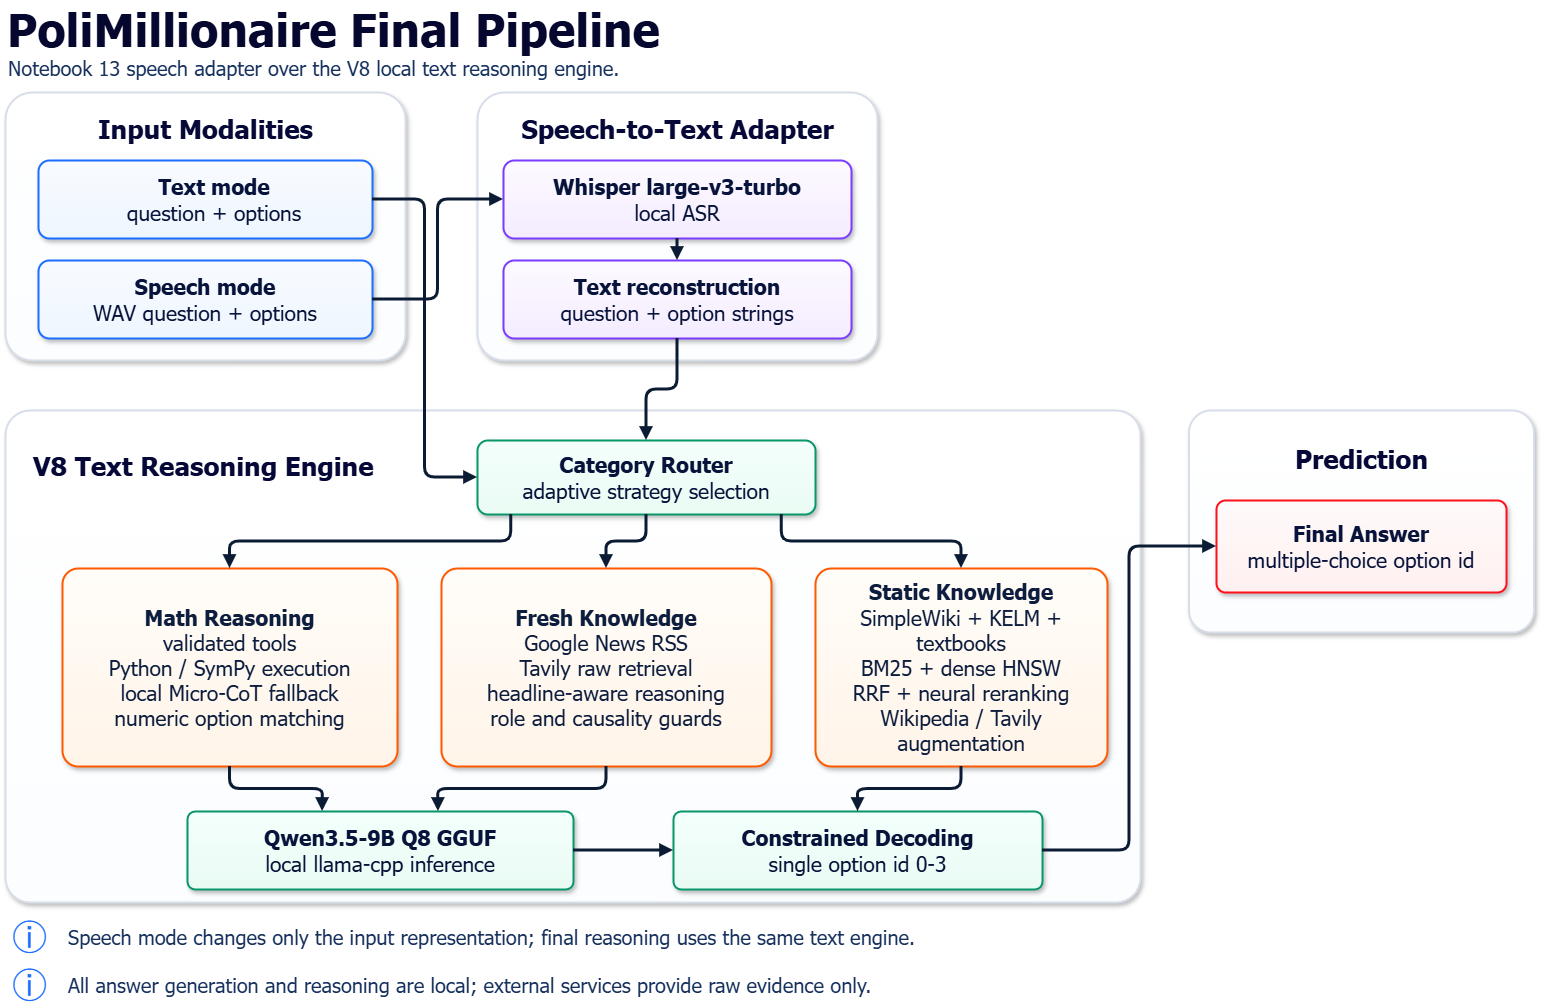

In [ ]:
#define here the name of the category corresponding to math questions
MATH_COMPETITION_NAME = 'Maths'
PROMPT_VERSION = 'v8_clean_qwen35_hybrid_rag_math_tools'


def answer_strategy(question, competition_name: str):
    """Routing policy used by the game loop."""
    valid_ids = {int(opt.id) for opt in get_options(question)}

    if competition_name == MATH_COMPETITION_NAME:
        valid_ids = {int(opt.id) for opt in get_options(question)}
        t_start = time.time()

        # 1+2. Layers deterministici (fast, low cost, mantenuti)
        decision = try_math_tools(question, use_llm_router=False)   # <-- DISABILITA LLM JSON router
        if decision is not None and int(decision.option_id) in valid_ids:
            return int(decision.option_id), {
                'strategy': decision.strategy,
                'decision_source': 'math_validated_tool',
                'confidence': float(decision.confidence),
                'raw_llm_output': decision.raw_tool_call,
                'validated_tool_call': json.dumps(decision.validated_tool_call, ensure_ascii=False) if decision.validated_tool_call else None,
                'tool_validated': True,
                'retrieved_context': [],
                'math_tool_trace': json.dumps(LAST_MATH_TOOL_TRACE, ensure_ascii=False),
                'fallback_used': None,
                'prompt_version': PROMPT_VERSION,
            }

        # 3. Python executor con budget tagliato (max 10s totali)
        elapsed = time.time() - t_start
        if elapsed < 12:   # solo se abbiamo ancora tempo
            exec_option_id, exec_meta = python_executor_fallback(question)
            if exec_option_id is not None and exec_option_id in valid_ids:
                exec_meta['tool_validated'] = False
                exec_meta['prompt_version'] = PROMPT_VERSION
                return exec_option_id, exec_meta

        # 4. Micro-CoT con budget garantito (almeno 15-20s)
        option_id, meta = llm_choose_math_option_direct(question)
        meta['tool_validated'] = False
        meta['prompt_version'] = PROMPT_VERSION
        return option_id, meta

    # V9 answer-first route: Entertainment + Ancient History and Politics.
    if competition_name in V6_REASONING_CATEGORIES:
        return answer_strategy_v9_entertainment_history(question, competition_name)

    # ── Knowledge categories: local retrieval + external fallback ──
    docs = retrieve_and_rerank(get_question_text(question))

    # Wikipedia for Entertainment/History
    if competition_name in WIKI_CATEGORIES:
        try:
            wiki_docs = wiki_retrieve(get_question_text(question), get_options(question))
            if wiki_docs:
                docs = docs + wiki_docs
        except Exception:
            pass

    # Google News + Tavily in parallel for News category
    if competition_name in NEWS_CATEGORIES:
        try:
            news_docs = fetch_news_all_sources(get_question_text(question), get_options(question))
            if news_docs:
                docs = news_docs + docs
        except Exception:
            pass

    if competition_name in NEWS_CATEGORIES:
        summary = retrieval_score_summary(docs)
        # Try Chain-of-Thought first
        cot_id, cot_text, cot_ok = run_news_choice_cot(question, docs, competition_name, valid_ids)
        if cot_ok and cot_id is not None:
            option_id = cot_id
            meta = {
                'strategy': 'news_cot_qwen35',
                'decision_source': 'news_cot',
                'confidence': 0.8,
                'raw_llm_output': cot_text,
                'retrieved_context': docs,
                'fallback_used': None,
                **summary,
            }
        else:
            # CoT said "not found" -> ask model to use its own knowledge
            kn_id, kn_text, kn_ok = run_news_knowledge_fallback(question, competition_name, valid_ids)
            if kn_ok and kn_id is not None:
                option_id = kn_id
                meta = {
                    'strategy': 'news_knowledge_fallback',
                    'decision_source': 'news_model_knowledge',
                    'confidence': 0.35,
                    'raw_llm_output': kn_text,
                    'retrieved_context': docs,
                    'fallback_used': 'cot_no_evidence_used_model_knowledge',
                    **summary,
                }
            else:
                # Last resort: original RAG fallback
                prompt = build_news_rag_prompt(question, docs, competition_name)
                option_id, raw, parsed = run_local_choice(prompt, valid_ids)
                if option_id is None:
                    option_id = int(get_options(question)[0].id)
                meta = {
                    'strategy': 'news_rag_fallback',
                    'decision_source': 'news_rag_after_cot_none',
                    'confidence': 0.3,
                    'raw_llm_output': raw,
                    'retrieved_context': docs,
                    'fallback_used': 'cot_returned_none',
                    **summary,
                }
    elif should_use_option_retrieval(competition_name, docs):
        option_evidence, option_summary = retrieve_option_evidence(question)
        option_id, meta = llm_choose_option_with_option_evidence(question, docs, option_evidence, option_summary, competition_name)
    else:
        option_id, meta = llm_choose_option(question, docs, competition_name)

    if option_id not in valid_ids:
        option_id = int(get_options(question)[0].id)
        meta['strategy'] = 'invalid_option_id_fallback_first_option'
        meta['fallback_used'] = 'first_option_invalid_option_id'
        meta['confidence'] = 0.15
    meta['retrieved_context'] = docs
    meta['prompt_version'] = PROMPT_VERSION
    return option_id, meta


## 12. Dummy tests

Quick checks for the most important local paths before starting real API games.


In [ ]:
class DummyOption:
    def __init__(self, id, text):
        self.id = id
        self.text = text

class DummyQuestion:
    def __init__(self, text, options, qid=0, level=1):
        self.id = qid
        self.text = text
        self.options = options
        self.level = level

q = DummyQuestion(
    text='Who was the first president of the United States?',
    options=[
        DummyOption(1, 'Abraham Lincoln'),
        DummyOption(2, 'George Washington'),
        DummyOption(3, 'Thomas Jefferson'),
        DummyOption(4, 'John Adams'),
    ],
)

option_id, meta = answer_strategy(q, 'Ancient History and Politics')
print('Predicted:', option_id)
print('Strategy:', meta.get('strategy'))
print('Raw LLM:', meta.get('raw_llm_output'))
for d in meta.get('retrieved_context', [])[:3]:
    print('DOC:', d.get('source'), d.get('reranker_score'), d['text'][:250])


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/9 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/9 [00:00<?, ?it/s]

Predicted: 2
Strategy: v9_micro_reasoning_unified_retrieval
Raw LLM: 2
REASON: Multiple sources confirm George Washington was the first president of the United States, inaugurated on April 30, 1789.

ANSWER: 2
REASON: Multiple sources confirm George Washington was the first president of the [1] and [3] explicitly state he was the first president, while [2] clarifies he was the first under the new Constitution.

ANSWER: 2
REvidence:
[1. simplewiki | 6.4]
The first inauguration of George Washington as the president of the United States took place on April 30, 1Who was the first president of the United States?

Options:
1. Abraham Lincoln
2. George Washington
3. Thomas Jefferson
4. John Adams

Evidence:
[1. simplewiki | 6.4]
The first inauguration of George Washington as the provided evidence clearly states that George Washington was the first president of the United States, with his inauguration taking place on April 30, 1789. This is further supported by [3], which mentions he was elect

In [ ]:
q_math = DummyQuestion(
    text='What is the value of the expression 5*8+4?',
    options=[
        DummyOption(1, '40'),
        DummyOption(2, '42'),
        DummyOption(3, '44'),
        DummyOption(4, '48'),
    ],
)

option_id, meta = answer_strategy(q_math, 'Maths')
print('Predicted:', option_id)
print('Meta:', meta)


Predicted: 3
Meta: {'strategy': 'tool_math_evaluate_expression', 'decision_source': 'math_validated_tool', 'confidence': 0.96, 'raw_llm_output': '{"tool": "math_evaluate_expression", "args": {"expression": "5*8+4"}}', 'validated_tool_call': '{"tool": "math_evaluate_expression", "args": {"expression": "5*8+4"}}', 'tool_validated': True, 'retrieved_context': [], 'math_tool_trace': '[{"tool": "deterministic_shortcuts_option_substitution", "matched": false, "latency": 0.0007507801055908203, "error": "no deterministic shortcut matched", "validation": "no_match"}, {"tool": "deterministic_validated_router", "matched": true, "latency": 0.0050694942474365234, "error": null, "call": {"tool": "math_evaluate_expression", "args": {"expression": "5*8+4"}}, "validation": "accepted", "explanation": "Evaluated \'5*8+4\' = 44."}]', 'fallback_used': None, 'prompt_version': 'v8_clean_qwen35_hybrid_rag_math_tools'}


In [ ]:
_phase1_smoke_test()

  [OK] LCM shortcut -> deterministic_math_lcm_from_factors
  [OK] mean shortcut -> deterministic_math_mean_of_numbers
  [OK] modular arithmetic -> deterministic_math_modular_expression_remainder -> option 1
  [OK] V5 regex router still works -> tool_math_geometry
Phase 1 patch is live — shortcuts firing, no regression in regex router.


## 13. PoliMillionaire API loop skeleton

Configuration and helper functions for authenticating, starting games, submitting answers, and saving run logs.

In [ ]:
# V3 deterministic tool smoke tests. Run before API games.
def _assert_tool_choice(question, call, expected_id):
    decision, error = execute_validated_tool_call(question, call)
    assert error is None, error
    assert decision is not None, call
    assert int(decision.option_id) == int(expected_id), (decision, call)
    return decision

walk_q = DummyQuestion(
    text='A person walked 3 miles to the east, then turned north and walked 10 miles, then turned west and walked 6 miles, and finally turned south and walked 16 miles. Approximately how far is the person from his starting point in miles?',
    options=[DummyOption(0, '3.4'), DummyOption(1, '9.2'), DummyOption(2, '6.7'), DummyOption(3, '12.8')],
)
_assert_tool_choice(walk_q, {'tool': 'math_geometry', 'args': {'operation': 'cardinal_walk_distance', 'movements': walk_q.text}}, 2)

normal_q = DummyQuestion(
    text='Demand is normally distributed with mean 2500 and standard deviation 225. What is P(X > 3000)?',
    options=[DummyOption(0, '0.0132'), DummyOption(1, '0.9869'), DummyOption(2, '0.1667'), DummyOption(3, '0.8333')],
)
_assert_tool_choice(normal_q, {'tool': 'math_normal_distribution', 'args': {'operation': 'tail_probability', 'mean': 2500, 'std': 225, 'score': 3000}}, 0)

binom_q = DummyQuestion(
    text='We roll a fair 6-sided die 5 times. What is the probability that we get a 6 in at most 2 of the rolls?',
    options=[DummyOption(0, '\\frac{625}{648}'), DummyOption(1, '\\frac{25}{648}'), DummyOption(2, '\\frac{125}{648}'), DummyOption(3, '\\frac{1}{648}')],
)
_assert_tool_choice(binom_q, {'tool': 'math_binomial_probability', 'args': {'operation': 'at_most', 'n': 5, 'p': 1/6, 'k': 2}}, 0)

inverse_q = DummyQuestion(
    text='The numbers x and y are inversely proportional. When x+y=42 and x is twice y. What is y when x=-8?',
    options=[DummyOption(0, '-49'), DummyOption(1, '-7'), DummyOption(2, '40'), DummyOption(3, '-40')],
)
_assert_tool_choice(inverse_q, {'tool': 'math_solve_equation', 'args': {'equations': ['x+y=42', 'x-2*y=0', 'k-x*y=0', 'w+k/8=0'], 'variables': ['x', 'y', 'k', 'w'], 'target': 'w'}}, 0)

print('V3 deterministic Maths tool smoke tests passed.')


V3 deterministic Maths tool smoke tests passed.


## 14. **Start Game**

Run one competition at a time so failures, logs, and category-specific behavior are easy to inspect.

### 14.1 Game preparation

In [ ]:
# Fill these before running.
API_URL = 'http://131.175.15.22:51111/'

# Colab Secret names. Change these if your secrets use different names.
USERNAME_SECRET_NAME = 'USERNAME'
PASSWORD_SECRET_NAME = 'PASSWORD'

# Optional manual fallback. Leave as None when using Colab Secrets.
USERNAME = None
PASSWORD = None

# Number of full game attempts to run for each competition/category.
N_ATTEMPTS_PER_COMPETITION = 5

# Single cumulative log file for this notebook version.
def _read_secret(secret_name):
    if not secret_name:
        return None

    # Kaggle Secrets
    try:
        if globals().get('IN_KAGGLE', False):
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret(secret_name)
    except Exception as e:
        print(f'Could not read Kaggle secret {secret_name}:', repr(e))

    # Colab Secrets
    try:
        if globals().get('IN_COLAB', False):
            from google.colab import userdata
            return userdata.get(secret_name)
    except Exception as e:
        print(f'Could not read Colab secret {secret_name}:', repr(e))

    # Existing notebook fallback, if user_secrets was already created
    try:
        if 'user_secrets' in globals() and user_secrets is not None:
            return user_secrets.get_secret(secret_name)
    except Exception:
        pass

    return None

def setup_client():
    from millionaire_client import MillionaireClient
    username = USERNAME or _read_secret(USERNAME_SECRET_NAME)
    password = PASSWORD or _read_secret(PASSWORD_SECRET_NAME)
    if username is None or password is None:
        raise ValueError(
            'Set USERNAME/PASSWORD manually or create secrets named '
            f'{USERNAME_SECRET_NAME!r} and {PASSWORD_SECRET_NAME!r}'
        )
    client = MillionaireClient(API_URL)
    client.login(username, password)
    return client


def get_competitions(client):
    competitions = client.competitions.list_all()
    for comp in competitions:
        print(comp.id, comp.name, getattr(comp, 'max_levels', None))
    return competitions


def get_competition_names(client):
    return {comp.id: comp.name for comp in get_competitions(client)}


def _serialize_retrieved_context(meta):
    return json.dumps([
        {
            'source': d.get('source'),
            'idx': d.get('idx'),
            'reranker_score': d.get('reranker_score'),
            'text': d.get('text', '')[:3000],
        }
        for d in meta.get('retrieved_context', [])
    ], ensure_ascii=False)


def _retrieved_docs(meta):
    docs = meta.get('retrieved_context', []) if isinstance(meta, dict) else []
    return docs if isinstance(docs, list) else []


def _retrieval_sources(meta):
    sources = sorted({str(d.get('source')) for d in _retrieved_docs(meta) if d.get('source')})
    return json.dumps(sources, ensure_ascii=False)


def _textbook_docs(meta):
    return [d for d in _retrieved_docs(meta) if str(d.get('source', '')).startswith('textbook_')]


def _textbook_context_summary(meta):
    docs = _textbook_docs(meta)
    sources = sorted({str(d.get('source')) for d in docs if d.get('source')})
    top_doc = docs[0] if docs else {}
    return {
        'textbook_context_used': bool(docs),
        'textbook_context_count': len(docs),
        'textbook_context_sources': json.dumps(sources, ensure_ascii=False),
        'textbook_top_source': top_doc.get('source'),
        'textbook_top_reranker_score': top_doc.get('reranker_score'),
    }


def append_logs(df, output_csv=RUN_LOG_PATH):
    if df is None or df.empty:
        return
    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    write_header = not output_csv.exists() or output_csv.stat().st_size == 0
    df.to_csv(output_csv, mode='a', header=write_header, index=False)


def _meta_get(meta, key, default=None):
    return meta.get(key, default) if isinstance(meta, dict) else default


def run_competition(client, comp_id, competition_names, attempt_number=None, run_id=None):
    competition_name = competition_names[comp_id]
    logs = []
    session_started_at = time.strftime('%Y-%m-%d %H:%M:%S')

    # Retry game start when the API is temporarily busy.
    game = None
    for _try in range(3):
        try:
            game = client.game.start(competition_id=comp_id)
            break
        except Exception as e:
            if _try < 2:
                print(f'  ⚠ start fallito ({type(e).__name__}), riprovo tra 8s...', flush=True)
                time.sleep(8)
            else:
                return pd.DataFrame([{
                    'run_id': run_id, 'attempt_number': attempt_number,
                    'session_started_at': session_started_at, 'session_id': None,
                    'competition_id': comp_id, 'competition_name': competition_name,
                    'error_message': repr(e),
                }])

    while game.in_progress:
        question = game.current_question
        if question is None:
            break

        time_remaining_before = getattr(game, 'time_remaining', None)
        game_current_level_before = getattr(game, 'current_level', None)
        start = time.time()
        try:
            option_id, meta = answer_strategy(question, competition_name)
            latency = time.time() - start

            # Retry answer submission for the current question.
            result = None
            for _try in range(3):
                try:
                    result = game.answer(option_id)
                    break
                except Exception as ans_err:
                    if _try < 2:
                        print(f'    ⚠ answer() fallito ({type(ans_err).__name__}), '
                              f'riprovo tra 6s [{_try+1}/3]...', flush=True)
                        time.sleep(6)
                    else:
                        raise  # Retries exhausted; let the outer exception handler log it.
            # End of per-question retry block.

            ok = getattr(result, 'correct', False)
            q = get_question_text(question)[:70]
            earned = getattr(result, 'earned_amount', 0)
            news_articles = [d for d in meta.get('retrieved_context', [])
                             if isinstance(d, dict) and d.get('source') == 'google_news_article']

            debug_info = ''
            if competition_name in NEWS_CATEGORIES:
                combined = ' '.join(d.get('text','').lower() for d in news_articles)
                opts_in_art = [int(o.id) for o in get_options(question)
                               if str(o.text).lower() in combined and len(str(o.text)) > 4]
                chosen_in_art = option_id in opts_in_art
                debug_info = f" | art:{len(news_articles)} opts_found:{opts_in_art} chosen_in_art:{chosen_in_art}"

            print(f'  {"✓" if ok else "✗"} [{latency:.1f}s] {q} | ${int(earned):,}{debug_info}', flush=True)
            if not ok and competition_name in NEWS_CATEGORIES:
                opts = json.dumps([(int(o.id), o.text) for o in get_options(question)], ensure_ascii=False)[:130]
                print(f'    Chosen: {option_id} | {opts}', flush=True)

            textbook_summary = _textbook_context_summary(meta)
            logs.append({
                'run_id': run_id, 'attempt_number': attempt_number,
                'session_started_at': session_started_at,
                'session_id': getattr(game, 'session_id', None),
                'competition_id': comp_id, 'competition_name': competition_name,
                'question_id': getattr(question, 'id', None),
                'question_level': getattr(question, 'level', None),
                'game_current_level_before': game_current_level_before,
                'time_remaining_before': time_remaining_before,
                'question_text': get_question_text(question),
                'options_json': json.dumps([(int(o.id), o.text) for o in get_options(question)], ensure_ascii=False),
                'chosen_option_id': option_id,
                'correct': getattr(result, 'correct', None),
                'timed_out': getattr(result, 'timed_out', None),
                'game_over': getattr(result, 'game_over', None),
                'earned_amount': getattr(result, 'earned_amount', None),
                'latency_seconds': latency,
                'strategy': _meta_get(meta, 'strategy'),
                'decision_source': _meta_get(meta, 'decision_source'),
                'confidence': _meta_get(meta, 'confidence'),
                'explanation': _meta_get(meta, 'explanation'),
                'raw_llm_output': _meta_get(meta, 'raw_llm_output'),
                'prompt_version': _meta_get(meta, 'prompt_version', PROMPT_VERSION),
                'retrieved_context': _serialize_retrieved_context(meta),
                'retrieval_sources': _retrieval_sources(meta),
                'retrieval_top_score': _meta_get(meta, 'retrieval_top_score'),
                'retrieval_second_score': _meta_get(meta, 'retrieval_second_score'),
                'retrieval_margin': _meta_get(meta, 'retrieval_margin'),
                'option_retrieval_top_score': _meta_get(meta, 'option_retrieval_top_score'),
                'option_retrieval_second_score': _meta_get(meta, 'option_retrieval_second_score'),
                'option_retrieval_margin': _meta_get(meta, 'option_retrieval_margin'),
                'option_evidence_scores_json': _meta_get(meta, 'option_evidence_scores_json'),
                'option_evidence_json': _meta_get(meta, 'option_evidence_json'),
                'tool_validated': _meta_get(meta, 'tool_validated'),
                'validated_tool_call': _meta_get(meta, 'validated_tool_call'),
                'tool_rejected_reason': _meta_get(meta, 'tool_rejected_reason'),
                'math_tool_trace': _meta_get(meta, 'math_tool_trace'),
                'fallback_used': _meta_get(meta, 'fallback_used'),
                **textbook_summary,
                'error_message': None,
            })

            time.sleep(2.0)   # Pause between questions to avoid stressing the server.

        except Exception as e:
            print(f'  ⚠ ERROR: {e}', flush=True)
            logs.append({
                'run_id': run_id, 'attempt_number': attempt_number,
                'session_started_at': session_started_at,
                'session_id': getattr(game, 'session_id', None),
                'competition_id': comp_id, 'competition_name': competition_name,
                'question_id': getattr(question, 'id', None),
                'question_level': getattr(question, 'level', None),
                'game_current_level_before': game_current_level_before,
                'time_remaining_before': time_remaining_before,
                'question_text': get_question_text(question),
                'options_json': json.dumps([(int(o.id), o.text) for o in get_options(question)], ensure_ascii=False),
                'retrieval_sources': '[]',
                'math_tool_trace': None,
                'fallback_used': 'exception',
                'error_message': repr(e),
            })
            break

    return pd.DataFrame(logs)

In [ ]:
# Initialize the game client and run a quick login smoke test.
client = setup_client()

In [ ]:
# Shared setup for one-category runs.
import logging
logging.getLogger('bm25s').setLevel(logging.WARNING)

MAX_RETRIES = 4   # Attempts if the server goes down
RETRY_WAIT  = 15  # Base wait before retry; linear backoff.

def run_selected_competitions(client, competitions, attempts):
    competition_names = get_competition_names(client)
    all_logs = []
    run_id = time.strftime('%Y%m%d_%H%M%S_selected')

    for attempt in range(1, attempts + 1):
        for comp_id, comp_name in competition_names.items():
            if comp_name not in competitions:
                continue
            print(f'\n{"="*50}', flush=True)
            print(f'Attempt {attempt}/{attempts} | {comp_name}', flush=True)
            print(f'{"="*50}', flush=True)

            df = None
            for retry in range(MAX_RETRIES):
                try:
                    df = run_competition(client, comp_id, competition_names,
                                         attempt_number=attempt, run_id=run_id)
                    break
                except Exception as e:
                    name = type(e).__name__
                    if retry < MAX_RETRIES - 1:
                        wait = RETRY_WAIT * (retry + 1)
                        print(f'  ⚠ server giù ({name}). Riprovo tra {wait}s '
                              f'[{retry+1}/{MAX_RETRIES}]...', flush=True)
                        try:
                            client = setup_client()
                        except Exception:
                            pass
                        time.sleep(wait)
                    else:
                        print(f'  ⊘ attempt {attempt} saltato dopo {MAX_RETRIES} '
                              f'tentativi ({name})', flush=True)

            if df is None:
                continue

            append_logs(df, output_csv=RUN_LOG_PATH)
            all_logs.append(df)
            earned = df['earned_amount'].iloc[-1] if len(df) > 0 and 'earned_amount' in df.columns else 0
            earned = 0 if pd.isna(earned) else int(earned)
            n_correct = sum(1 for _, r in df.iterrows() if str(r.get('correct','')).lower() == 'true')
            print(f'  → {n_correct}/{len(df)} = ${earned:,}', flush=True)
            time.sleep(3.0)
            cleanup_memory()

    return pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()

client = setup_client()


### 14.2 Game Start: Text mode

In [ ]:
# Dedicated run: Entertainment
df = run_selected_competitions(client, {'Entertainment'}, attempts=10)


0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | Entertainment


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/15 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/15 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/23 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/23 [00:00<?, ?it/s]

  ✗ [17.5s] According to Ridley Scott, what was the primary reason he decided to d | $200
  → 2/3 = $200


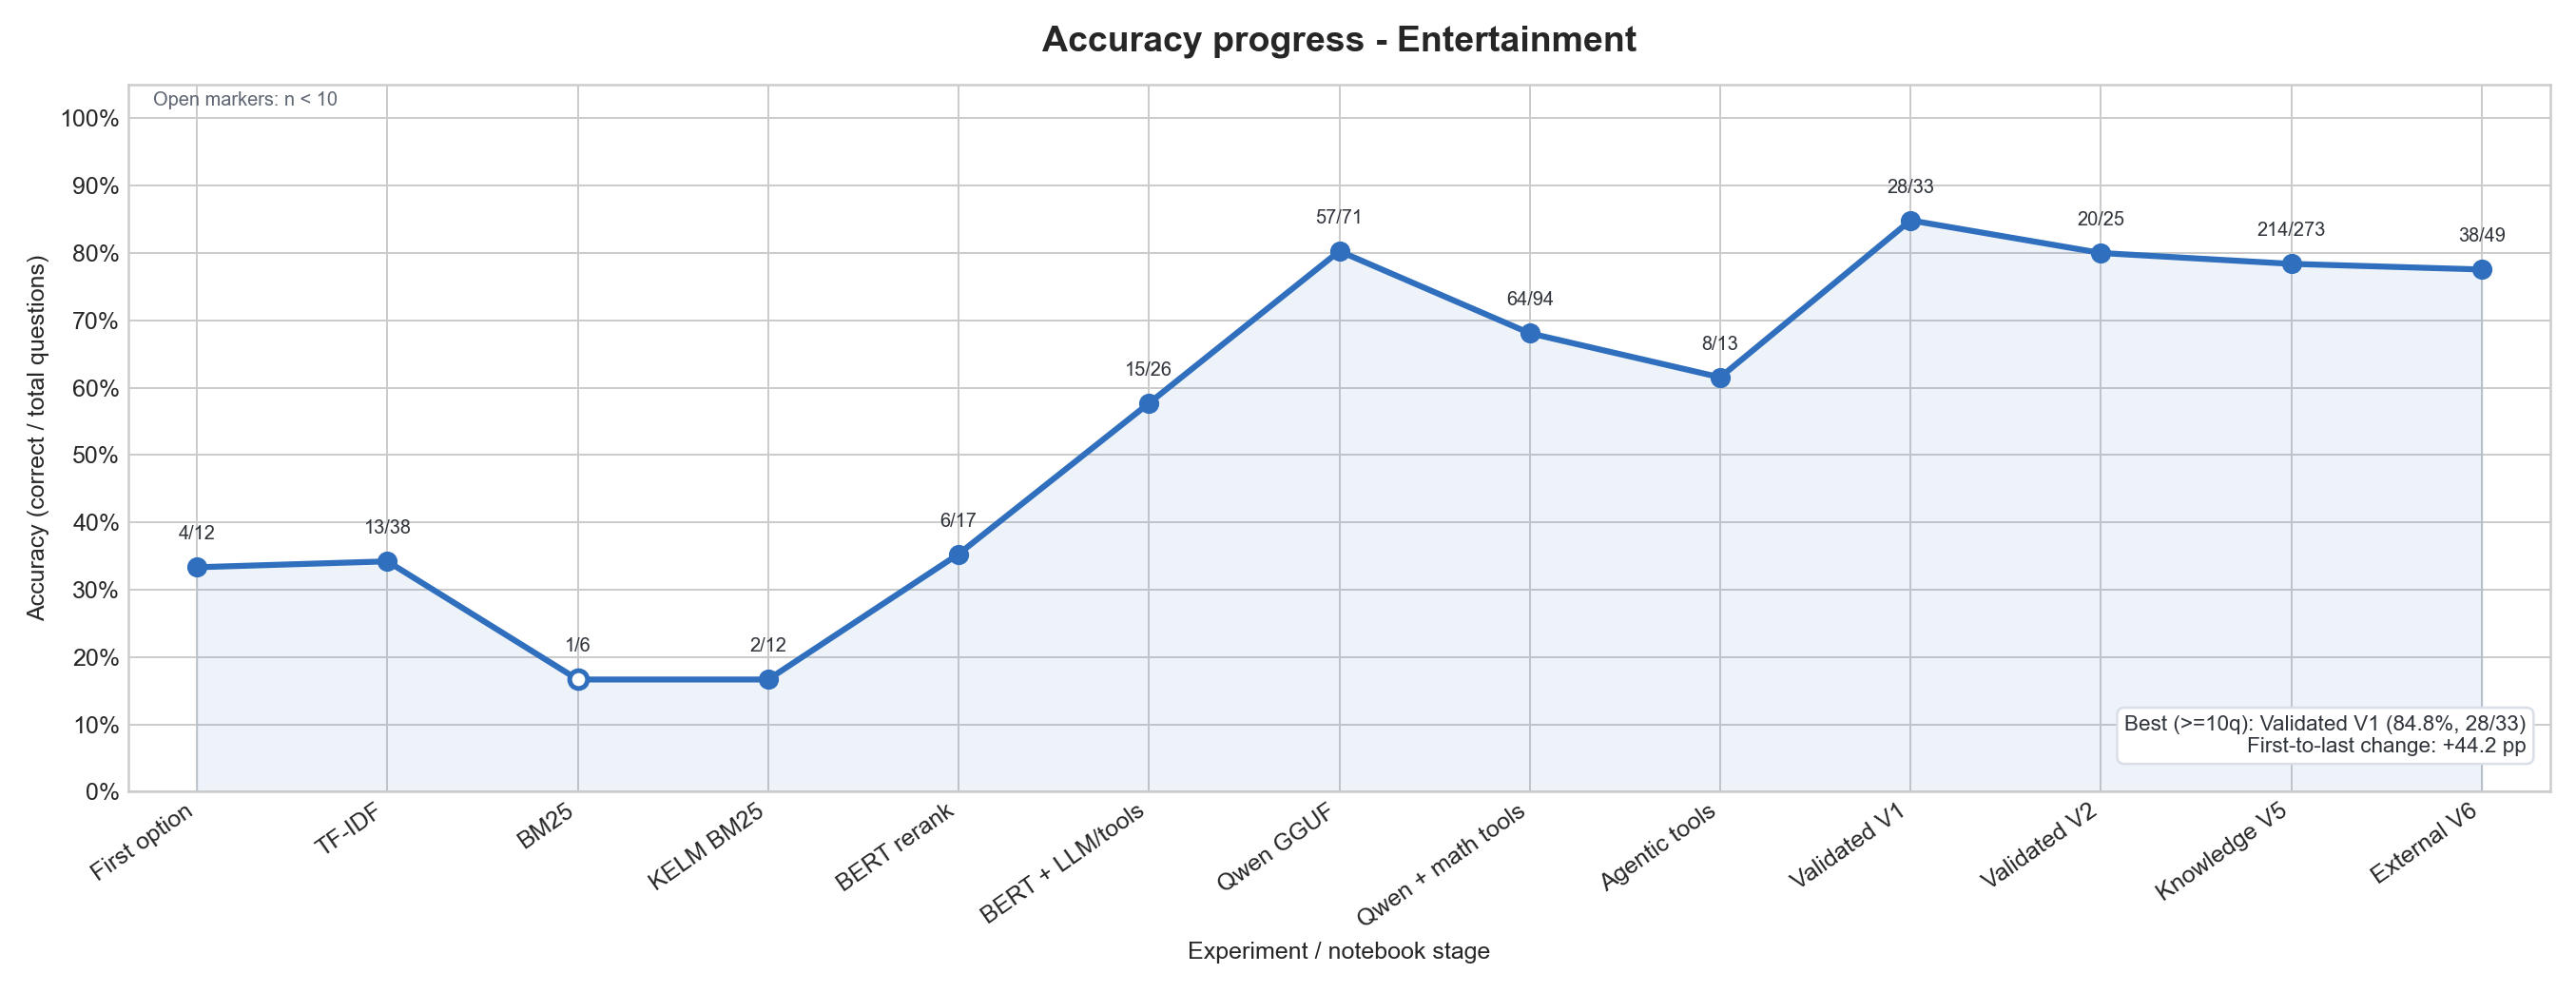

In [ ]:
# Dedicated run: Ancient History and Politics
df = run_selected_competitions(client, {'Ancient History and Politics'}, attempts=10)


0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | Ancient History and Politics


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/18 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/18 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/19 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/19 [00:00<?, ?it/s]

  ✗ [17.1s] How does the life expectancy at birth in the Roman Empire compare to t | $4,000
  → 7/8 = $4,000


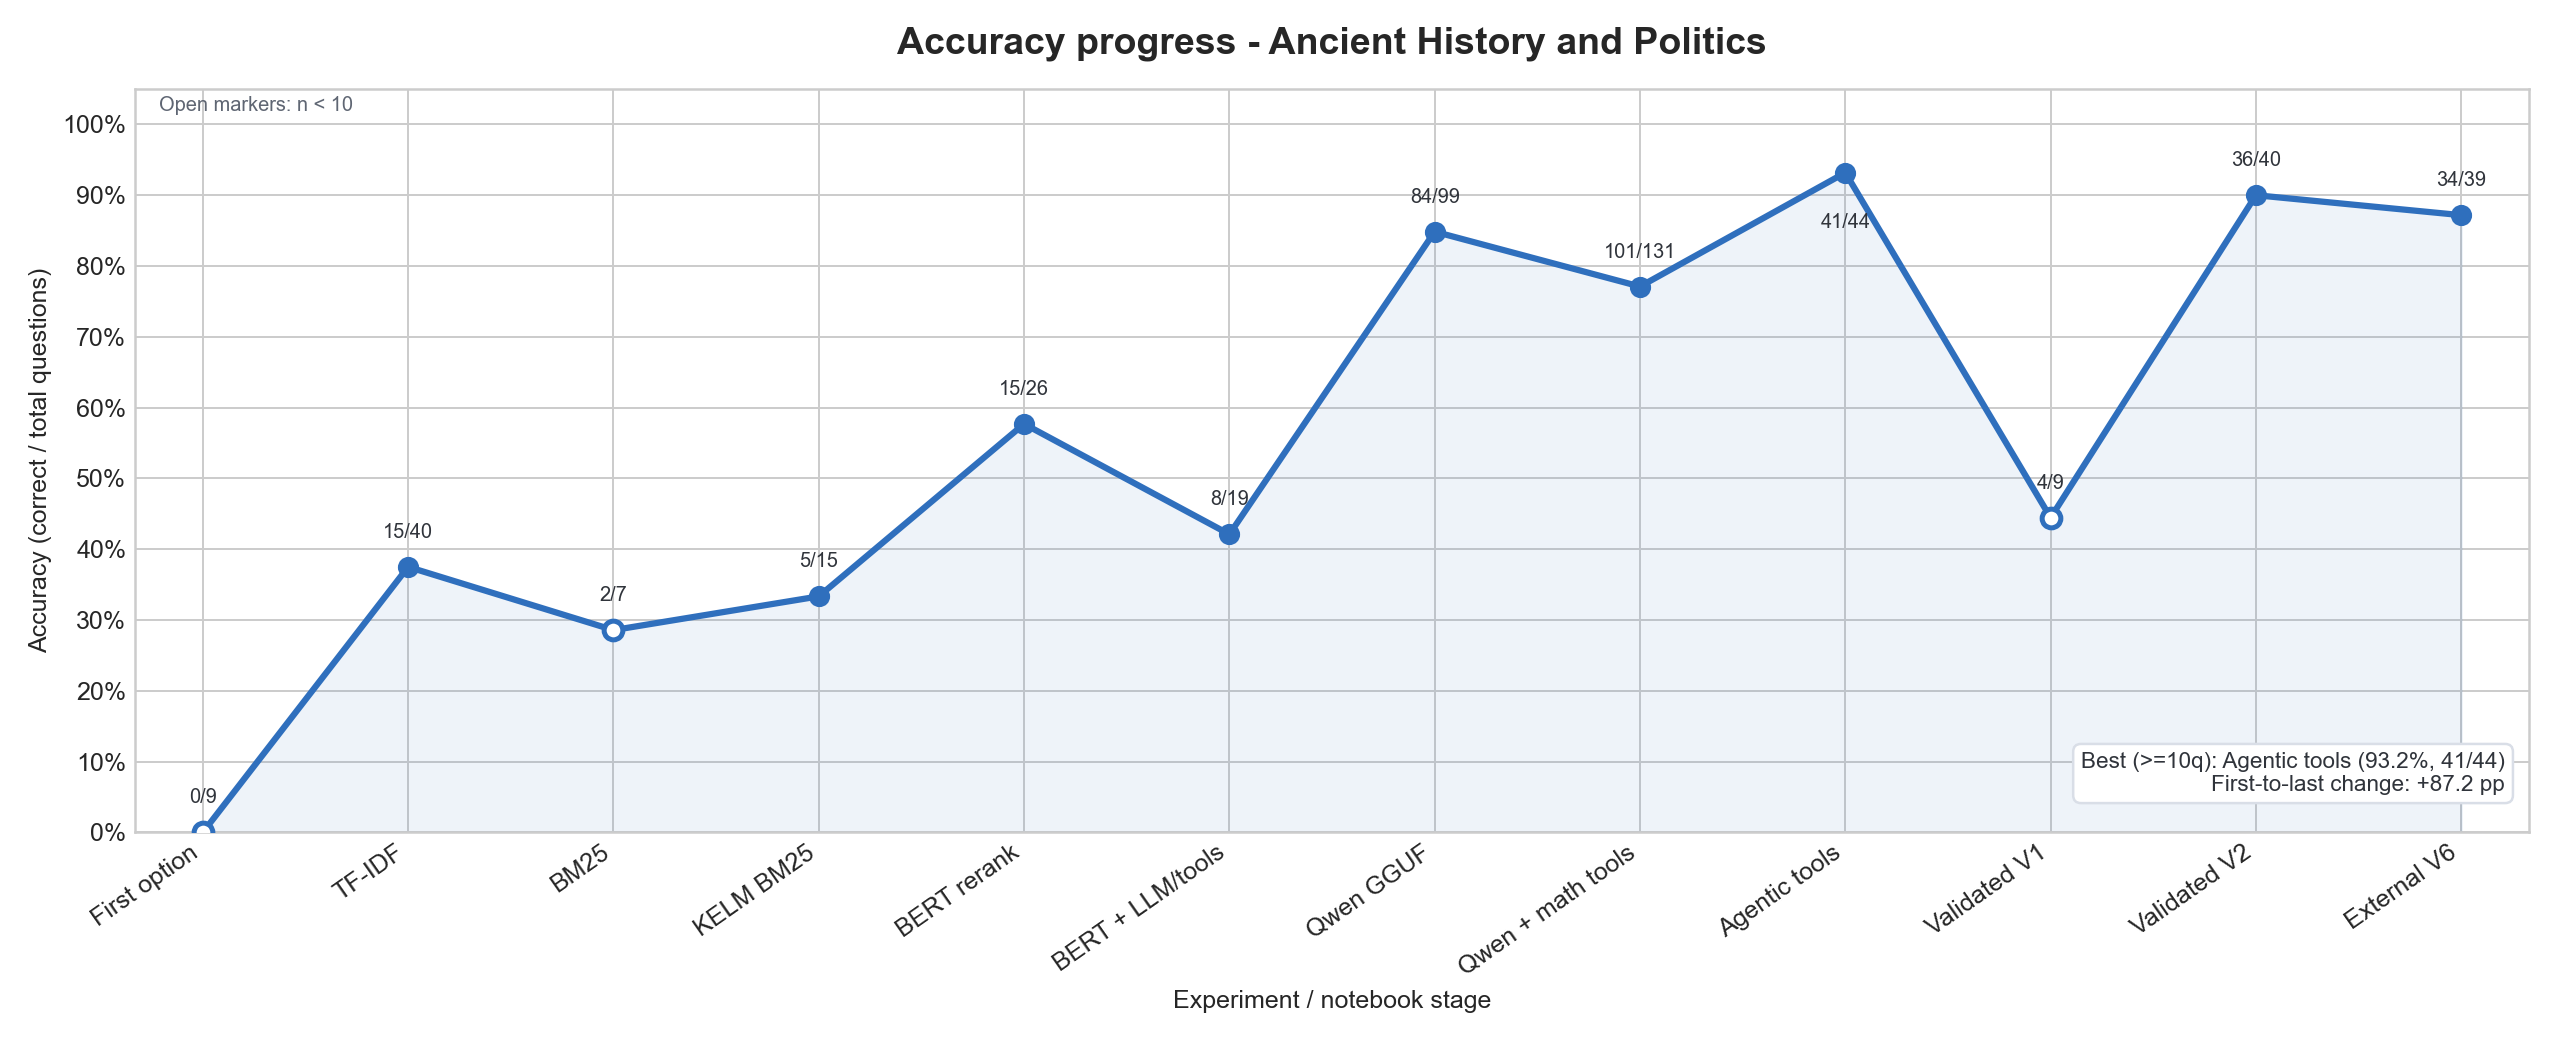

In [ ]:
# Dedicated run: Science and Nature
df = run_selected_competitions(client, {'Science and Nature'}, attempts=10)


0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | Science and Nature


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/15 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/15 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/25 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/25 [00:00<?, ?it/s]

  ✗ [3.7s] In a laboratory procedure, a student observes different sizes of soil  | $8,000
  → 8/9 = $8,000


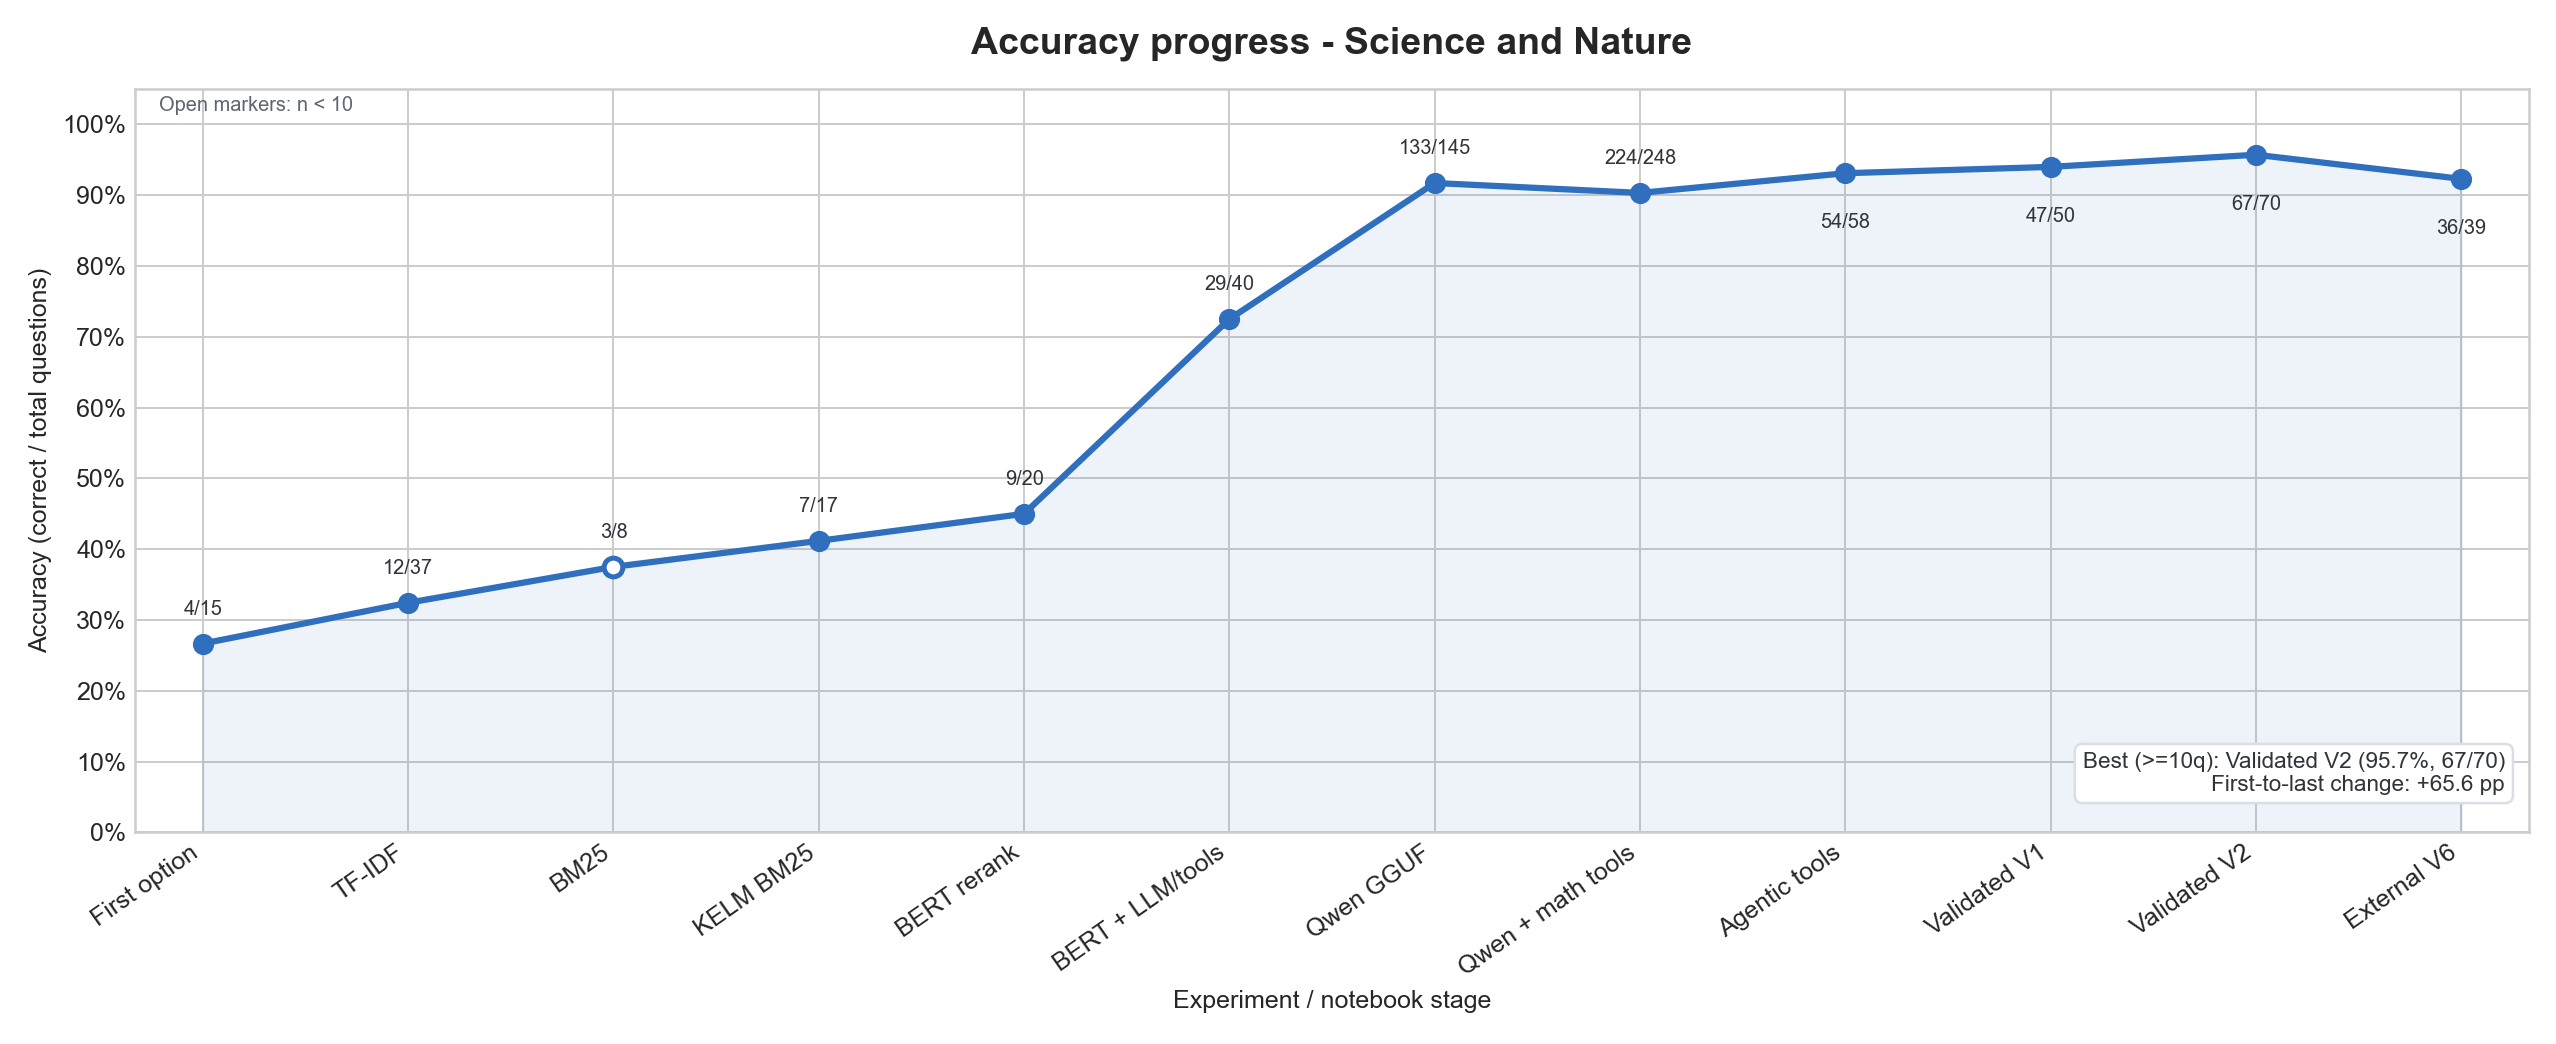

In [ ]:
# Dedicated run: Philosophy and Psychology
df = run_selected_competitions(client, {'Philosophy and Psychology'}, attempts=10)


0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | Philosophy and Psychology


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/11 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/11 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/12 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/12 [00:00<?, ?it/s]

  ✗ [1.0s] Which of the following is a key distinction between shame and embarras | $1,000
  → 5/6 = $1,000


/tmp/ipykernel_564/766110338.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()


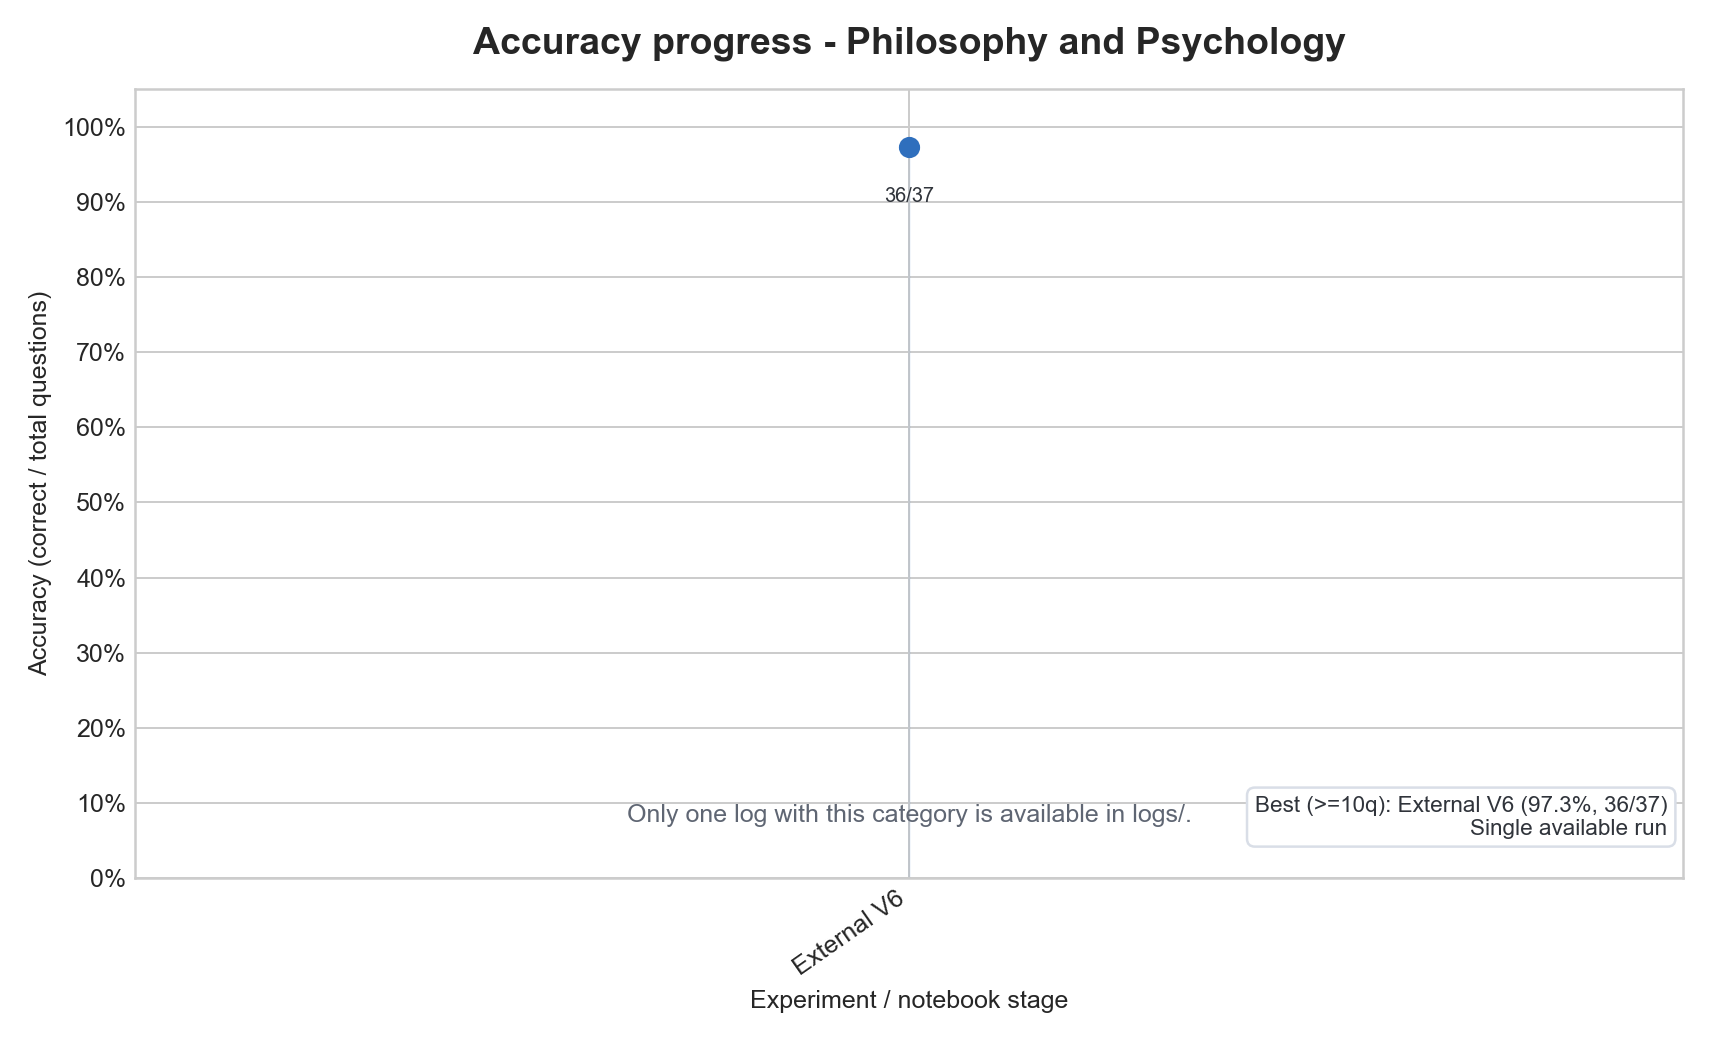

In [ ]:
# Dedicated run: News
df = run_selected_competitions(client, {'News'}, attempts=10)


0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | News


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/27 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/27 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/29 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/29 [00:00<?, ?it/s]

  ✗ [13.8s] The article published on 2026-05-06 reports that BioNTech's first-quar | $0 | art:5 opts_found:[] chosen_in_art:False
    Chosen: 1 | [[0, "35%"], [1, "45%"], [2, "15%"], [3, "25%"]]
  → 0/1 = $0


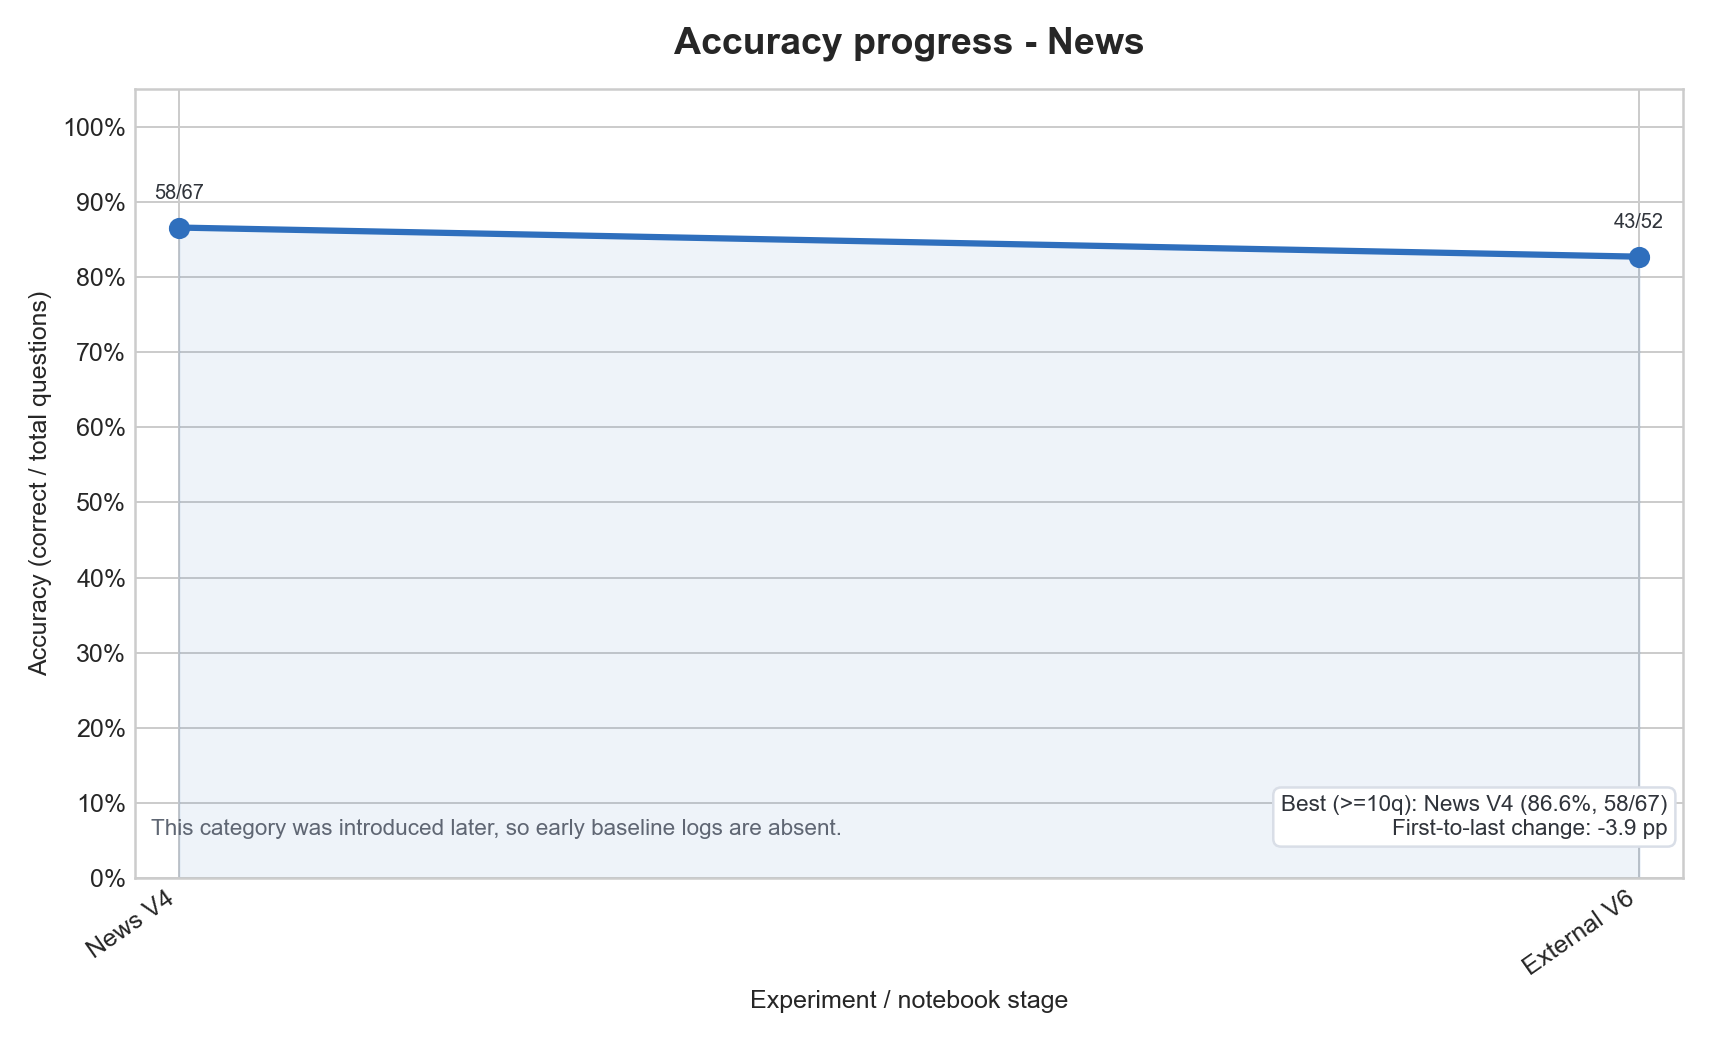

In [ ]:
# Dedicated run: Maths
df = run_selected_competitions(client, {'Maths'}, attempts=20)


0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/20 | Maths


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/9 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/9 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/38 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/38 [00:00<?, ?it/s]

  ✗ [17.5s] If f : (0, 1) → (0, 1], then which of the following could be TRUE?
I.  | $200
  → 2/3 = $200


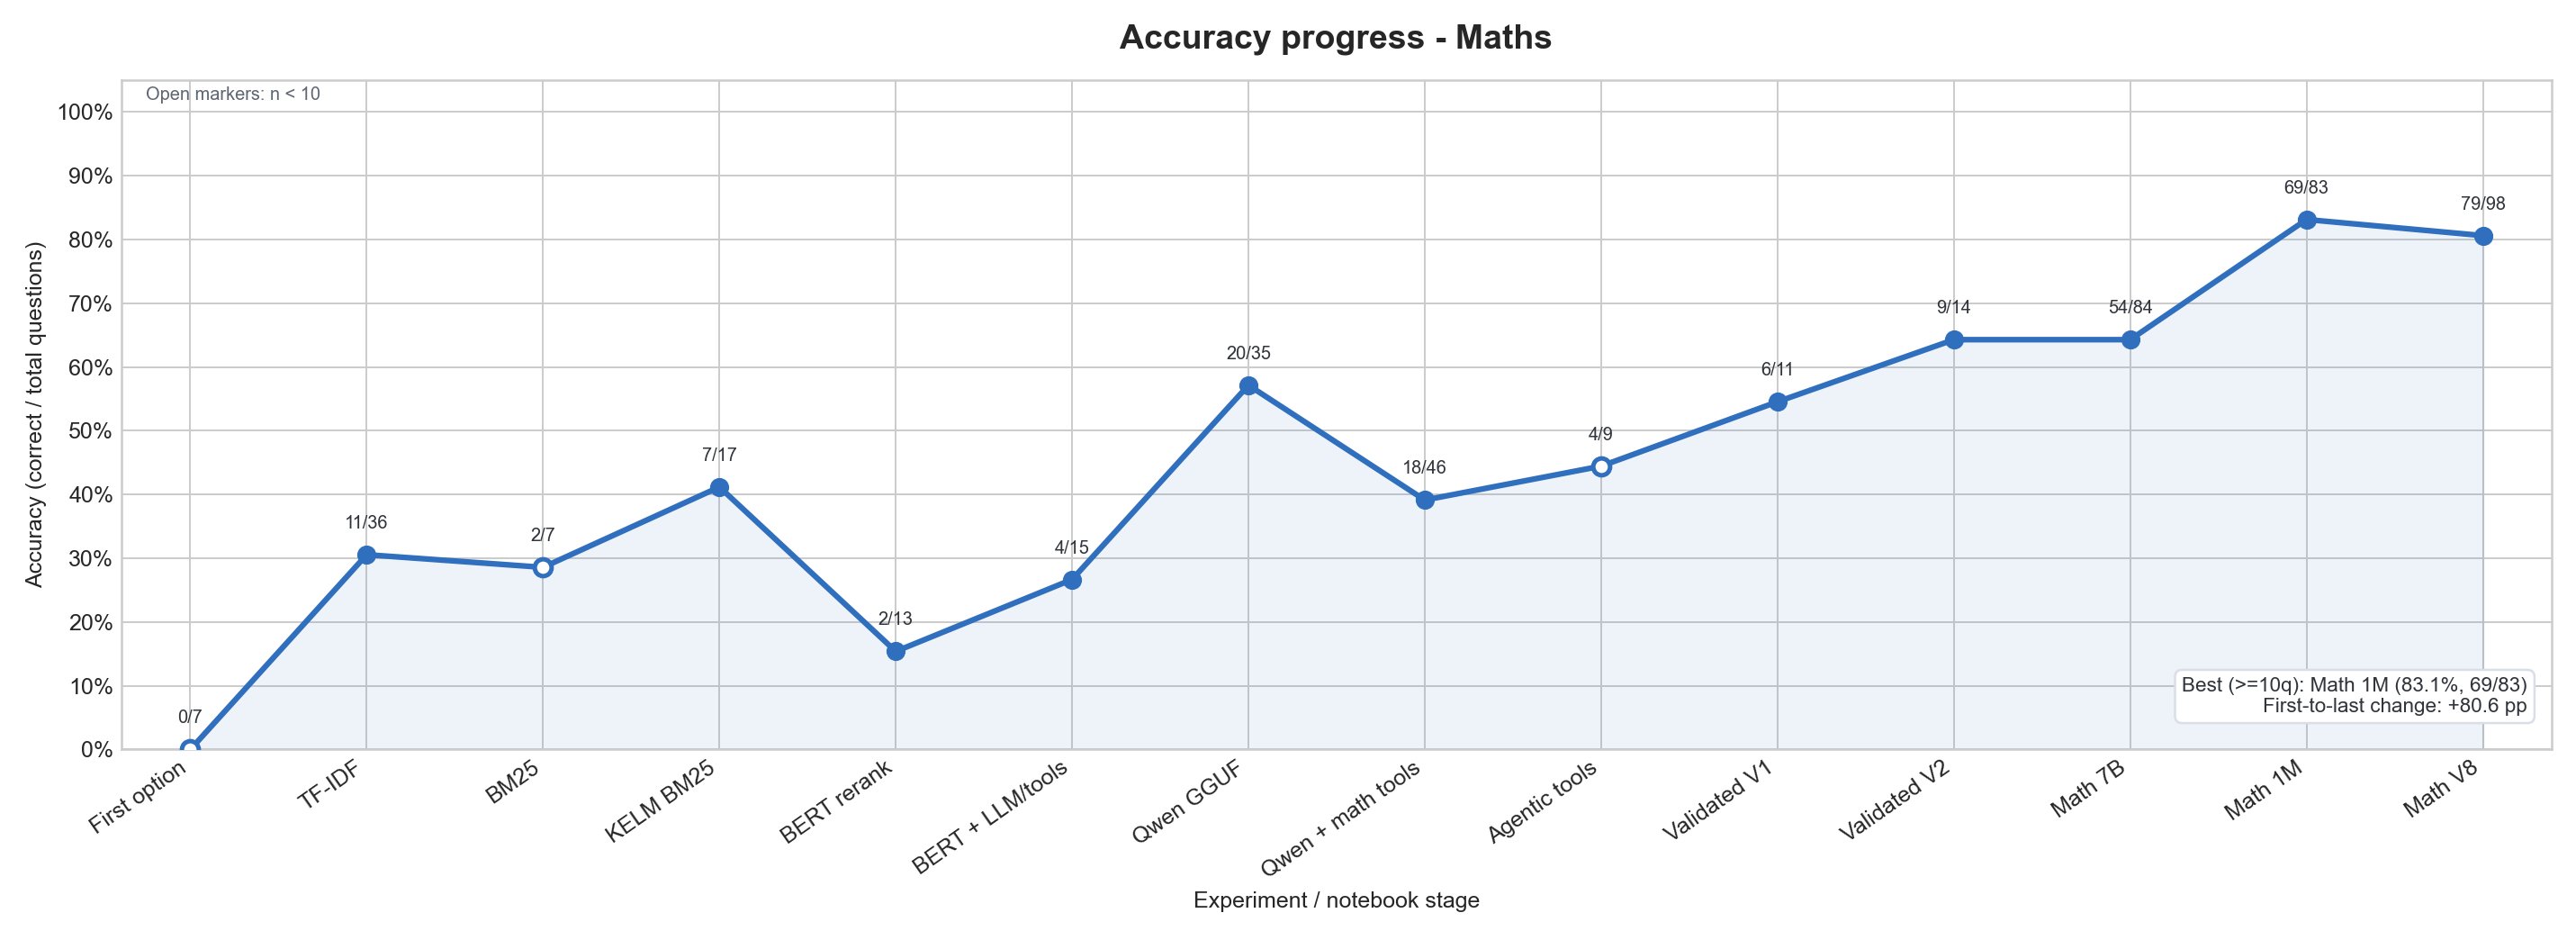

## 14.3 Accuracy Summary

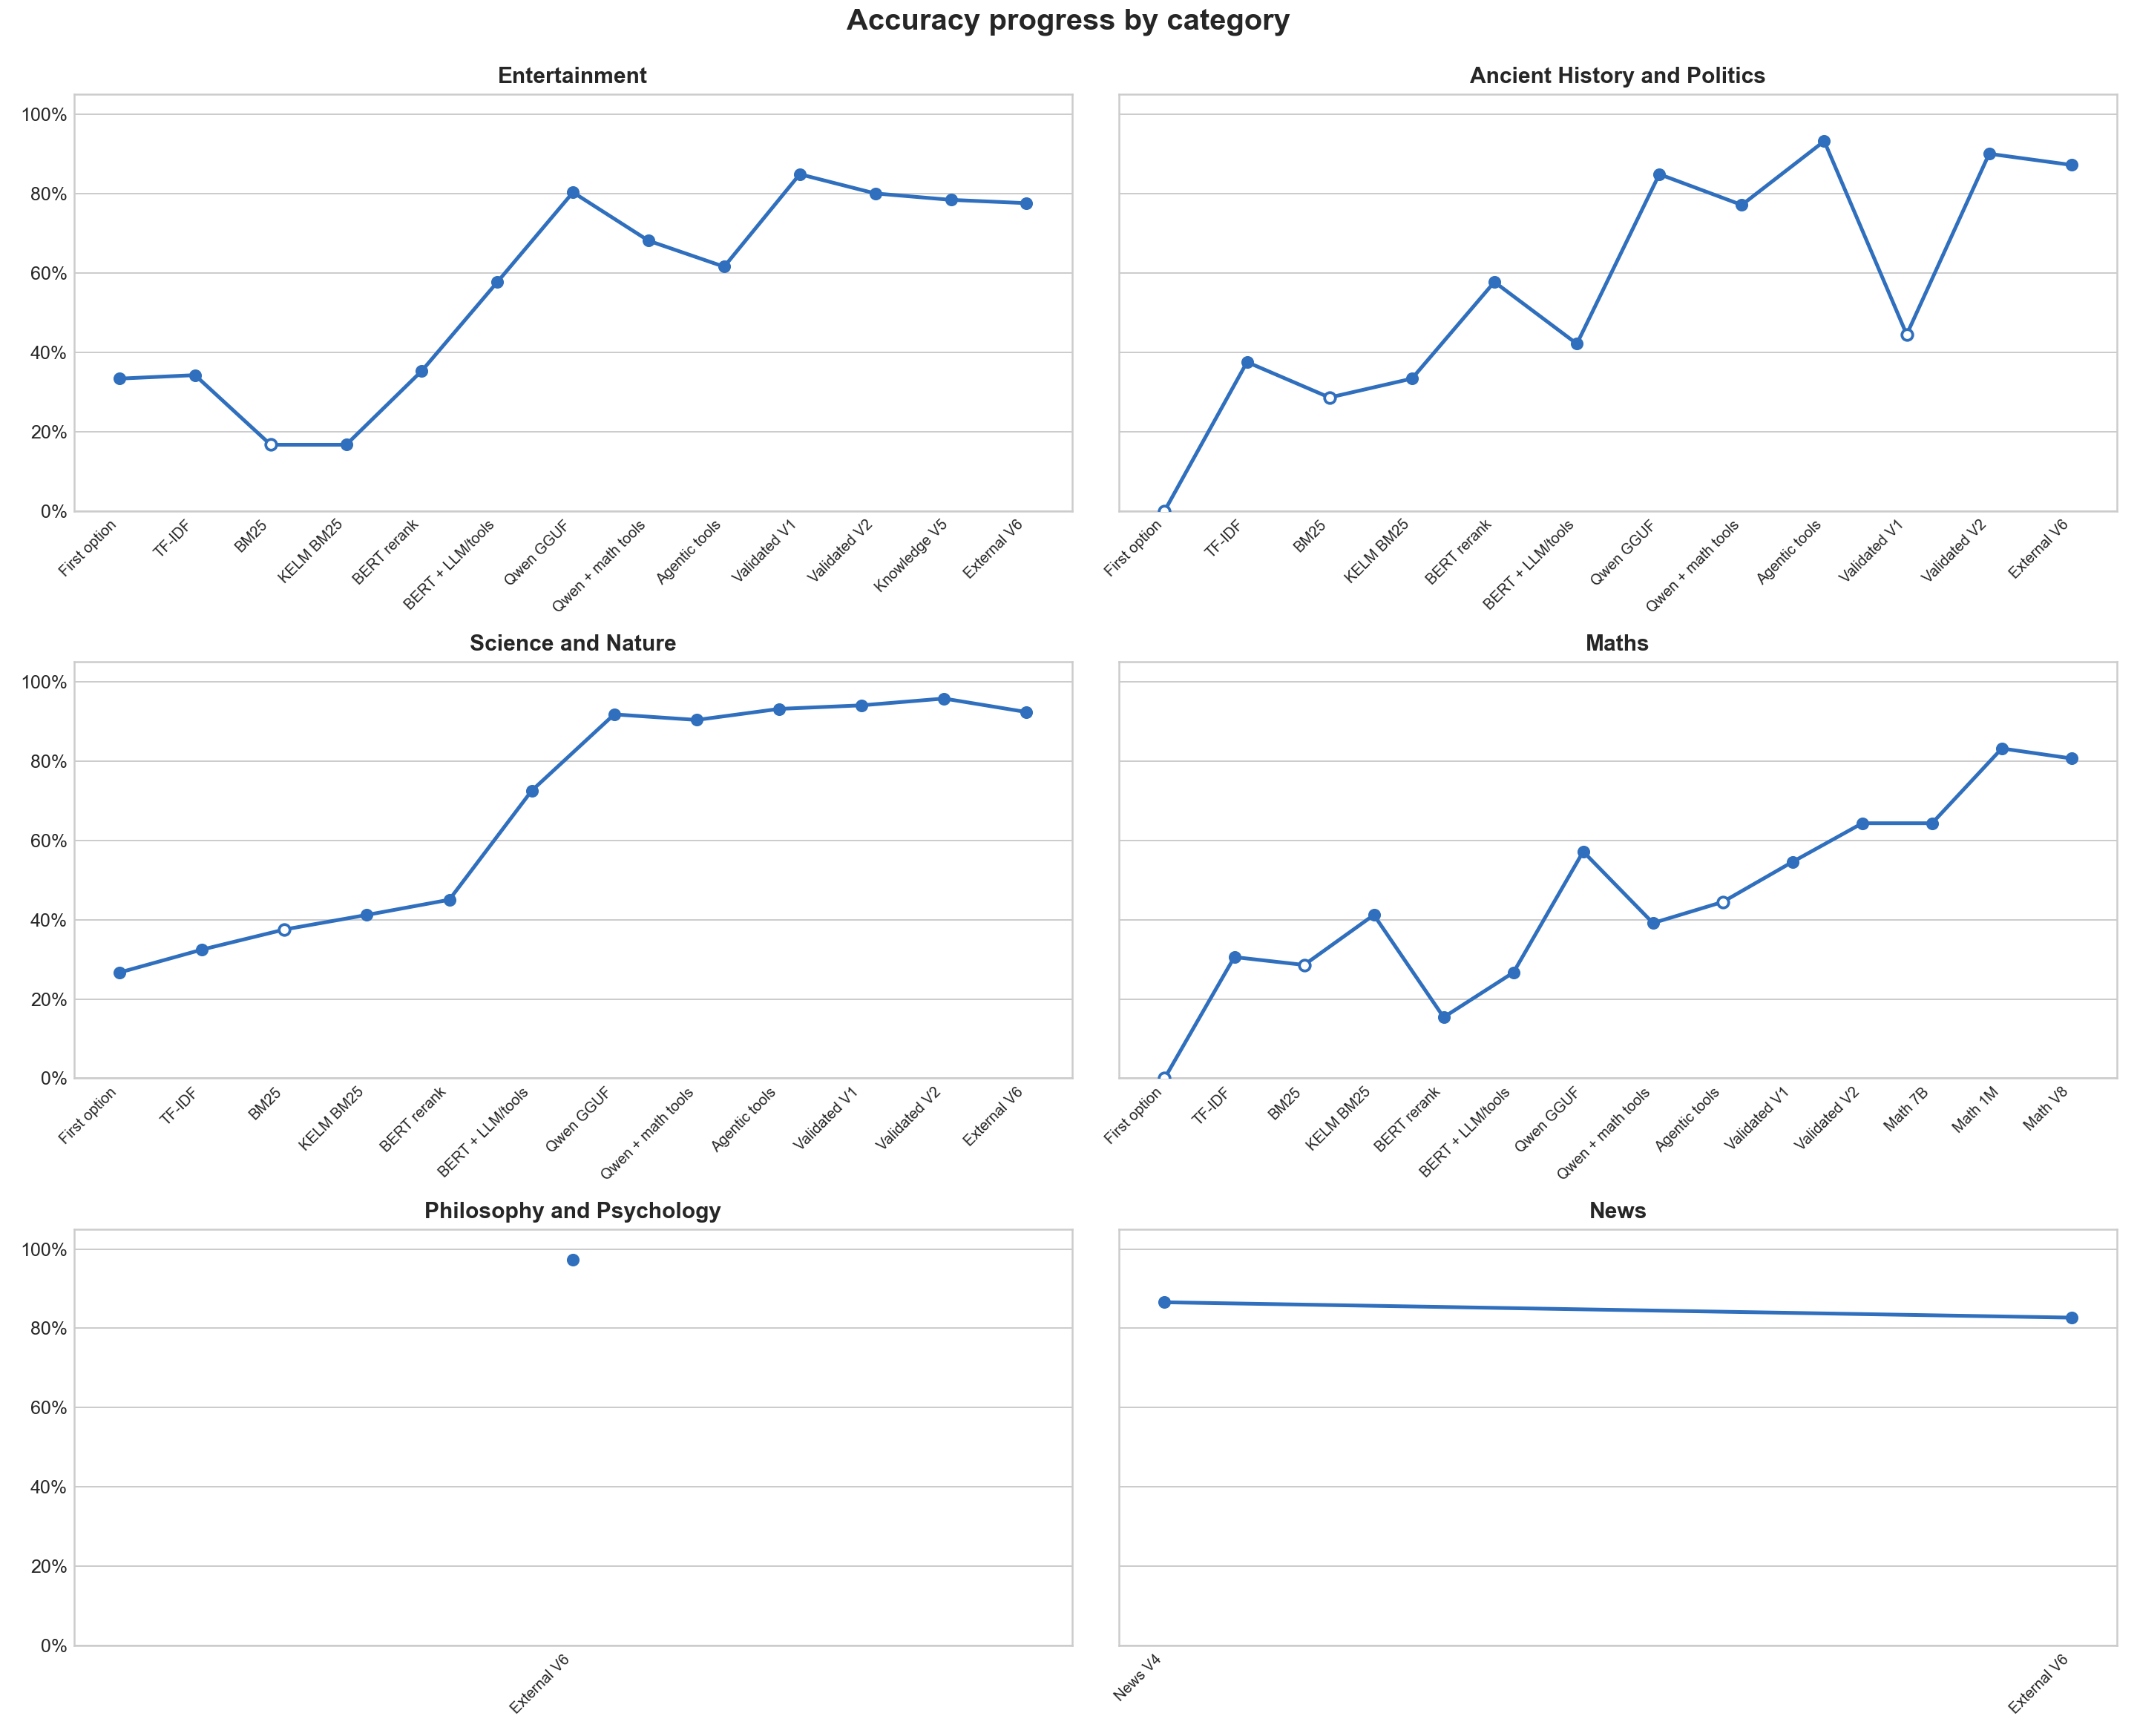

## 15. Speech mode

Speech mode keeps the V8 text pipeline unchanged. The adapter fetches speech-mode WAV audio, transcribes question/options with Whisper large-v3-turbo, builds a text-compatible question object, and then calls the existing `run_competition` / `answer_strategy` path.

### 15.1 Speech mode: preparation

In [ ]:
# V9 speech mode adapter: Whisper large-v3-turbo ASR -> unchanged V8 text pipeline.
import warnings

SPEECH_RUN_LOG_PATH = LOG_DIR / 'run_v9_speech.csv'
SPEECH_AUDIO_ROOT = WORK_ROOT / 'speech_audio_v9'
SPEECH_AUDIO_ROOT.mkdir(parents=True, exist_ok=True)

SPEECH_ASR_MODEL_ID = 'openai/whisper-large-v3-turbo'
SPEECH_ASR_DEVICE = 'cuda:1' if torch is not None and torch.cuda.is_available() and torch.cuda.device_count() > 1 else ('cuda:0' if torch is not None and torch.cuda.is_available() else 'cpu')
SPEECH_ASR_DTYPE = 'float16'
SPEECH_ASR_MAX_NEW_TOKENS = 192
SPEECH_WARMUP_ASR = True
SPEECH_API_THROTTLE_SEC = 0.5
SPEECH_START_GAME_RETRIES = 3
SPEECH_START_GAME_RETRY_SLEEP = 8.0
SPEECH_FETCH_RETRIES = 4
SPEECH_FETCH_RETRY_SLEEP = 2.5
SPEECH_ATTEMPT_DELAY_SEC = 3.0
SPEECH_ATTEMPTS_BY_CATEGORY = {
    'Entertainment': 10,
    'Ancient History and Politics': 10,
    'Science and Nature': 10,
    'Maths': 20,
    'Philosophy and Psychology': 10,
    'News': 10,
}

_speech_asr_runner = None


# Keep transformer logs quiet; real exceptions are still raised.
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('accelerate').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message=r'.*return_timestamps.*')
warnings.filterwarnings('ignore', message=r'.*attention mask.*')

print('Speech log:', SPEECH_RUN_LOG_PATH)
print('Speech audio root:', SPEECH_AUDIO_ROOT)
print('Speech ASR:', SPEECH_ASR_MODEL_ID, 'on', SPEECH_ASR_DEVICE)

Speech log: /kaggle/working/logs/run_v9_speech.csv
Speech audio root: /kaggle/working/speech_audio_v9
Speech ASR: openai/whisper-large-v3-turbo on cuda:1


In [ ]:
def _speech_throttle():
    delay = float(globals().get('SPEECH_API_THROTTLE_SEC', 0.0) or 0.0)
    if delay > 0:
        time.sleep(delay)


def _clean_speech_text(text):
    text = str(text or '').strip()
    text = re.sub(r'\s+', ' ', text)
    return text

_OPT_PREFIX_RE = re.compile(
    r'^(Option|Hobson|Topson|Thompson|Tobson|Yabson|Optian)\s*[A-D][\.,:]?\s*',
    re.IGNORECASE,
)

def _normalize_speech_option_text(raw_text: str) -> str:
    """Rimuove il prefisso 'Option X.' (incluse allucinazioni) e marca opzioni vuote."""
    if raw_text is None:
        return '(unintelligible)'
    body = _OPT_PREFIX_RE.sub('', str(raw_text)).strip()
    body = re.sub(r'\s+', ' ', body).strip(' ,.:;-')
    if len(body) < 3:
        return '(unintelligible)'
    return body


def _speech_torch_dtype(name, device):
    import torch
    if str(device).startswith('cuda') and str(name).lower() in {'float16', 'fp16'}:
        return torch.float16
    if str(device).startswith('cuda') and str(name).lower() in {'bfloat16', 'bf16'}:
        return torch.bfloat16
    return torch.float32


def _load_audio_16k(path):
    import math
    import numpy as np
    import soundfile as sf
    from scipy.signal import resample_poly

    audio, sr = sf.read(str(path), dtype='float32', always_2d=False)
    if getattr(audio, 'ndim', 1) > 1:
        audio = audio.mean(axis=1)
    audio = np.asarray(audio, dtype=np.float32)
    if int(sr) != 16000:
        gcd = math.gcd(int(sr), 16000)
        audio = resample_poly(audio, 16000 // gcd, int(sr) // gcd).astype(np.float32)
        sr = 16000
    return audio, int(sr)


class WhisperSpeechRunner:
    def __init__(self, model_id=SPEECH_ASR_MODEL_ID, device=SPEECH_ASR_DEVICE):
        import torch
        from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor

        self.model_id = model_id
        self.device = torch.device(device if torch.cuda.is_available() and str(device).startswith('cuda') else 'cpu')
        self.dtype = _speech_torch_dtype(SPEECH_ASR_DTYPE, self.device)
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForSpeechSeq2Seq.from_pretrained(
            model_id,
            torch_dtype=self.dtype,
            low_cpu_mem_usage=True,
            use_safetensors=True,
        ).to(self.device)
        self.model.eval()
        if hasattr(self.model, 'generation_config') and hasattr(self.model.generation_config, 'return_timestamps'):
            self.model.generation_config.return_timestamps = False

    def transcribe(self, path, bias_text: str | None = None):
        import torch
        audio, sr = _load_audio_16k(path)
        inputs = self.processor(audio, sampling_rate=sr, return_tensors='pt')
        input_features = inputs.input_features.to(device=self.device, dtype=self.dtype)
        generate_kwargs = {
            'max_new_tokens': int(SPEECH_ASR_MAX_NEW_TOKENS),
            'return_timestamps': False,
            'language': 'english',
            'task': 'transcribe',
        }

        if bias_text:
            try:
                prompt_ids = self.processor.get_prompt_ids(
                    bias_text[:200],          # Whisper ha limite ~224 token; tagliamo per sicurezza
                    return_tensors='pt'
                ).to(self.device)
                generate_kwargs['prompt_ids'] = prompt_ids
            except Exception:
                pass  # se fallisce, semplicemente ASR senza bias

        attention_mask = getattr(inputs, 'attention_mask', None)
        if attention_mask is not None:
            generate_kwargs['attention_mask'] = attention_mask.to(self.device)

        with torch.inference_mode():
            try:
                predicted_ids = self.model.generate(input_features, **generate_kwargs)
            except (TypeError, ValueError):
                generate_kwargs.pop('language', None)
                generate_kwargs.pop('task', None)
                generate_kwargs.pop('prompt_ids', None)
                predicted_ids = self.model.generate(input_features, **generate_kwargs)

        return _clean_speech_text(self.processor.batch_decode(predicted_ids, skip_special_tokens=True)[0])

    def warmup(self):
        if not SPEECH_WARMUP_ASR:
            return
        try:
            import numpy as np
            import soundfile as sf
            warmup_path = SPEECH_AUDIO_ROOT / '_whisper_warmup.wav'
            if not warmup_path.exists():
                sf.write(str(warmup_path), np.zeros(16000, dtype=np.float32), 16000)
            _ = self.transcribe(warmup_path)
        except Exception as exc:
            print(f'Whisper warmup skipped: {type(exc).__name__}: {exc}', flush=True)

    def close(self):
        try:
            self.model.cpu()
        except Exception:
            pass
        try:
            del self.model
            del self.processor
        except Exception:
            pass


def get_speech_asr_runner():
    global _speech_asr_runner
    if _speech_asr_runner is None:
        print(f'Loading speech ASR before starting speech games: {SPEECH_ASR_MODEL_ID} on {SPEECH_ASR_DEVICE}', flush=True)
        started = time.time()
        _speech_asr_runner = WhisperSpeechRunner(SPEECH_ASR_MODEL_ID, SPEECH_ASR_DEVICE)
        _speech_asr_runner.warmup()
        print(f'Speech ASR ready in {time.time() - started:.1f}s', flush=True)
    return _speech_asr_runner


def close_speech_asr_runner():
    global _speech_asr_runner
    if _speech_asr_runner is not None:
        try:
            _speech_asr_runner.close()
        finally:
            _speech_asr_runner = None
    cleanup_memory()

class SpeechOption:
    def __init__(self, option_id, text):
        self.id = int(option_id)
        self.text = _normalize_speech_option_text(text)

class SpeechQuestion:
    def __init__(self, original_question, question_text, options):
        self.original_question = original_question
        self.id = getattr(original_question, 'id', None)
        self.level = getattr(original_question, 'level', None)
        self.text = _clean_speech_text(question_text)
        self.question_text = self.text
        self.options = [SpeechOption(option_id, text) for option_id, text in options]


def _speech_option_ids(question):
    opts = list(getattr(question, 'options', []) or [])[:4]
    ids = []
    for idx, opt in enumerate(opts):
        try:
            ids.append(int(getattr(opt, 'id')))
        except Exception:
            ids.append(idx)
    while len(ids) < 4:
        ids.append(len(ids))
    return ids[:4]


def _speech_fetch_audio(fetch_fn, label):
    last_exc = None
    for attempt in range(1, int(SPEECH_FETCH_RETRIES) + 1):
        try:
            started = time.time()
            data = fetch_fn()
            _speech_throttle()
            return data, time.time() - started
        except KeyboardInterrupt:
            raise
        except Exception as exc:
            last_exc = exc
            print(f'    fetch {label} failed {attempt}/{SPEECH_FETCH_RETRIES}: {type(exc).__name__}: {exc}', flush=True)
            time.sleep(SPEECH_FETCH_RETRY_SLEEP)
    raise RuntimeError(f'fetch {label} failed after {SPEECH_FETCH_RETRIES} attempts: {last_exc!r}')


def _speech_save_audio(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(data)
    return str(path)


def _start_real_speech_game(client, comp_id):
    last_exc = None
    for attempt in range(1, int(SPEECH_START_GAME_RETRIES) + 1):
        try:
            game = client.game.start(competition_id=comp_id, mode='speech')
            _speech_throttle()
            return game
        except KeyboardInterrupt:
            raise
        except Exception as exc:
            last_exc = exc
            print(f'  speech start failed {attempt}/{SPEECH_START_GAME_RETRIES}: {type(exc).__name__}: {exc}', flush=True)
            if attempt < int(SPEECH_START_GAME_RETRIES):
                time.sleep(SPEECH_START_GAME_RETRY_SLEEP)
    raise RuntimeError(f'speech start failed after {SPEECH_START_GAME_RETRIES} attempts: {last_exc!r}')


class SpeechGameAdapter:
    def __init__(self, real_game, runner, comp_id, run_id, attempt_number):
        self._game = real_game
        self._runner = runner
        self._comp_id = comp_id
        self._run_id = run_id or 'speech'
        self._attempt_number = attempt_number or 0
        self._question_index = 0
        self._cached_key = None
        self._cached_question = None
        self.transcription_logs = []

    def __getattr__(self, name):
        return getattr(self._game, name)

    @property
    def current_question(self):
        original = self._game.current_question
        if original is None:
            return None
        key = (getattr(self._game, 'session_id', None), getattr(original, 'id', None), getattr(original, 'level', None))
        if key != self._cached_key:
            self._question_index += 1
            self._cached_key = key
            self._cached_question = self._transcribe_question(original)
        return self._cached_question

    def _transcribe_question(self, original_question):
        session_id = getattr(self._game, 'session_id', None)
        qid = getattr(original_question, 'id', None)
        base = SPEECH_AUDIO_ROOT / str(self._run_id) / f'comp_{self._comp_id}' / f'attempt_{self._attempt_number:03d}' / f'session_{session_id}_q{self._question_index:02d}_qid_{qid}'
        labels = ['question', 'option_A', 'option_B', 'option_C', 'option_D']
        fetchers = [self._game.fetch_audio_question] + [self._game.fetch_audio_option_next] * 4
        audio_paths, fetch_seconds, asr_seconds, transcripts = {}, {}, {}, {}

        for label, fetch_fn in zip(labels, fetchers):
            data, fetch_elapsed = _speech_fetch_audio(fetch_fn, label)
            audio_path = _speech_save_audio(base / f'{label}.wav', data)
            asr_started = time.time()
            # Per le opzioni, usa la domanda come bias
            if label == 'question':
                transcripts[label] = self._runner.transcribe(audio_path)
            else:
                question_text = transcripts.get('question', '')
                transcripts[label] = self._runner.transcribe(audio_path, bias_text=question_text)

            audio_paths[label] = audio_path
            fetch_seconds[label] = fetch_elapsed
            asr_seconds[label] = time.time() - asr_started

        try:
            self._game.refresh_state()
            _speech_throttle()
        except Exception:
            pass

        option_ids = _speech_option_ids(original_question)
        options = [(option_ids[i], transcripts[f'option_{chr(65 + i)}']) for i in range(4)]
        speech_question = SpeechQuestion(original_question, transcripts['question'], options)
        self.transcription_logs.append({
            'question_id': getattr(original_question, 'id', None),
            'speech_mode': True,
            'asr_model_id': SPEECH_ASR_MODEL_ID,
            'asr_device': SPEECH_ASR_DEVICE,
            'api_question_text': getattr(original_question, 'text', None),
            'api_options_json': json.dumps([(oid, getattr(opt, 'text', None)) for oid, opt in zip(option_ids, list(getattr(original_question, 'options', []) or [])[:4])], ensure_ascii=False),
            'question_audio_path': audio_paths.get('question'),
            'option_A_audio_path': audio_paths.get('option_A'),
            'option_B_audio_path': audio_paths.get('option_B'),
            'option_C_audio_path': audio_paths.get('option_C'),
            'option_D_audio_path': audio_paths.get('option_D'),
            'question_fetch_seconds': fetch_seconds.get('question'),
            'option_A_fetch_seconds': fetch_seconds.get('option_A'),
            'option_B_fetch_seconds': fetch_seconds.get('option_B'),
            'option_C_fetch_seconds': fetch_seconds.get('option_C'),
            'option_D_fetch_seconds': fetch_seconds.get('option_D'),
            'question_asr_seconds': asr_seconds.get('question'),
            'option_A_asr_seconds': asr_seconds.get('option_A'),
            'option_B_asr_seconds': asr_seconds.get('option_B'),
            'option_C_asr_seconds': asr_seconds.get('option_C'),
            'option_D_asr_seconds': asr_seconds.get('option_D'),
            'total_asr_seconds': sum(asr_seconds.values()),
            'speech_question_transcript': transcripts.get('question'),
            'speech_options_transcript_json': json.dumps(options, ensure_ascii=False),
        })
        return speech_question

    def answer(self, option_id):
        result = self._game.answer(option_id)
        _speech_throttle()
        return result


class SpeechGameServiceAdapter:
    def __init__(self, real_client, run_id=None, attempt_number=None):
        self.real_client = real_client
        self.run_id = run_id
        self.attempt_number = attempt_number
        self.last_game = None

    def start(self, competition_id):
        runner = get_speech_asr_runner()  # warm ASR before the server starts the speech game timer flow
        real_game = _start_real_speech_game(self.real_client, competition_id)
        self.last_game = SpeechGameAdapter(real_game, runner, competition_id, self.run_id, self.attempt_number)
        return self.last_game


class SpeechClientAdapter:
    def __init__(self, real_client, run_id=None, attempt_number=None):
        self.real_client = real_client
        self.game = SpeechGameServiceAdapter(real_client, run_id=run_id, attempt_number=attempt_number)
        self.competitions = real_client.competitions

    def __getattr__(self, name):
        return getattr(self.real_client, name)


def _attach_speech_metadata(df, speech_game):
    if df is None or df.empty or speech_game is None:
        return df
    meta = pd.DataFrame(speech_game.transcription_logs)
    if meta.empty:
        df = df.copy()
        df['speech_mode'] = True
        df['asr_model_id'] = SPEECH_ASR_MODEL_ID
        df['asr_device'] = SPEECH_ASR_DEVICE
        return df
    merged = df.merge(meta, on='question_id', how='left', suffixes=('', '_speech'))
    merged['speech_mode'] = True
    merged['asr_model_id'] = merged['asr_model_id'].fillna(SPEECH_ASR_MODEL_ID)
    merged['asr_device'] = merged['asr_device'].fillna(SPEECH_ASR_DEVICE)
    return merged


def run_speech_competition(client, comp_id, competition_names, attempt_number=None, run_id=None):
    speech_client = SpeechClientAdapter(client, run_id=run_id, attempt_number=attempt_number)
    df = run_competition(speech_client, comp_id, competition_names, attempt_number=attempt_number, run_id=run_id)
    return _attach_speech_metadata(df, speech_client.game.last_game)


def run_speech_selected_competitions(client, competitions, attempts, output_csv=SPEECH_RUN_LOG_PATH):
    competition_names = get_competition_names(client)
    all_logs = []
    run_id = time.strftime('%Y%m%d_%H%M%S_speech_v9')
    selected = set(competitions)

    for attempt in range(1, int(attempts) + 1):
        for comp_id, comp_name in competition_names.items():
            if comp_name not in selected and comp_id not in selected and str(comp_id) not in selected:
                continue
            print(f'\n{"="*50}', flush=True)
            print(f'Attempt {attempt}/{attempts} | {comp_name}', flush=True)
            print(f'{"="*50}', flush=True)

            try:
                df = run_speech_competition(client, comp_id, competition_names, attempt_number=attempt, run_id=run_id)
            except Exception as exc:
                print(f'  Attempt failed: {type(exc).__name__}: {exc}', flush=True)
                df = pd.DataFrame([{
                    'run_id': run_id,
                    'attempt_number': attempt,
                    'session_started_at': time.strftime('%Y-%m-%d %H:%M:%S'),
                    'competition_id': comp_id,
                    'competition_name': comp_name,
                    'error_message': repr(exc),
                    'speech_mode': True,
                    'asr_model_id': SPEECH_ASR_MODEL_ID,
                    'asr_device': SPEECH_ASR_DEVICE,
                }])
            append_logs(df, output_csv=output_csv)
            all_logs.append(df)
            time.sleep(SPEECH_ATTEMPT_DELAY_SEC)
            cleanup_memory()

    return pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()

In [ ]:
# Initialize the game client.
client = setup_client()


### 15.2 Speech mode: execution

In [ ]:
# Speech-mode run: Entertainment
speech_entertainment_df = run_speech_selected_competitions(
    client,
    {'Entertainment'},
    attempts=SPEECH_ATTEMPTS_BY_CATEGORY['Entertainment'],
)
speech_entertainment_df.tail()

0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Speech attempt 1/10 | Entertainment
Loading speech ASR before starting speech games: openai/whisper-large-v3-turbo on cuda:1
Speech ASR ready in 9.4s


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/23 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/23 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/16 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/16 [00:00<?, ?it/s]

  ✓ [16.8s] What technique did Hitchcock often use to make the audience feel like  | $1,024,000
  appended 15 speech rows to /kaggle/working/logs/run_v9_speech.csv


,run_id,attempt_number,session_started_at,session_id,competition_id,competition_name,question_id,question_level,game_current_level_before,time_remaining_before,...,option_C_fetch_seconds,option_D_fetch_seconds,question_asr_seconds,option_A_asr_seconds,option_B_asr_seconds,option_C_asr_seconds,option_D_asr_seconds,total_asr_seconds,speech_question_transcript,speech_options_transcript_json
63,20260531_175724_speech_v9,10,2026-05-31 18:21:10,313847,0,Entertainment,412,0,11,28.282462,...,0.771784,0.881368,0.350862,0.290595,0.281008,0.274177,0.271695,1.468337,Which of the following best describes the rela...,"[[0, ""Option A, she was a major influence on h..."
64,20260531_175724_speech_v9,10,2026-05-31 18:21:10,313847,0,Entertainment,343,0,12,28.405378,...,0.876108,0.773560,0.377236,0.305584,0.277146,0.301673,0.264343,1.525982,How did the introduction of electronic instrum...,"[[0, ""Option A, it created new possibilities f..."
65,20260531_175724_speech_v9,10,2026-05-31 18:21:10,313847,0,Entertainment,421,0,13,28.264025,...,0.882024,0.885381,0.346442,0.289564,0.283220,0.291075,0.286340,1.496641,What technique did Streep use to develop the c...,"[[0, ""Option A, she studied people close to Ka..."
66,20260531_175724_speech_v9,10,2026-05-31 18:21:10,313847,0,Entertainment,125,0,14,28.376843,...,0.774487,0.773750,0.356716,0.293303,0.301798,0.301879,0.283801,1.537498,How did Mariah Carey's vocal range contribute ...,"[[0, ""Option A, by limiting her performances t..."
67,20260531_175724_speech_v9,10,2026-05-31 18:21:10,313847,0,Entertainment,189,0,15,28.279014,...,0.882677,0.876486,0.364465,0.295915,0.262913,0.284550,0.281333,1.489176,What technique did Hitchcock often use to make...,"[[0, ""Option A, he focused on close-ups in the..."


In [ ]:
# Speech-mode run: Ancient History and Politics
speech_ancient_history_politics_df = run_speech_selected_competitions(
    client,
    {'Ancient History and Politics'},
    attempts=SPEECH_ATTEMPTS_BY_CATEGORY['Ancient History and Politics'],
)
speech_ancient_history_politics_df.tail()

0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | Ancient History and Politics


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/24 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/24 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/21 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/21 [00:00<?, ?it/s]

  ✗ [17.2s] During which period did slaves first begin to be defined as individual | $2,000


,run_id,attempt_number,session_started_at,session_id,competition_id,competition_name,question_id,question_level,game_current_level_before,time_remaining_before,...,option_C_fetch_seconds,option_D_fetch_seconds,question_asr_seconds,option_A_asr_seconds,option_B_asr_seconds,option_C_asr_seconds,option_D_asr_seconds,total_asr_seconds,speech_question_transcript,speech_options_transcript_json
43,20260601_135527_speech_v9,10,2026-06-01 14:13:28,336611,1,Ancient History and Politics,858,0,3,28.288777,...,0.776455,0.882088,0.289026,0.263175,0.258555,0.243681,0.265324,1.319763,What is the fundamental principle of an archit...,"[[0, ""Option A. It is a uniform assemblage of ..."
44,20260601_135527_speech_v9,10,2026-06-01 14:13:28,336611,1,Ancient History and Politics,1075,0,4,28.285100,...,0.772289,0.890642,0.325107,0.251554,0.258741,0.255934,0.261182,1.352519,What was the strategic significance of the Nil...,"[[0, ""Option A. It was the location of the Byz..."
45,20260601_135527_speech_v9,10,2026-06-01 14:13:28,336611,1,Ancient History and Politics,1262,0,5,28.466128,...,0.764670,0.765976,0.341850,0.233300,0.212945,0.209547,0.204659,1.202300,What term describes the raised right arm gestu...,"[[0, ""Option A. Bellamy salute! Now a...""], [1..."
46,20260601_135527_speech_v9,10,2026-06-01 14:13:28,336611,1,Ancient History and Politics,1086,0,6,28.438076,...,0.882866,0.773450,0.388473,0.234054,0.231313,0.231192,0.226086,1.311119,Which of the following best describes the popu...,"[[0, ""Option A, 0.1% per year.""], [1, ""Option ..."
47,20260601_135527_speech_v9,10,2026-06-01 14:13:28,336611,1,Ancient History and Politics,1125,0,7,28.587191,...,1.005456,0.647627,0.348012,0.210884,0.210624,0.195723,0.202327,1.167571,During which period did slaves first begin to ...,"[[0, ""Option A, first intermediate period.""], ..."


In [ ]:
# Speech-mode run: Science and Nature
speech_science_nature_df = run_speech_selected_competitions(
    client,
    {'Science and Nature'},
    attempts=SPEECH_ATTEMPTS_BY_CATEGORY['Science and Nature'],
)
speech_science_nature_df.tail()

0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Attempt 1/10 | Science and Nature


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/33 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/33 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/74 [00:00<?, ?it/s]

  ✗ [1.6s] Homes that are built to be environmentally friendly because they use e | $0


/tmp/ipykernel_58/1550154072.py:398: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()


,run_id,attempt_number,session_started_at,session_id,competition_id,competition_name,question_id,question_level,game_current_level_before,time_remaining_before,...,option_C_fetch_seconds,option_D_fetch_seconds,question_asr_seconds,option_A_asr_seconds,option_B_asr_seconds,option_C_asr_seconds,option_D_asr_seconds,total_asr_seconds,speech_question_transcript,speech_options_transcript_json
75,20260601_145218_speech_v9,9,2026-06-01 15:05:23,337828,2,Science and Nature,1643,0,8,28.333356,...,0.769345,0.884480,0.401502,0.213120,0.216340,0.217715,0.217851,1.266529,What term describes a detailed examination of ...,"[[0, ""Option A, case study.""], [1, ""Option B, ..."
76,20260601_145218_speech_v9,9,2026-06-01 15:05:23,337828,2,Science and Nature,5957,0,9,28.408842,...,0.771880,0.771061,0.395432,0.250553,0.257352,0.245748,0.252011,1.401096,An infectious disease causes an increase in th...,"[[0, ""Option A, an increase in the energy leve..."
77,20260601_145218_speech_v9,9,2026-06-01 15:05:23,337828,2,Science and Nature,4302,0,10,28.427566,...,0.772573,0.780386,0.283905,0.221123,0.224118,0.228265,0.223660,1.181072,What happens when an atom gains an electron?,"[[0, ""Option A, the atom becomes negatively ch..."
78,20260601_145218_speech_v9,9,2026-06-01 15:05:23,337828,2,Science and Nature,3416,0,11,28.247166,...,0.772123,0.881559,0.311723,0.262604,0.235533,0.220180,0.228141,1.258181,Which statement Betts describes the effect of ...,"[[0, ""Option A, the sun's rays cause organisms..."
79,20260601_145218_speech_v9,10,2026-06-01 15:07:29,337875,2,Science and Nature,4477,0,1,28.459976,...,0.999643,0.764236,0.755932,0.212930,0.204783,0.193157,0.210892,1.577694,Homes that are built to be environmentally fri...,"[[0, ""Option A, chemical energy.""], [1, ""Optio..."


In [ ]:
# Speech-mode run: Maths
speech_maths_df = run_speech_selected_competitions(
    client,
    {'Maths'},
    attempts=SPEECH_ATTEMPTS_BY_CATEGORY['Maths'],
)
speech_maths_df.tail()

0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Speech attempt 1/20 | Maths


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/79 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/79 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/15 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/15 [00:00<?, ?it/s]

  ✓ [16.9s] The maximum number of acute angles in a convex tangon in the Euclidean | $200


KeyboardInterrupt: 

In [ ]:
# Speech-mode run: Philosophy and Psychology
speech_philosophy_psychology_df = run_speech_selected_competitions(
    client,
    {'Philosophy and Psychology'},
    attempts=SPEECH_ATTEMPTS_BY_CATEGORY['Philosophy and Psychology'],
)
speech_philosophy_psychology_df.tail()

0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Speech attempt 1/10 | Philosophy and Psychology


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/21 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/21 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/16 [00:00<?, ?it/s]

  ✗ [1.2s] What term describes the state of being aware of one's surroundings and | $200
  appended 3 speech rows to /kaggle/working/logs/run_v9_speech.csv


/tmp/ipykernel_745/3092279341.py:409: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()


,run_id,attempt_number,session_started_at,session_id,competition_id,competition_name,question_id,question_level,game_current_level_before,time_remaining_before,...,option_C_fetch_seconds,option_D_fetch_seconds,question_asr_seconds,option_A_asr_seconds,option_B_asr_seconds,option_C_asr_seconds,option_D_asr_seconds,total_asr_seconds,speech_question_transcript,speech_options_transcript_json
77,20260531_191013_speech_v9,9,2026-05-31 19:25:13,315217,4,Philosophy and Psychology,9523,0,2,28.255035,...,0.777653,0.883677,0.318517,0.268338,0.297920,0.278728,0.295790,1.459293,Which of the following best describes the prim...,"[[0, ""Option A, the development of intelligenc..."
78,20260531_191013_speech_v9,9,2026-05-31 19:25:13,315217,4,Philosophy and Psychology,9106,0,3,27.905278,...,1.005519,1.248977,0.297005,0.280131,0.272172,0.274269,0.283289,1.406867,Which of the following best describes his soci...,"[[0, ""Option A, a tendency to show antisocial ..."
79,20260531_191013_speech_v9,10,2026-05-31 19:25:51,315234,4,Philosophy and Psychology,9956,0,1,28.218834,...,0.778263,0.887350,0.335742,0.289068,0.298008,0.275370,0.330111,1.528299,Which of the following best describes the shop...,"[[0, ""Option A, a theory about the design and ..."
80,20260531_191013_speech_v9,10,2026-05-31 19:25:51,315234,4,Philosophy and Psychology,7212,0,2,28.241684,...,0.772318,0.894053,0.320910,0.269477,0.270302,0.279334,0.300740,1.440763,Which of the following best describes Thomas A...,"[[0, ""Option A, an advocate for Stoic ethics.""..."
81,20260531_191013_speech_v9,10,2026-05-31 19:25:51,315234,4,Philosophy and Psychology,7808,0,3,28.307343,...,0.877837,0.882443,0.344484,0.248017,0.235213,0.245108,0.246469,1.319291,What term describes the state of being aware o...,"[[0, ""Option A, introspection.""], [1, ""Option ..."


In [ ]:
# Speech-mode run: News
speech_news_df = run_speech_selected_competitions(
    client,
    {'News'},
    attempts=SPEECH_ATTEMPTS_BY_CATEGORY['News'],
)
speech_news_df.tail()

0 Entertainment 15
1 Ancient History and Politics 15
2 Science and Nature 15
3 Maths 15
4 Philosophy and Psychology 15
5 News 15

Speech attempt 1/10 | News


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/18 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/18 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/22 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/22 [00:00<?, ?it/s]

  ✗ [9.4s] According to the article published on 2026, so 515, who authored the b | $300 | art:3 opts_found:[] chosen_in_art:False
    Chosen: 0 | [[0, "Option A, Kate Lister."], [1, "Option B, Dr. Gene Menzies."], [2, "Option C, Emily Nagoski."], [3, "Option D. Catherine Ange
  appended 4 speech rows to /kaggle/working/logs/run_v9_speech.csv


,run_id,attempt_number,session_started_at,session_id,competition_id,competition_name,question_id,question_level,game_current_level_before,time_remaining_before,...,option_C_fetch_seconds,option_D_fetch_seconds,question_asr_seconds,option_A_asr_seconds,option_B_asr_seconds,option_C_asr_seconds,option_D_asr_seconds,total_asr_seconds,speech_question_transcript,speech_options_transcript_json
21,20260531_194545_speech_v9,9,2026-05-31 19:54:25,315762,5,News,10796,0,2,28.057705,...,0.877655,1.012181,0.459137,0.224977,0.238709,0.241803,0.368137,1.532763,"According to the report from 2026-0515, which ...","[[0, ""Option A Caddy""], [1, ""Option B. Bamako...."
22,20260531_194545_speech_v9,10,2026-05-31 19:55:15,315781,5,News,11751,0,1,28.308057,...,0.765664,0.879118,0.435971,0.238635,0.235878,0.248935,0.250777,1.410197,According to the article published on 2026-05-...,"[[0, ""Option A, Patrick Sneeder.""], [1, ""Optio..."
23,20260531_194545_speech_v9,10,2026-05-31 19:55:15,315781,5,News,11461,0,2,28.442258,...,0.882177,0.760961,0.469677,0.242606,0.239815,0.262969,0.235093,1.450160,"As reported on 2026-105-18, which cabinet memb...","[[0, ""Option A, Lisa Nandy.""], [1, ""Option B. ..."
24,20260531_194545_speech_v9,10,2026-05-31 19:55:15,315781,5,News,10687,0,3,28.430663,...,0.877864,0.765224,0.397366,0.231297,0.260033,0.239134,0.242805,1.370636,According to the news article published on 202...,"[[0, ""Option A, MV Odyssey.""], [1, ""Option B. ..."
25,20260531_194545_speech_v9,10,2026-05-31 19:55:15,315781,5,News,11013,0,4,28.323048,...,0.760059,0.883454,0.447803,0.239636,0.258645,0.246197,0.232203,1.424484,"According to the article published on 2026, so...","[[0, ""Option A, Kate Lister.""], [1, ""Option B,..."


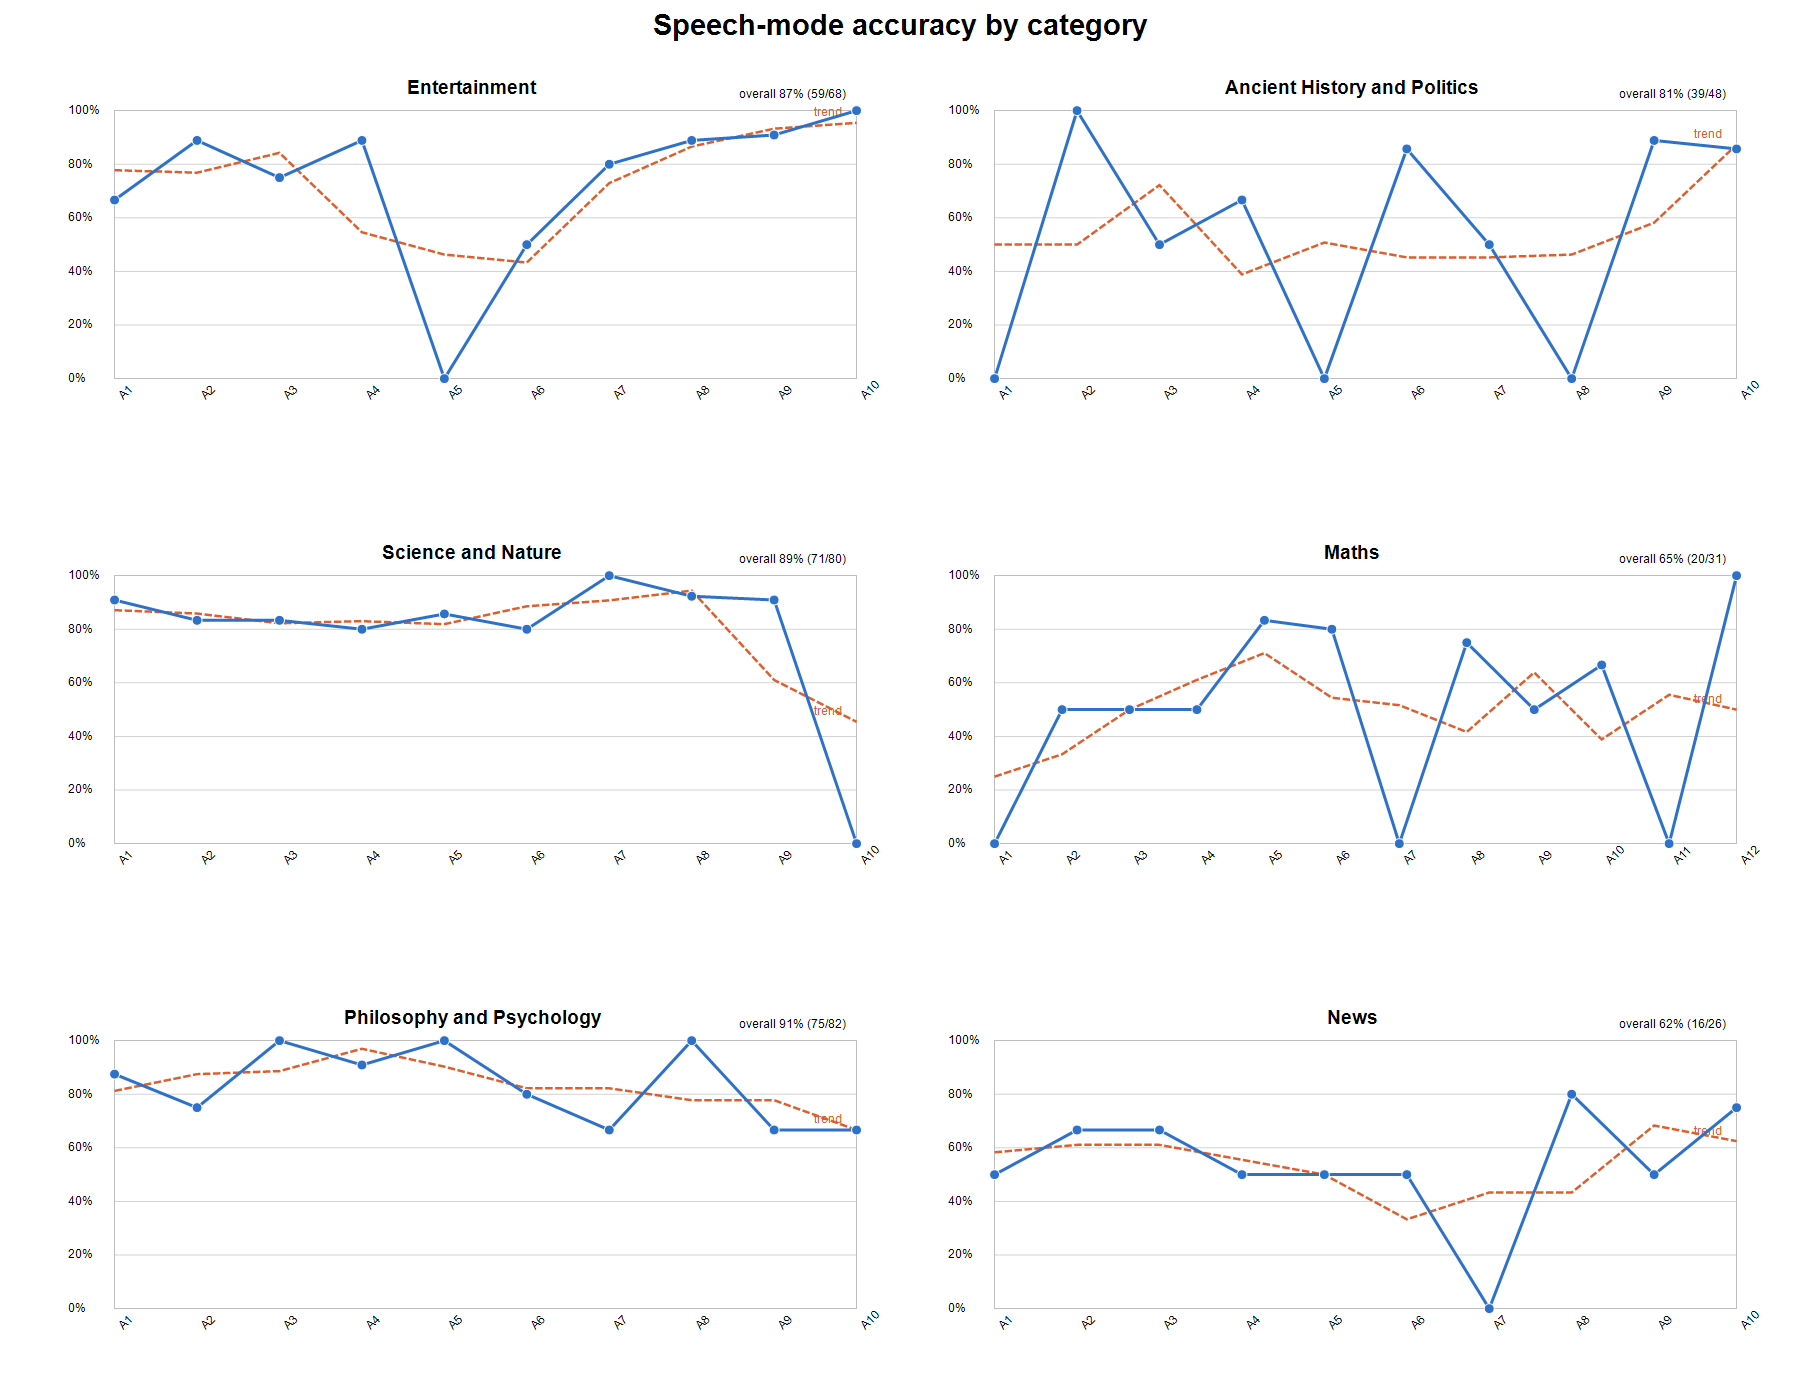